<a href="https://colab.research.google.com/github/GreppiFilippo/Progetto-Data-Intensive/blob/main/Progetto_data_intensive_diabete_COMPLETO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto Data Intensive

## Contesto e obiettivo

Il dataset utilizzato raccoglie dieci anni di dati clinici, relativi al periodo **1999-2008**, provenienti da **130 ospedali statunitensi** e reti sanitarie integrate. Ogni record rappresenta un singolo **ricovero ospedaliero** di un paziente con diagnosi di diabete, con durata della degenza compresa tra **1 e 14 giorni**. Durante il ricovero il paziente può essere stato sottoposto a esami di laboratorio, procedure cliniche, terapie farmacologiche e monitoraggio medico.

Il problema affrontato è la **predizione della riammissione ospedaliera** dopo la dimissione. Il modello deve stabilire se un paziente non verrà riammesso, verrà riammesso entro 30 giorni, oppure verrà riammesso dopo più di 30 giorni, utilizzando le informazioni demografiche, cliniche, amministrative e terapeutiche disponibili durante il ricovero.

La motivazione è sia clinica sia organizzativa. Una gestione non ottimale del diabete in fase di degenza e di dimissione può tradursi in nuovi ricoveri a breve distanza, con un duplice costo: maggiore spesa per le strutture sanitarie e peggioramento delle condizioni del paziente, con aumento del rischio di complicanze. Un modello capace di stimare in anticipo il rischio di riammissione può quindi supportare le decisioni cliniche, aiutando a individuare i pazienti più fragili prima della dimissione e a orientare interventi mirati come controlli più accurati, modifiche terapeutiche, educazione del paziente o follow-up più ravvicinati.

---

## Fonte e struttura del dataset

Il dataset è disponibile presso l'**UCI Machine Learning Repository**:

[Diabetes 130-US hospitals for years 1999-2008](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)

Ogni riga corrisponde a un episodio di ricovero e descrive le caratteristiche del paziente, il percorso clinico durante la degenza e le terapie ricevute. Le informazioni disponibili includono:

- caratteristiche demografiche del paziente (età, genere, etnia);
- informazioni amministrative e cliniche sul ricovero (tipo di ammissione, provenienza del paziente, durata della degenza, modalità di dimissione);
- diagnosi principali e secondarie, codificate tramite codici ICD-9;
- numero di visite, procedure, farmaci ed esami di laboratorio effettuati;
- risultati di alcuni test clinici, come emoglobina glicata (HbA1c) e glicemia;
- terapie farmacologiche somministrate, con particolare attenzione ai farmaci per il diabete;
- la variabile target relativa alla riammissione del paziente.

Non tutte queste variabili verranno mantenute nel modello finale: l'analisi esplorativa valuterà l'utilità di ciascuna feature e motiverà le eventuali esclusioni.

---

## Variabile target e formulazione del problema

La variabile target è **`readmitted`**, che descrive se e quando un paziente è stato riammesso in ospedale dopo la dimissione. Il problema viene impostato come un task di **classificazione supervisionata multiclasse**: il modello non si limita a distinguere pazienti riammessi e non riammessi, ma assegna ogni ricovero a una delle tre classi disponibili:

- **`NO`** — il paziente non è stato riammesso;
- **`>30`** — il paziente è stato riammesso dopo più di 30 giorni dalla dimissione;
- **`<30`** — il paziente è stato riammesso entro 30 giorni dalla dimissione.

Rispetto a una formulazione binaria, l'impostazione multiclasse offre un'informazione più articolata, perché distingue tra riammissioni precoci, riammissioni tardive e assenza di riammissione. In particolare, la classe **`<30`** è quella di maggiore interesse clinico: una riammissione entro 30 giorni può segnalare una fragilità più marcata del paziente, una gestione non ottimale della dimissione o la necessità di interventi più tempestivi. È anche, come vedremo, la classe più difficile da predire, sia perché clinicamente più sfumata sia per la sua scarsa numerosità.

Le tre classi sono infatti **fortemente sbilanciate**: la maggioranza dei ricoveri non dà luogo a riammissione, mentre la classe `<30` rappresenta solo circa un decimo delle osservazioni. Questo sbilanciamento è un aspetto centrale del problema e condizionerà diverse scelte metodologiche nelle fasi successive, dalla strategia di valutazione (in cui non ci si potrà basare sulla sola accuratezza) alle tecniche di gestione delle classi minoritarie adottate in fase di addestramento.

Coerentemente con questo quadro, il modello predittivo va inteso come uno strumento di **stratificazione del rischio** a supporto delle decisioni cliniche e organizzative, più che come un classificatore definitivo: il suo valore sta nell'aiutare a distinguere diversi livelli di rischio di riammissione e a orientare di conseguenza eventuali azioni preventive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

DRIVE_MODELS_DIR = '/content/drive/MyDrive/Colab_Models/diabetes_readmission_models'
Path(DRIVE_MODELS_DIR).mkdir(parents=True, exist_ok=True)
print(f'Google Drive models directory: {DRIVE_MODELS_DIR}')

Mounted at /content/drive
Google Drive models directory: /content/drive/MyDrive/Colab_Models/diabetes_readmission_models


In [ ]:
#@title Installazione dipendenze
%pip install ucimlrepo imbalanced-learn catboost gradio -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [ ]:
# fetch dataset
diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296)

# data (as pandas dataframes)
X = diabetes_130_us_hospitals_for_years_1999_2008.data.features
y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets

/usr/local/lib/python3.12/dist-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [ ]:
dtype_diabetes = {
    # Variabili categoriche testuali
    "race": "category",
    "gender": "category",
    "age": "category",
    "weight": "category",
    "payer_code": "category",
    "medical_specialty": "category",

    # Codici categorici numerici
    "admission_type_id": "category",
    "discharge_disposition_id": "category",
    "admission_source_id": "category",

    # Diagnosi ICD-9
    "diag_1": "string",
    "diag_2": "string",
    "diag_3": "string",

    # Test clinici
    "max_glu_serum": "category",
    "A1Cresult": "category",

    # Farmaci
    "metformin": "category",
    "repaglinide": "category",
    "nateglinide": "category",
    "chlorpropamide": "category",
    "glimepiride": "category",
    "acetohexamide": "category",
    "glipizide": "category",
    "glyburide": "category",
    "tolbutamide": "category",
    "pioglitazone": "category",
    "rosiglitazone": "category",
    "acarbose": "category",
    "miglitol": "category",
    "troglitazone": "category",
    "tolazamide": "category",
    "examide": "category",
    "citoglipton": "category",
    "insulin": "category",
    "glyburide-metformin": "category",
    "glipizide-metformin": "category",
    "glimepiride-pioglitazone": "category",
    "metformin-rosiglitazone": "category",
    "metformin-pioglitazone": "category",

    # Binarie, per ora category perché arrivano come stringhe
    "change": "category",
    "diabetesMed": "category",
}

X = X.replace("?", pd.NA)
X = X.astype(dtype_diabetes)

y = y.astype({
    "readmitted": "category"
})

## Analisi Esplorativa

In [ ]:
#@title Features
X.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,No,No,Steady,No,No,No,No,No,Ch,Yes


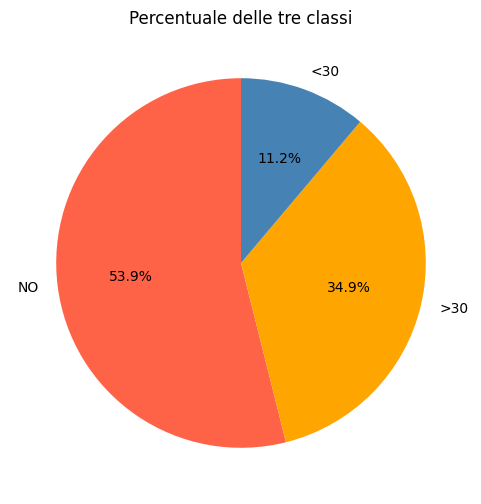

In [ ]:
#@title Target
y.head()

target_counts = y.squeeze().value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    target_counts.values,
    labels=target_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["tomato", "orange", "steelblue"]
)
plt.title("Percentuale delle tre classi")
plt.show()


Ciascuna riga del dataset contiene i dati relativi a un singolo **ricovero ospedaliero** di un paziente diabetico.

Riportiamo sotto il significato delle colonne e il modo in cui ciascuna variabile è rappresentata.

- `encounter_id`: identificatore univoco del ricovero ospedaliero, rappresentato da un numero intero

- `patient_nbr`: identificatore univoco del paziente, rappresentato da un numero intero

- `race`: razza/etnia del paziente, rappresentata come variabile categorica. I valori possibili sono `Caucasian`, `AfricanAmerican`, `Asian`, `Hispanic`, `Other`

- `gender`: genere del paziente, rappresentato come variabile categorica. I valori possibili sono `Male`, `Female`, `Unknown/Invalid`

- `age`: fascia di età del paziente, rappresentata come intervallo categorico. I valori sono intervalli di 10 anni, ad esempio `[0-10)`, `[10-20)`, ..., `[90-100)`

- `weight`: fascia di peso del paziente, rappresentata come intervallo categorico

- `admission_type_id`: tipologia di ammissione in ospedale, rappresentata tramite un codice categorico

- `discharge_disposition_id`: modalità di dimissione del paziente, rappresentata tramite un codice categorico

- `admission_source_id`: fonte o provenienza dell'ammissione ospedaliera, rappresentata tramite un codice categorico

- `time_in_hospital`: numero di giorni trascorsi dal paziente in ospedale durante il ricovero, rappresentato da un numero intero

- `payer_code`: codice del soggetto pagante o dell'assicurazione sanitaria, rappresentato come variabile categorica

- `medical_specialty`: specialità medica del medico o del reparto associato al ricovero, rappresentata come variabile categorica

- `num_lab_procedures`: numero di procedure di laboratorio effettuate durante il ricovero, rappresentato da un numero intero

- `num_procedures`: numero di procedure mediche diverse dagli esami di laboratorio effettuate durante il ricovero, rappresentato da un numero intero

- `num_medications`: numero di farmaci somministrati o prescritti durante il ricovero, rappresentato da un numero intero

- `number_outpatient`: numero di visite ambulatoriali effettuate dal paziente prima del ricovero, rappresentato da un numero intero

- `number_emergency`: numero di visite al pronto soccorso effettuate dal paziente prima del ricovero, rappresentato da un numero intero

- `number_inpatient`: numero di precedenti ricoveri ospedalieri del paziente, rappresentato da un numero intero

- `diag_1`: diagnosi principale del paziente, rappresentata tramite codice ICD-9

- `diag_2`: seconda diagnosi del paziente, rappresentata tramite codice ICD-9

- `diag_3`: terza diagnosi del paziente, rappresentata tramite codice ICD-9

- `number_diagnoses`: numero totale di diagnosi registrate per il paziente durante il ricovero, rappresentato da un numero intero

- `max_glu_serum`: risultato del test del glucosio sierico massimo, rappresentato come variabile categorica. I valori possibili sono `None`, `Norm`, `>200`, `>300`

- `A1Cresult`: risultato del test dell'emoglobina glicata HbA1c, rappresentato come variabile categorica. I valori possibili sono `None`, `Norm`, `>7`, `>8`

- `diabetesMed`: indica se al paziente è stato prescritto almeno un farmaco per il diabete, rappresentato come variabile binaria. I valori possibili sono `Yes` e `No`

- `change`: indica se è stata effettuata una modifica nella terapia farmacologica del paziente, rappresentato come variabile binaria. I valori possibili sono `Ch`, cioè terapia modificata, e `No`, cioè nessuna modifica

- `metformin`: variazione della prescrizione del farmaco Metformin, rappresentata come variabile categorica. I valori possibili sono `No`, `Steady`, `Up`, `Down`

- `repaglinide`: variazione della prescrizione del farmaco Repaglinide, rappresentata come variabile categorica. I valori possibili sono `No`, `Steady`, `Up`, `Down`

- `nateglinide`: variazione della prescrizione del farmaco Nateglinide, rappresentata come variabile categorica. I valori possibili sono `No`, `Steady`, `Up`, `Down`

- `chlorpropamide`: variazione della prescrizione del farmaco Chlorpropamide, rappresentata come variabile categorica. I valori possibili sono `No`, `Steady`, `Up`, `Down`

- `glimepiride`: variazione della prescrizione del farmaco Glimepiride, rappresentata come variabile categorica. I valori possibili sono `No`, `Steady`, `Up`, `Down`

- `glipizide`: variazione della prescrizione del farmaco Glipizide, rappresentata come variabile categorica. I valori possibili sono `No`, `Steady`, `Up`, `Down`

- `glyburide`: variazione della prescrizione del farmaco Glyburide, rappresentata come variabile categorica. I valori possibili sono `No`, `Steady`, `Up`, `Down`

- `pioglitazone`: variazione della prescrizione del farmaco Pioglitazone, rappresentata come variabile categorica. I valori possibili sono `No`, `Steady`, `Up`, `Down`

- `rosiglitazone`: variazione della prescrizione del farmaco Rosiglitazone, rappresentata come variabile categorica. I valori possibili sono `No`, `Steady`, `Up`, `Down`

- `insulin`: variazione della prescrizione di insulina, rappresentata come variabile categorica. I valori possibili sono `No`, `Steady`, `Up`, `Down`

La variabile target è `readmitted`: variabile target che indica se il paziente è stato riammesso in ospedale dopo la dimissione, rappresentata come variabile categorica. I valori possibili sono `NO`, cioè nessuna riammissione, `<30`, cioè riammissione entro 30 giorni, e `>30`, cioè riammissione dopo più di 30 giorni.

---

Le features in esame sono sia categoriche che continue.

Tra le **categoriche** troviamo: `race`, `gender`, `age`, `weight`, `admission_type_id`, `discharge_disposition_id`, `admission_source_id`, `payer_code`, `medical_specialty`, `diag_1`, `diag_2`, `diag_3`, `max_glu_serum`, `A1Cresult`, `metformin`, `repaglinide`,
`nateglinide`, `chlorpropamide`, `glimepiride`, `acetohexamide`, `glipizide`,
`glyburide`, `tolbutamide`, `pioglitazone`, `rosiglitazone`, `acarbose`,
`miglitol`, `troglitazone`, `tolazamide`, `examide`, `citoglipton`, `insulin`,
`glyburide-metformin`, `glipizide-metformin`, `glimepiride-pioglitazone`,
`metformin-rosiglitazone`, `metformin-pioglitazone`, `change`, `diabetesMed`,
`readmitted`

Tra le **continue** troviamo: `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_outpatient`, `number_emergency`, `number_inpatient`, `number_diagnoses`.

### Scrematura dei dati

#### Rilevazione degli id
Il dataset presenta due id irrilevanti per l'allenamento dei modelli.

Tramite la libreria `ucimlrepo`, la funzione `fetch_ucirepo` scarica e restituisce le features in `X` e la variabile target `readmitted` in `y`,
escludendo automaticamente le colonne identificatore (`encounter_id`, `patient_nbr`).

#### Rilevazione di valori nulli
Si rilevano, se presenti, valori nulli nel dataset.

In [ ]:
missing = pd.DataFrame({
    'missing': X.isnull().sum(),
    'missing_%': (X.isnull().sum() / len(X) * 100).round(2)
})
print(missing[missing['missing'] > 0].sort_values('missing_%', ascending=False))

                   missing  missing_%
weight               98569      96.86
max_glu_serum        96420      94.75
A1Cresult            84748      83.28
medical_specialty    49949      49.08
payer_code           40256      39.56
race                  2273       2.23
diag_3                1423       1.40
diag_2                 358       0.35
diag_1                  21       0.02


Consideriamo come primo criterio una soglia sull'80% di valori mancanti.

Le colonne `weight`, `max_glu_serum` e `A1Cresult` hanno una percentuale di valori mancanti molto elevata. Mantenerle introdurrebbe molte categorie poco informative e sbilanciate, percio le eliminiamo in questa prima fase.


In [ ]:
df = X.copy() # copia di X per mantenere l'originale intatto

In [ ]:
df.drop(columns=['weight', 'max_glu_serum', 'A1Cresult'], inplace=True)

Ora consideriamo `medical_specialty` e `payer_code`

In [ ]:
mid_missing_cols = ["payer_code", "medical_specialty"]

target = y.iloc[:, 0] if isinstance(y, pd.DataFrame) else y
readmitted_30 = (target == "<30").astype(int)

mid_missing_summary = pd.DataFrame({
    "missing": df[mid_missing_cols].isna().sum(),
    "missing_%": (df[mid_missing_cols].isna().mean() * 100).round(2),
    "n_unique_not_missing": df[mid_missing_cols].nunique(dropna=True)
})

mid_missing_summary

,missing,missing_%,n_unique_not_missing
payer_code,40256,39.56,17
medical_specialty,49949,49.08,72


In [ ]:
df["payer_code"].describe()

,payer_code
count,61510
unique,17
top,MC
freq,32439


In [ ]:
target_class_order = ["<30", ">30", "NO"]

def category_readmission_table(col, min_count=500):
    values = df[col].fillna("Missing").astype(str)
    counts = values.value_counts()
    values_grouped = values.where(values.isin(counts[counts >= min_count].index), "Other")

    tmp = pd.DataFrame({"category": values_grouped, "readmitted": y.squeeze()})
    count_table = pd.crosstab(tmp["category"], tmp["readmitted"]).reindex(columns=target_class_order)
    perc_table = pd.crosstab(tmp["category"], tmp["readmitted"], normalize="index").reindex(columns=target_class_order) * 100
    perc_table = perc_table.loc[count_table.sum(axis=1).sort_values(ascending=False).index]
    return count_table.loc[perc_table.index], perc_table.round(2)

/tmp/ipykernel_5374/4113266024.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(["ha_payer_code", "readmitted"])


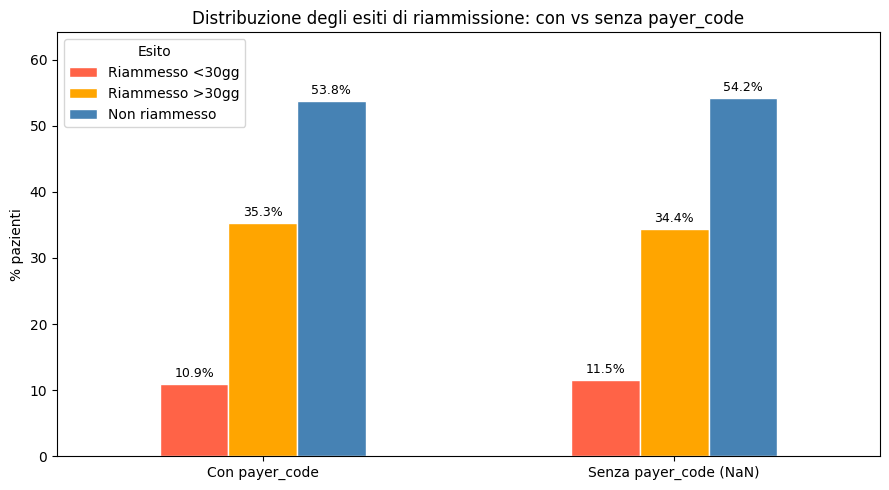

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Crea dataframe con gruppo e target originale
temp = pd.DataFrame({
    "ha_payer_code": df["payer_code"].notna().map({True: "Con payer_code", False: "Senza payer_code (NaN)"}),
    "readmitted": y.squeeze()
})

# Calcola la percentuale per ogni combinazione gruppo x esito
rates = (
    temp.groupby(["ha_payer_code", "readmitted"])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
    .unstack("readmitted")
)
rates.columns.name = None
rates = rates[["<30", ">30", "NO"]]
rates.rename(columns={"<30": "Riammesso <30gg", ">30": "Riammesso >30gg", "NO": "Non riammesso"}, inplace=True)

# Grafico
fig, ax = plt.subplots(figsize=(9, 5))
rates.plot(kind="bar", ax=ax, color=["tomato", "orange", "steelblue"], edgecolor="white", width=0.5)

# Etichette sulle barre
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

ax.set_xlabel("")
ax.set_ylabel("% pazienti")
ax.set_title("Distribuzione degli esiti di riammissione: con vs senza payer_code")
ax.set_xticklabels(rates.index, rotation=0)
ax.set_ylim(0, rates.values.max() + 10)
ax.legend(title="Esito")
plt.tight_layout()
plt.show()

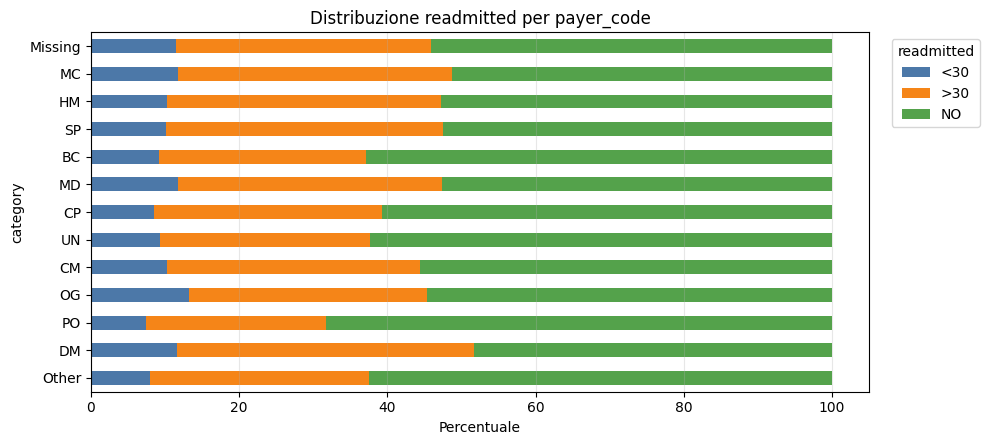

In [ ]:
def category_readmission_table(col, min_count=500):
    values = df[col].astype(object).fillna("Missing").astype(str)
    counts = values.value_counts()
    values_grouped = values.where(values.isin(counts[counts >= min_count].index), "Other")

    tmp = pd.DataFrame({"category": values_grouped, "readmitted": y.squeeze()})
    count_table = pd.crosstab(tmp["category"], tmp["readmitted"]).reindex(columns=target_class_order)
    perc_table = pd.crosstab(tmp["category"], tmp["readmitted"], normalize="index").reindex(columns=target_class_order) * 100
    perc_table = perc_table.loc[count_table.sum(axis=1).sort_values(ascending=False).index]
    return count_table.loc[perc_table.index], perc_table.round(2)

col = "payer_code"

count_table, perc_table = category_readmission_table(col, min_count=500)

plot_table = perc_table.iloc[::-1]
ax = plot_table.plot(kind="barh", stacked=True, figsize=(10, max(4, 0.35 * len(plot_table))), color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_title(f"Distribuzione readmitted per {col}")
ax.set_xlabel("Percentuale")
ax.grid(axis="x", alpha=0.3)
ax.legend(title="readmitted", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Dai grafici possiamo notare che i valori target delle persone a cui viene associato un `payer_code` sono simili ai valori di quelle senza, per tutti e tre i valori possibili del target. In piu, per ogni valore di payer_code che può assure, la distribuzione è molto simile tra tutti i gruppi.

Decidiamo quindi di **non considerare** tale variabile.

In [ ]:
df.drop(columns=["payer_code"], inplace=True)

Procediamo ad analizzare `medical_specialty`.

In [ ]:
df["medical_specialty"].describe()

,medical_specialty
count,51817
unique,72
top,InternalMedicine
freq,14635


/tmp/ipykernel_5374/980744784.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby(["ha_medical_specialty", "readmitted"])


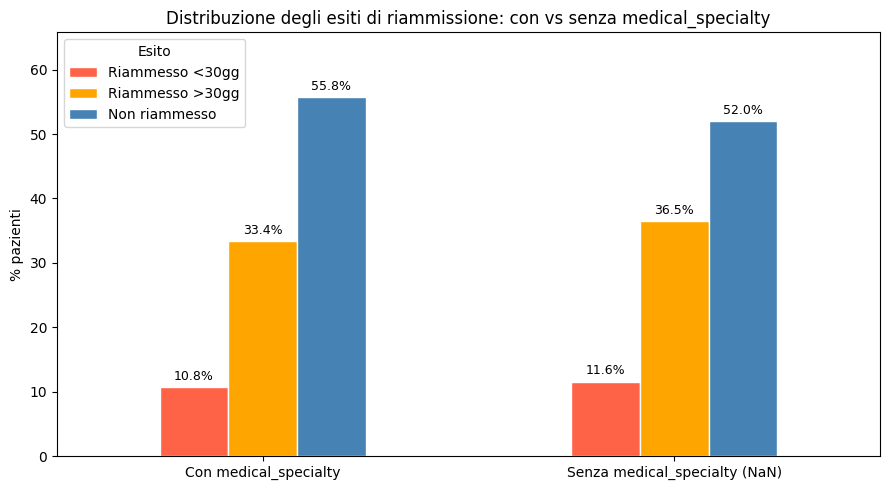

In [ ]:
temp = pd.DataFrame({
    "ha_medical_specialty": df["medical_specialty"].notna().map({True: "Con medical_specialty", False: "Senza medical_specialty (NaN)"}),
    "readmitted": y.squeeze()
})

rates = (
    temp.groupby(["ha_medical_specialty", "readmitted"])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
    .unstack("readmitted")
)
rates.columns.name = None
rates = rates[["<30", ">30", "NO"]]
rates.rename(columns={"<30": "Riammesso <30gg", ">30": "Riammesso >30gg", "NO": "Non riammesso"}, inplace=True)

fig, ax = plt.subplots(figsize=(9, 5))
rates.plot(kind="bar", ax=ax, color=["tomato", "orange", "steelblue"], edgecolor="white", width=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

ax.set_xlabel("")
ax.set_ylabel("% pazienti")
ax.set_title("Distribuzione degli esiti di riammissione: con vs senza medical_specialty")
ax.set_xticklabels(rates.index, rotation=0)
ax.set_ylim(0, rates.values.max() + 10)
ax.legend(title="Esito")
plt.tight_layout()
plt.show()

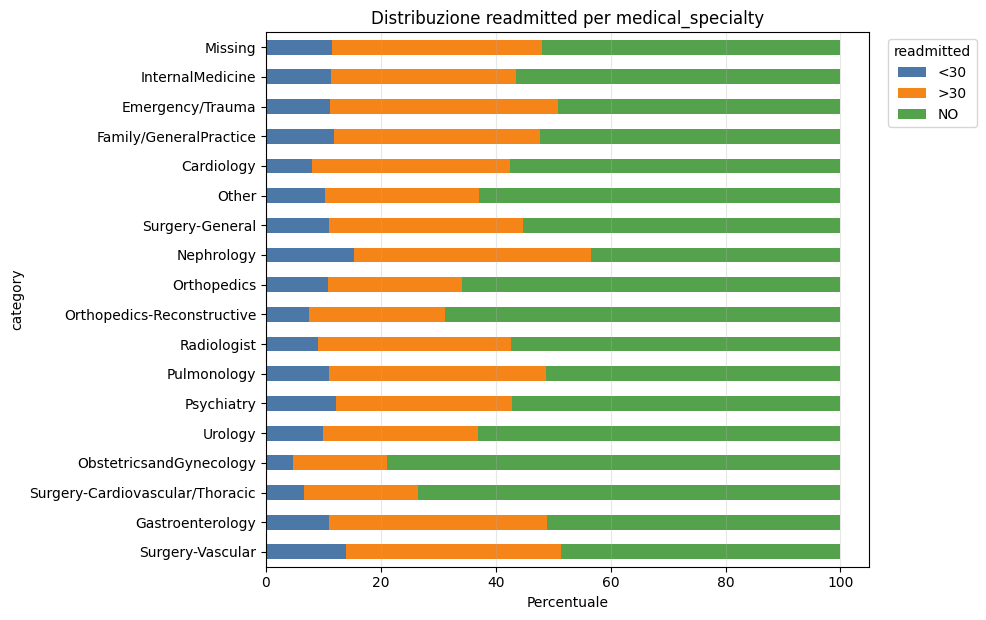

In [ ]:
col = "medical_specialty"

count_table, perc_table = category_readmission_table(col, min_count=500)

plot_table = perc_table.iloc[::-1]
ax = plot_table.plot(kind="barh", stacked=True, figsize=(10, max(4, 0.35 * len(plot_table))), color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_title(f"Distribuzione readmitted per {col}")
ax.set_xlabel("Percentuale")
ax.grid(axis="x", alpha=0.3)
ax.legend(title="readmitted", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Per gli stessi motivi di payer_code, si procede eliminando la `medical_specialty`.

In [ ]:
df.drop(columns=["medical_specialty"], inplace=True)

####Rimozione pazienti deceduti

Analizzando i dati, la variabile `discharge_disposition_id` contiene alcuni codici associati a pazienti deceduti. Questi casi vengono rimossi dal dataset perché non sono coerenti con l’obiettivo predittivo del progetto: un paziente deceduto, per definizione, non può essere riammesso in ospedale.

Mantenere queste osservazioni potrebbe introdurre distorsione nel modello, poiché l’assenza di riammissione non dipenderebbe da un basso rischio clinico, ma da una condizione finale o non comparabile.


In [ ]:
# Codici di dimissione da escludere: decesso
leakage_codes = [11, 19, 20, 21]

mask = ~df["discharge_disposition_id"].isin(leakage_codes)

df = df[mask]
y = y[mask]

len(df)

100114

##Statistiche generali del dataset scremato

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,100114.0,4.389646,2.974531,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,100114.0,42.943305,19.620940,1.0,31.0,44.0,57.0,132.0
num_procedures,100114.0,1.330723,1.700286,0.0,0.0,1.0,2.0,6.0
num_medications,100114.0,15.981821,8.092511,1.0,10.0,15.0,20.0,81.0
number_outpatient,100114.0,0.369429,1.264006,0.0,0.0,0.0,0.0,42.0
number_emergency,100114.0,0.198334,0.935537,0.0,0.0,0.0,0.0,76.0
number_inpatient,100114.0,0.632829,1.261833,0.0,0.0,0.0,1.0,21.0
number_diagnoses,100114.0,7.409164,1.938288,1.0,6.0,8.0,9.0,16.0


In [ ]:
df_copy = df.copy()
y_copy = y.copy()

Procediamo con la divisione tra variabili numeriche e categoriche e analizziamo l'utilità di ciascuna variabile nella predizione della variabile target **readmitted**

In [ ]:
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

categorical_cols = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "diag_1",
    "diag_2",
    "diag_3",
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
    "change",
    "diabetesMed"
]

In [ ]:
def plot_numeric_variable_analysis(df, col, target, bins=10):
    target = target.squeeze()

    target_order = ["<30", ">30", "NO"]
    target_labels = {
        "<30": "Riammesso <30gg",
        ">30": "Riammesso >30gg",
        "NO": "Non riammesso"
    }

    colors = ["tomato", "orange", "steelblue"]

    temp = pd.DataFrame({
        col: df[col],
        "readmitted": target
    }).dropna()

    temp["readmitted"] = pd.Categorical(
        temp["readmitted"],
        categories=target_order,
        ordered=True
    )

    manual_bin_cols = {
        "number_outpatient": {
            "bins": [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 10.5, 20.5, np.inf],
            "labels": ["0", "1", "2", "3", "4", "5", "6-10", "11-20", ">20"]
        },
        "number_emergency": {
            "bins": [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 10.5, 20.5, np.inf],
            "labels": ["0", "1", "2", "3", "4", "5", "6-10", "11-20", ">20"]
        },
        "number_inpatient": {
            "bins": [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 10.5, 20.5, np.inf],
            "labels": ["0", "1", "2", "3", "4", "5", "6-10", "11-20", ">20"]
        }
    }

    if col in manual_bin_cols:
        bin_info = manual_bin_cols[col]

        temp["bin"] = pd.cut(
            temp[col],
            bins=bin_info["bins"],
            labels=bin_info["labels"],
            include_lowest=True
        )

        bin_order = bin_info["labels"]

    else:
        temp["bin"] = pd.cut(
            temp[col],
            bins=bins,
            include_lowest=True
        )

        bin_order = temp["bin"].cat.categories

    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    # 1. Countplot per intervalli della variabile numerica
    sns.countplot(
        data=temp,
        x="bin",
        order=bin_order,
        ax=axes[0],
        color="steelblue",
        edgecolor="white"
    )

    for container in axes[0].containers:
        axes[0].bar_label(container, padding=3, fontsize=7)

    axes[0].set_title(f"Frequenza dei range di {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Numero di pazienti")
    axes[0].tick_params(axis="x", rotation=45)

    # 2. Boxplot grouped by readmitted
    temp.boxplot(
        column=col,
        by="readmitted",
        showmeans=True,
        ax=axes[1],
        grid=True
    )

    axes[1].set_title(f"Boxplot grouped by readmitted\n{col}")
    axes[1].set_xlabel("Esito di riammissione")
    axes[1].set_ylabel(col)
    axes[1].set_xticklabels([
        "Riammesso <30gg",
        "Riammesso >30gg",
        "Non riammesso"
    ])

    fig.suptitle("")

    # 3. Percentuale degli esiti per intervalli della variabile
    rates = pd.crosstab(
        temp["bin"],
        temp["readmitted"],
        normalize="index"
    ) * 100

    rates = rates.reindex(index=bin_order, columns=target_order).fillna(0)
    rates.columns = [target_labels[c] for c in target_order]

    rates.plot(
        kind="bar",
        stacked=True,
        ax=axes[2],
        color=colors,
        edgecolor="white",
        width=0.8
    )

    for container in axes[2].containers:
        axes[2].bar_label(
            container,
            fmt="%.1f%%",
            label_type="center",
            fontsize=7
        )

    axes[2].set_title(f"Percentuale degli esiti per intervalli di {col}")
    axes[2].set_xlabel(col)
    axes[2].set_ylabel("% pazienti")
    axes[2].tick_params(axis="x", rotation=45)
    axes[2].legend(title="Esito", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

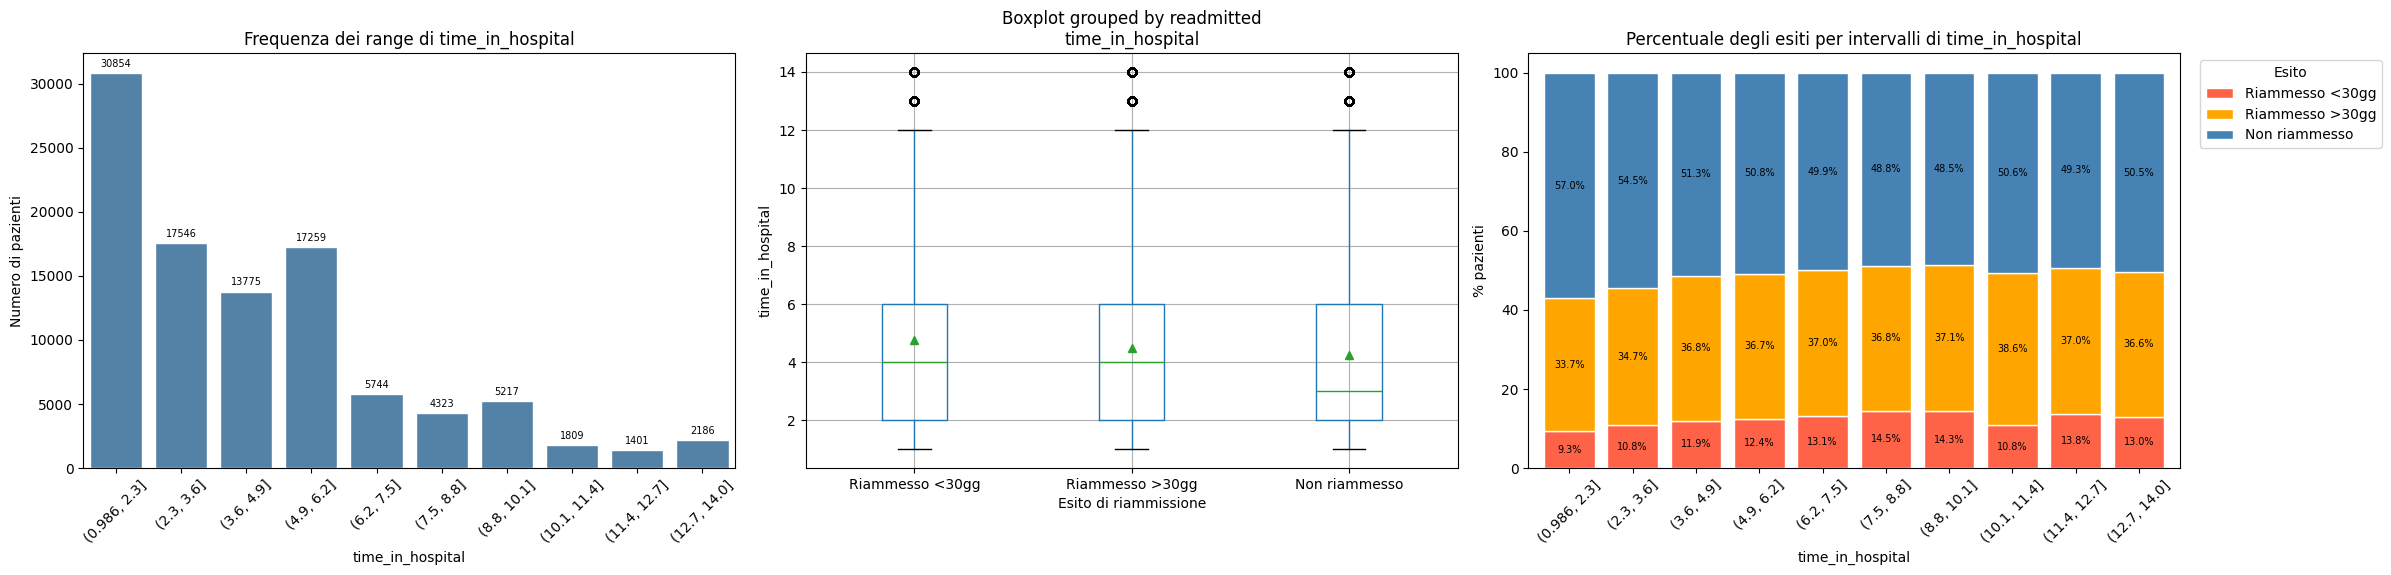

In [ ]:
#@title Grafico analisi: time_in_hospital
plot_numeric_variable_analysis(df, "time_in_hospital", y)

**Commento sul grafico di `time_in_hospital`:**

La variabile time_in_hospital viene mantenuta perché rappresenta la durata della degenza ospedaliera, un’informazione clinicamente rilevante e potenzialmente associata alla gravità del paziente. Dal grafico si osserva che la distribuzione degli esiti varia al crescere degli intervalli di permanenza: le degenze più lunghe mostrano una quota leggermente inferiore di pazienti non riammessi e una quota maggiore di riammissioni. Inoltre, il boxplot evidenzia differenze tra i gruppi di esito, suggerendo che la durata del ricovero possa contribuire alla capacità predittiva del modello. Per questi motivi, la variabile viene mantenuta nel dataset.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


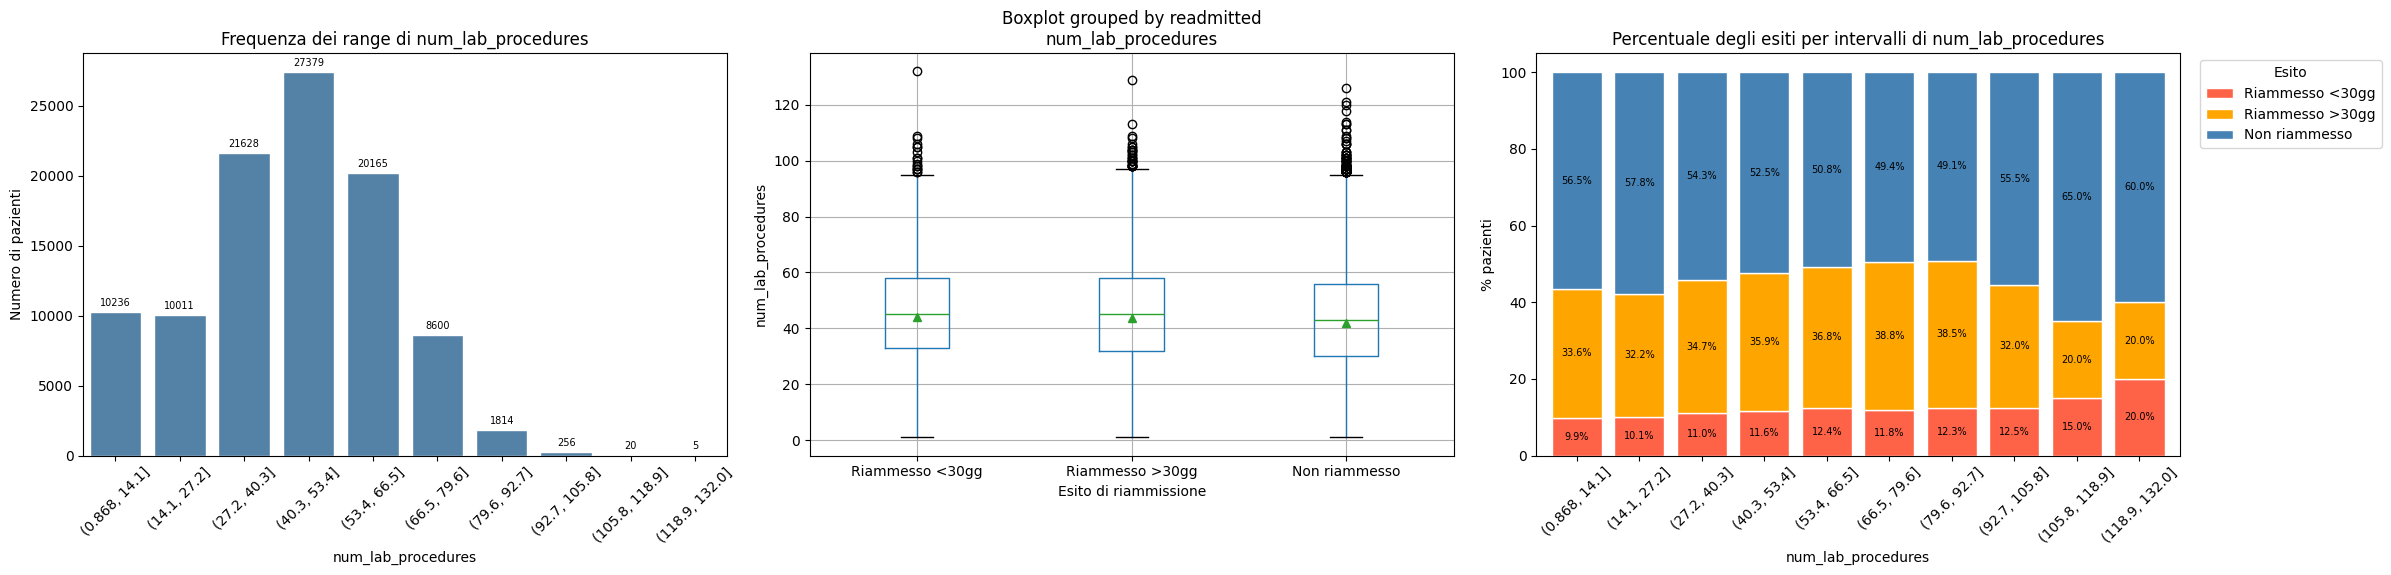

In [ ]:
#@title Grafico analisi: num_lab_procedures
plot_numeric_variable_analysis(df, "num_lab_procedures", y)

**Commento sul grafico di `num_lab_procedures`:**

La variabile num_lab_procedures presenta una distribuzione concentrata nei valori intermedi. Dal boxplot emerge una sovrapposizione tra le classi della target, quindi la variabile non risulta fortemente discriminante da sola. Tuttavia, le percentuali degli esiti mostrano un lieve aumento della riammissione entro 30 giorni nei range più elevati di procedure di laboratorio. Considerando anche il possibile significato clinico della variabile, legato alla complessità del paziente, si decide di mantenerla nel dataset.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


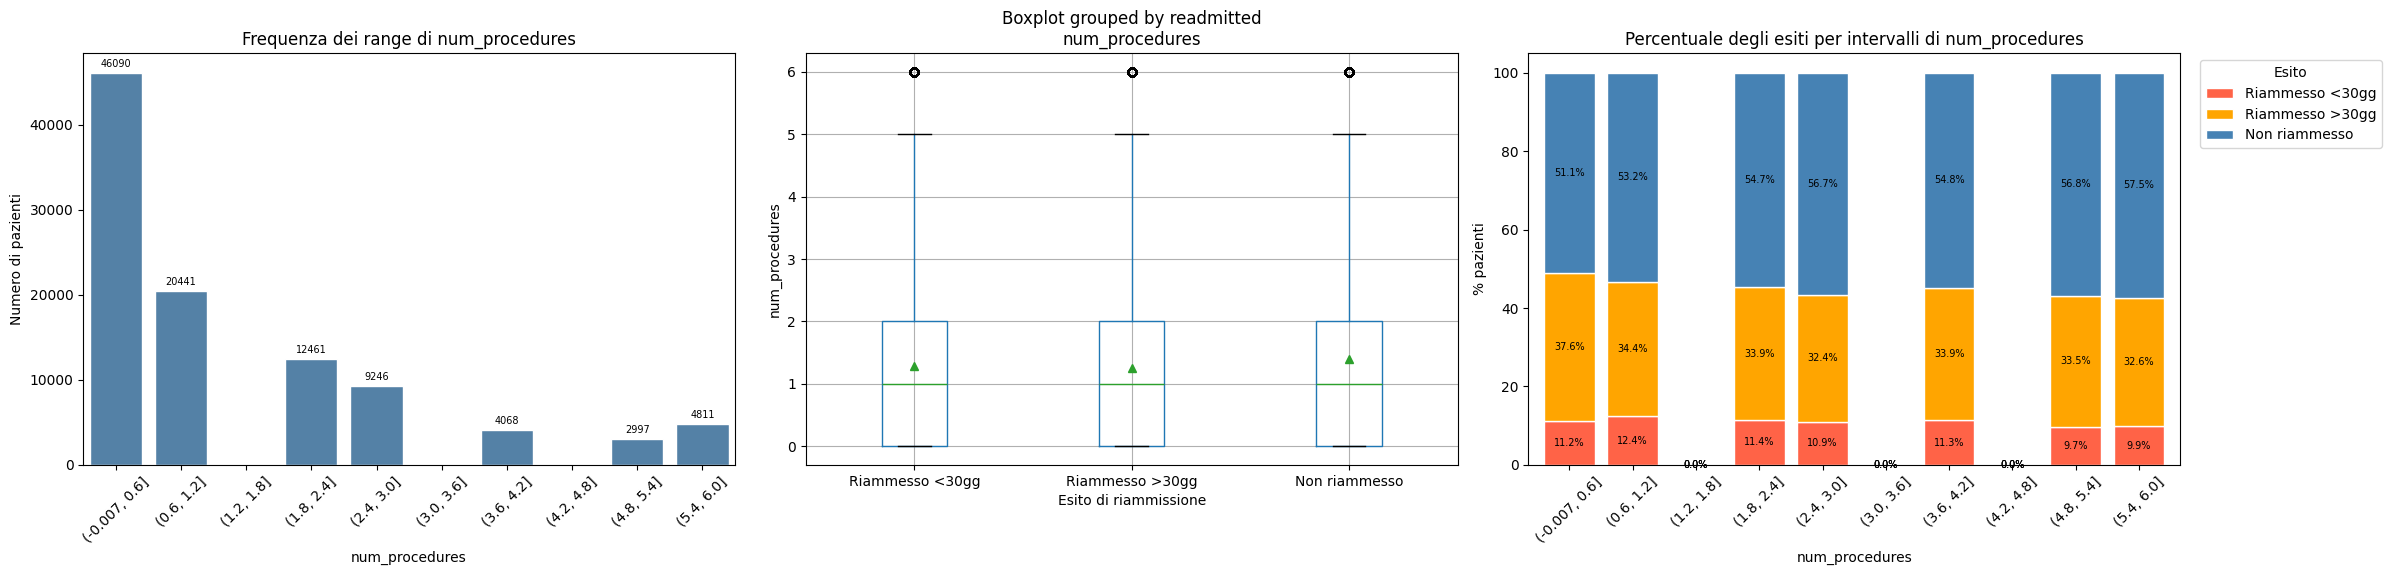

In [ ]:
#@title Grafico analisi: num_procedures
plot_numeric_variable_analysis(df, "num_procedures", y)

**Commento sul grafico di `num_procedures`:**

La variabile num_procedures risulta fortemente concentrata nei valori più bassi. Dal boxplot si osserva una forte sovrapposizione tra le classi della target, indicando un limitato potere discriminante della variabile considerata singolarmente. Anche la distribuzione percentuale degli esiti per intervalli non mostra variazioni marcate né un andamento monotono evidente. Tuttavia, poiché la variabile descrive l’intensità degli interventi/procedure durante il ricovero e potrebbe contribuire in combinazione con altre feature, si decide di mantenerla nel dataset, rimandando l’eventuale esclusione alla fase di modellazione.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


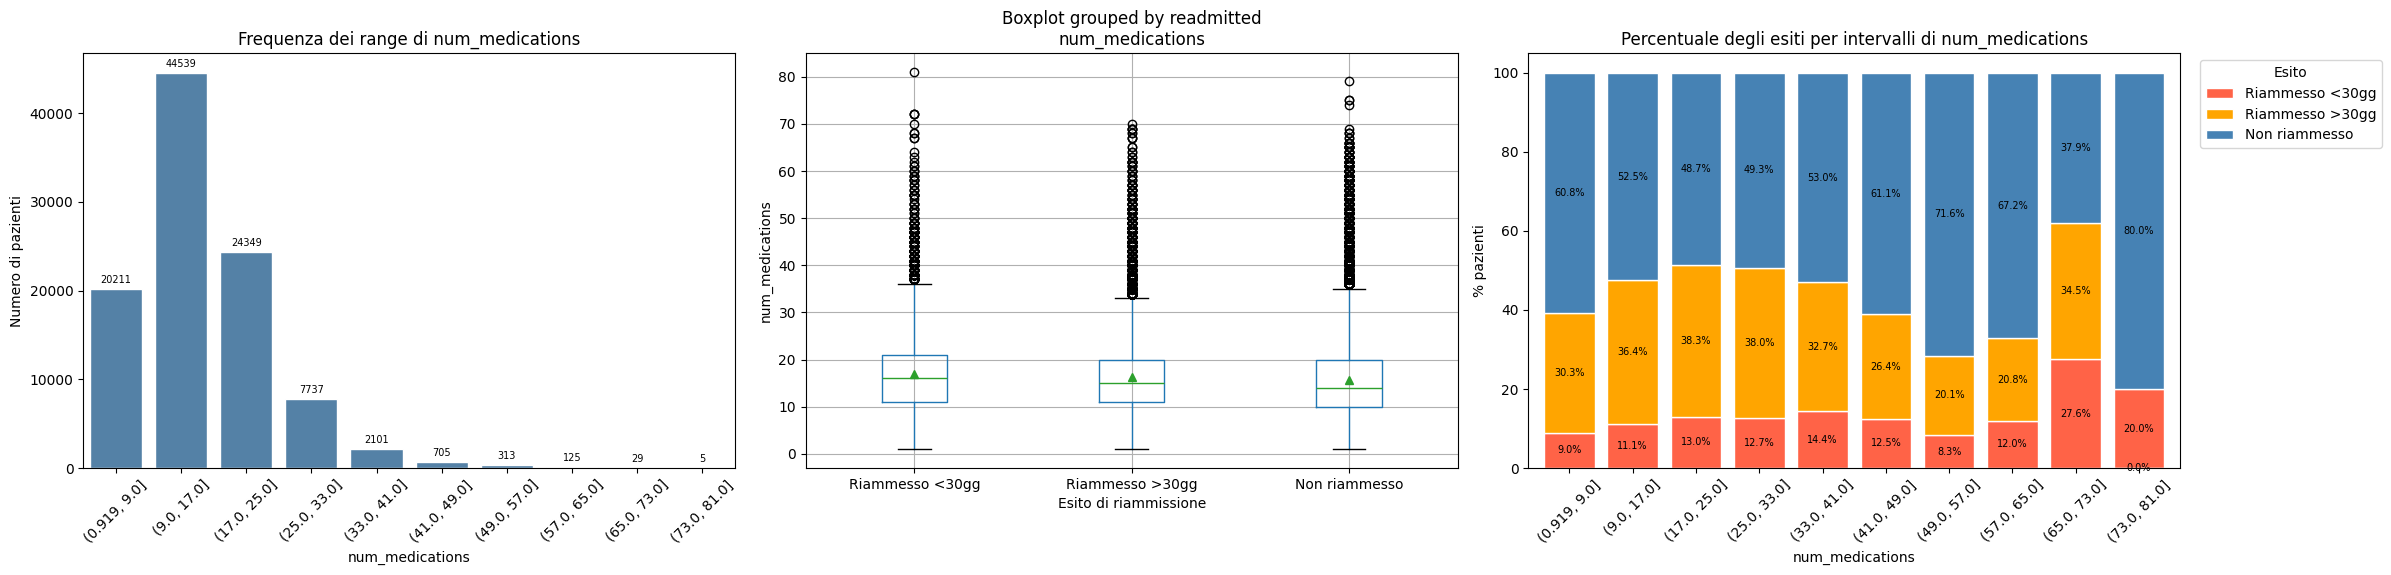

In [ ]:
#@title Grafico analisi: num_medications
plot_numeric_variable_analysis(df, "num_medications", y)

**Commento sul grafico di `num_medications`:**

La variabile num_medications mostra una distribuzione concentrata nei valori medio-bassi, con pochi pazienti nei range più elevati. Dal boxplot emerge una leggera differenza tra le classi, con valori medi lievemente superiori per i pazienti riammessi entro 30 giorni. Anche la distribuzione percentuale degli esiti suggerisce un aumento del tasso di riammissione precoce nei range intermedi della variabile. Considerata inoltre la rilevanza clinica del numero di farmaci come indicatore della complessità del paziente, si decide di mantenere la variabile nel dataset.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere



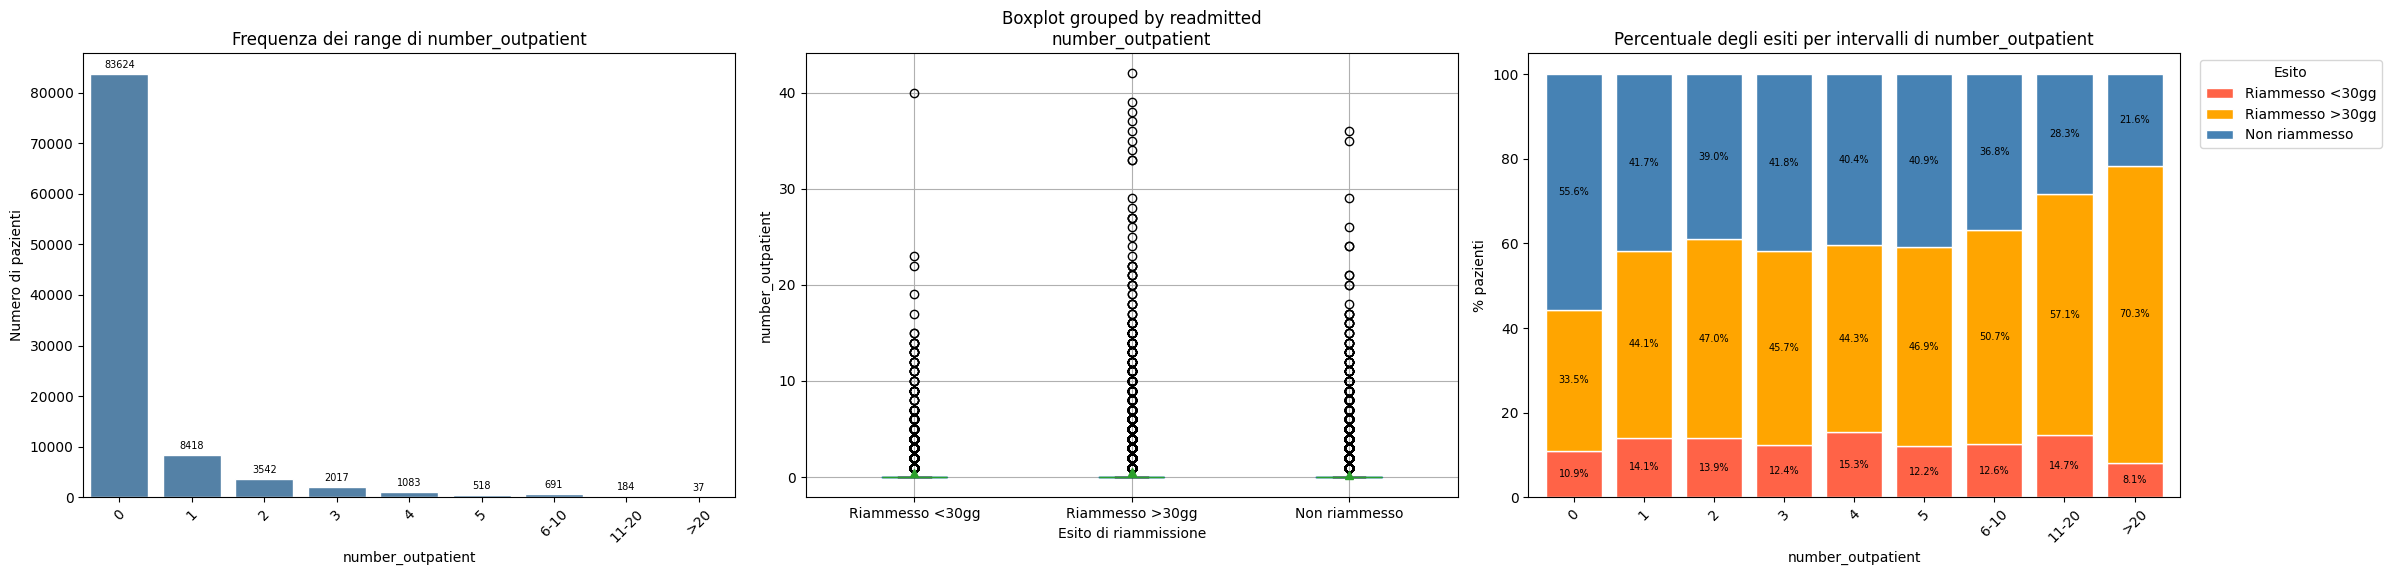

In [ ]:
#@title Grafico analisi: number_outpatient
plot_numeric_variable_analysis(df, "number_outpatient", y)

**Commento sul grafico di `number_outpatient`:**

La variabile number_outpatient va mantenuta perché rappresenta l’intensità di utilizzo nell'anno precedente dei servizi sanitari, quindi può essere un indicatore indiretto dello stato clinico generale del paziente o della presenza di condizioni croniche. Dal grafico si osserva che, all’aumentare del numero di visite outpatient, diminuisce progressivamente la quota di pazienti “Non riammesso” e aumenta soprattutto la quota di pazienti riammessi dopo 30 giorni. Questo suggerisce una relazione informativa con l’esito di riammissione.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


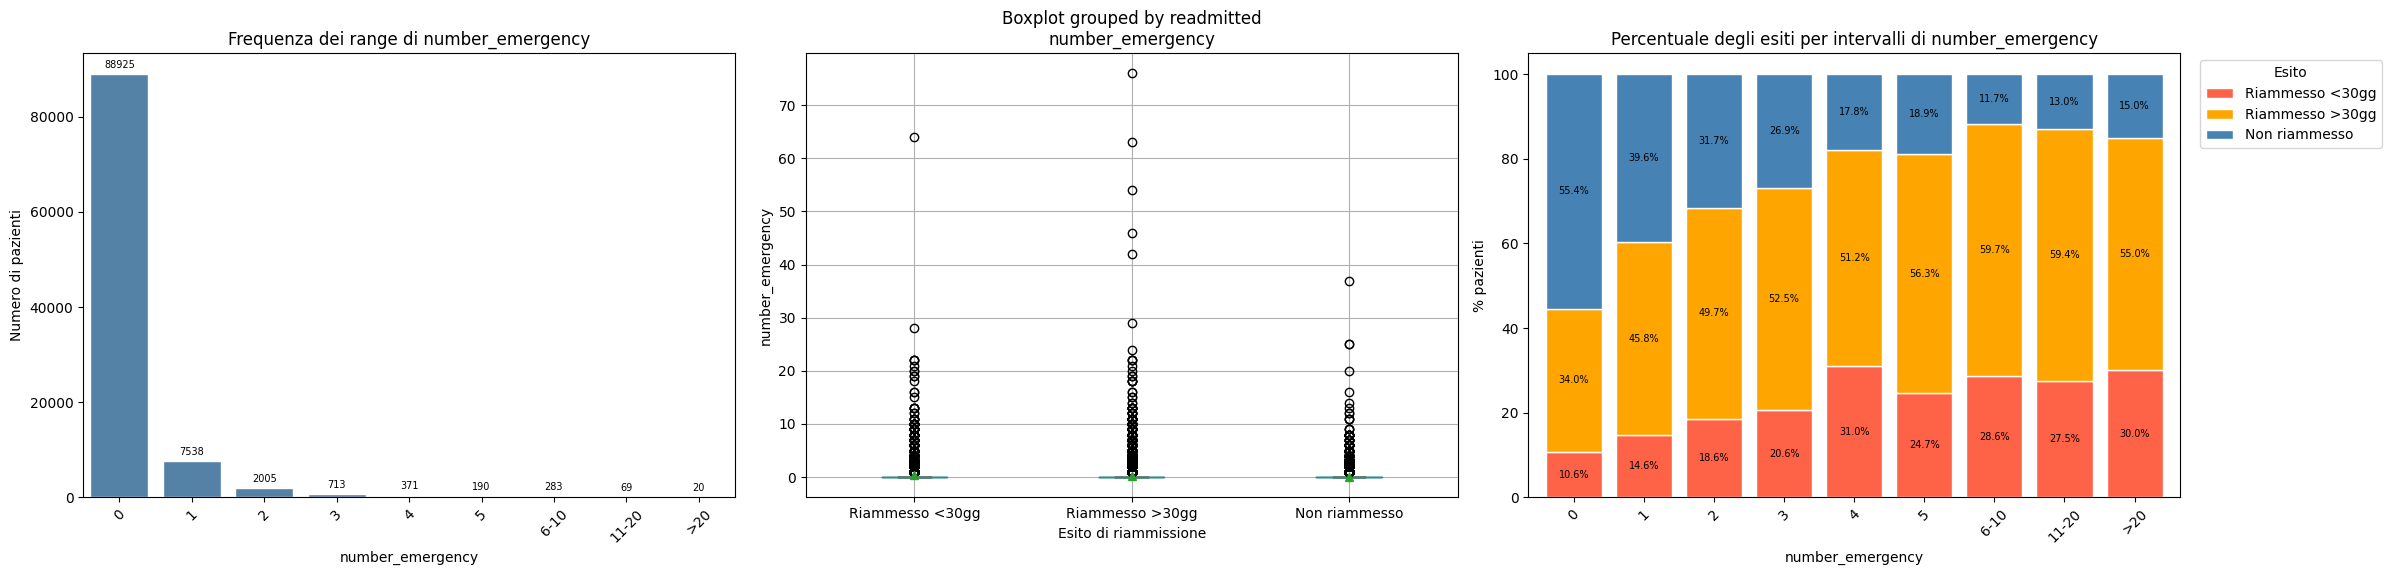

In [ ]:
#@title Grafico analisi: number_emergency
plot_numeric_variable_analysis(df, "number_emergency", y)

**Commento sul grafico di `number_emergency`:**

La variabile number_emergency va mantenuta perché rappresenta il numero di accessi in emergenza precedenti al ricovero, quindi è un indicatore diretto di instabilità clinica, fragilità del paziente o difficoltà nella gestione della malattia fuori dall’ospedale. Dal grafico emerge un andamento chiaro: i pazienti con number_emergency = 0 hanno una percentuale più alta di “Non riammesso”, mentre all’aumentare degli accessi in emergenza cresce sensibilmente la quota di pazienti riammessi, soprattutto entro 30 giorni. Questo suggerisce che la variabile contiene informazione utile per predire il rischio di riammissione.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


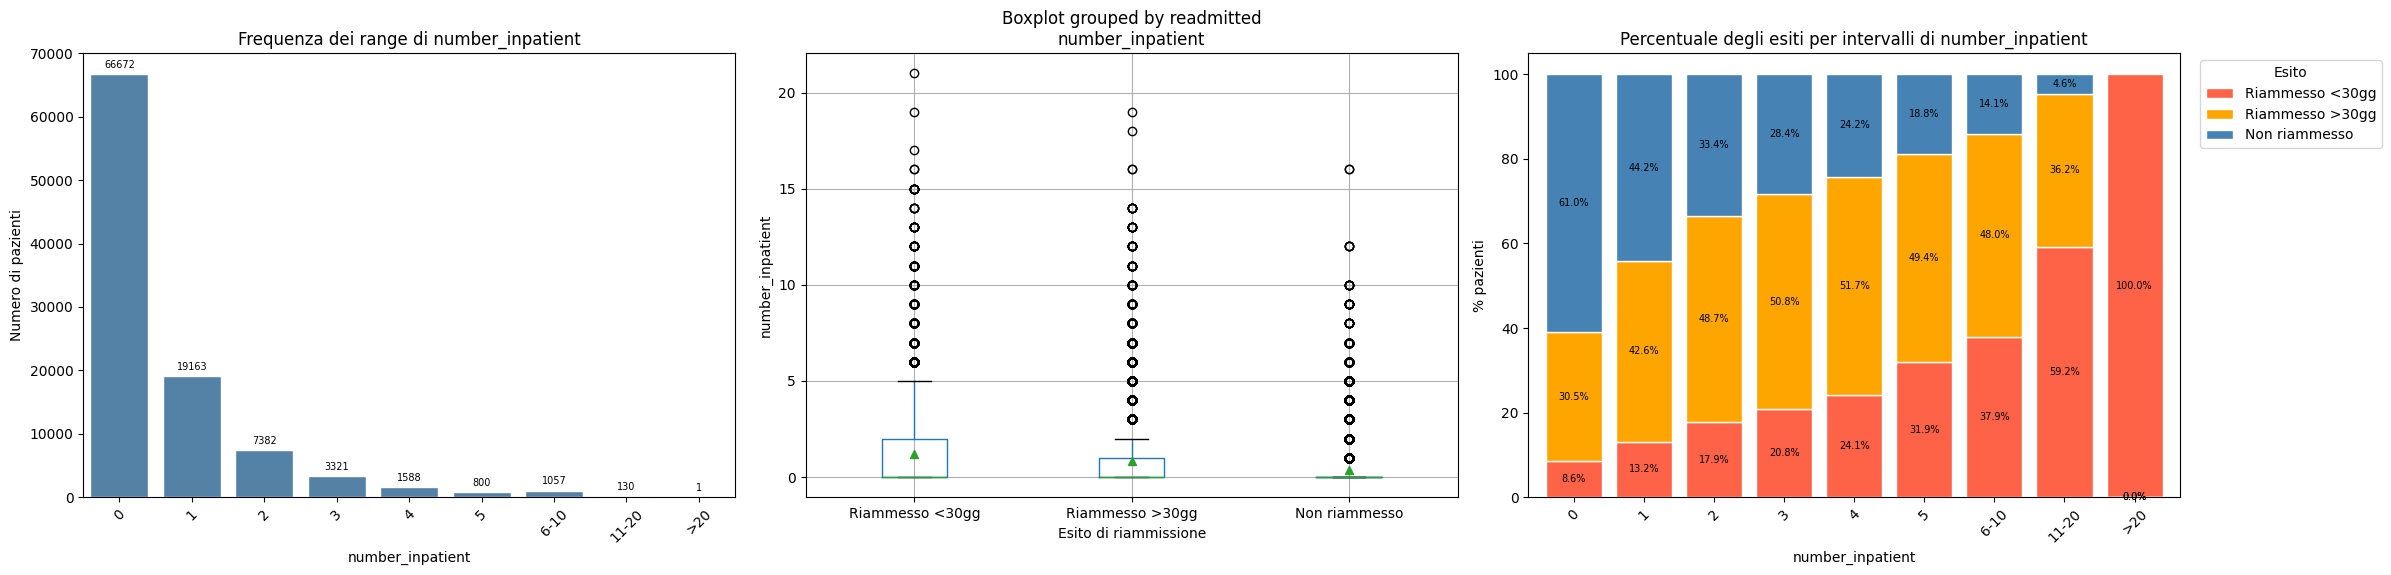

In [ ]:
#@title Grafico analisi: number_inpatient
plot_numeric_variable_analysis(df, "number_inpatient", y)

**Commento sul grafico di `number_inpatient`:**

La variabile number_inpatient va mantenuta perché rappresenta il numero di ricoveri ospedalieri dell'anno precedente, quindi è un indicatore diretto della storia clinica recente e della fragilità del paziente. Dal grafico emerge una relazione molto chiara con l’esito di riammissione: al crescere del numero di ricoveri precedenti diminuisce progressivamente la percentuale di pazienti non riammessi e aumenta la quota di pazienti riammessi, sia entro 30 giorni sia dopo 30 giorni. Questo indica che la variabile contiene informazione predittiva rilevante per il target.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


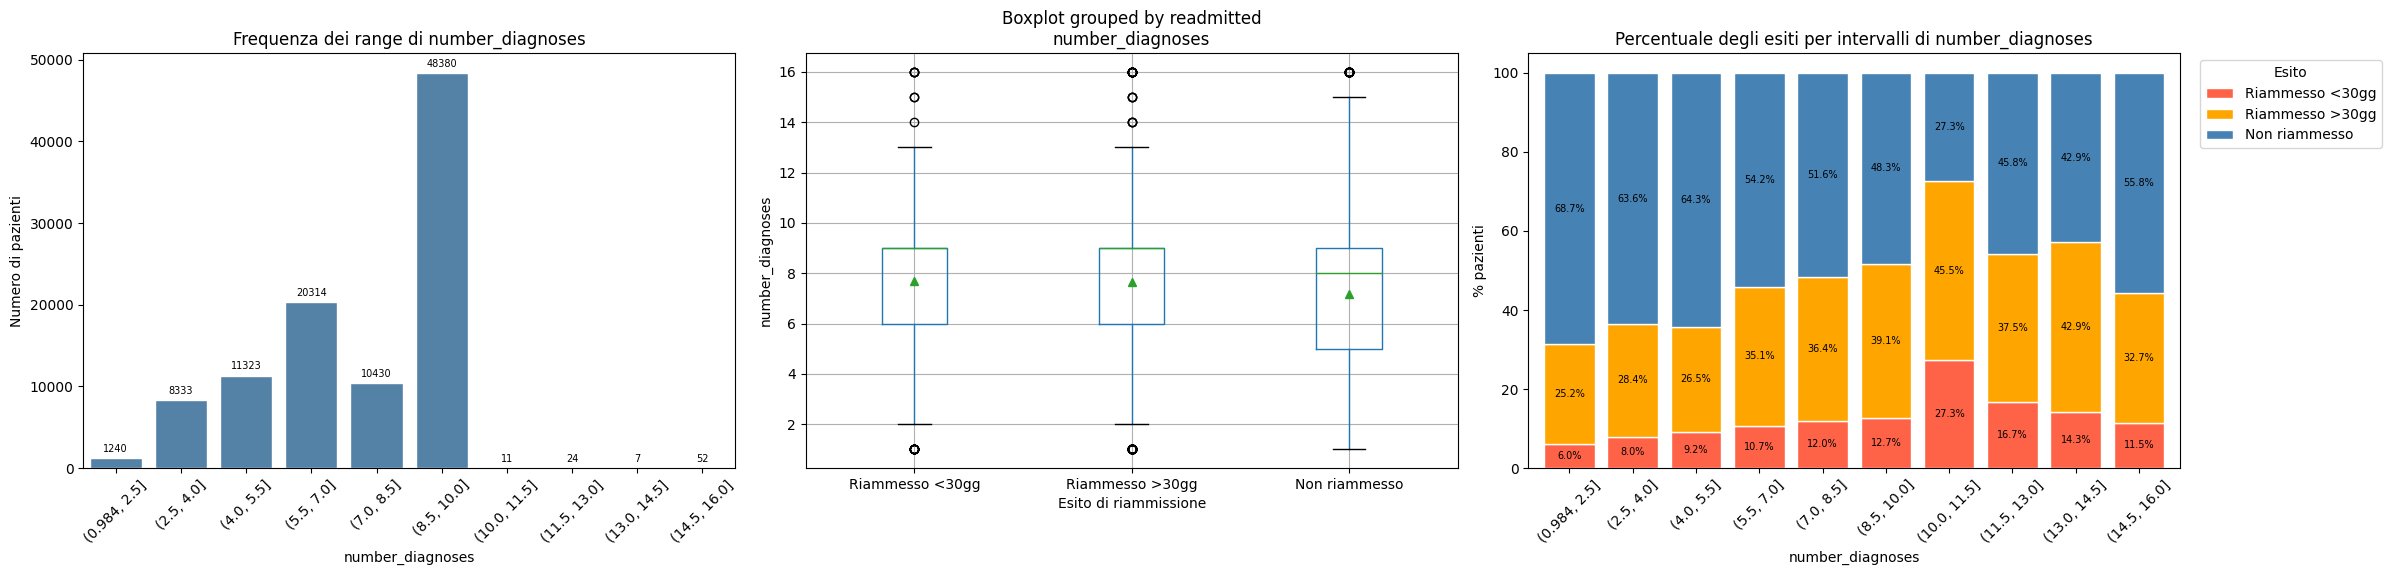

In [ ]:
#@title Grafico analisi: number_diagnoses
plot_numeric_variable_analysis(df, "number_diagnoses", y)

**Commento sul grafico di `number_diagnoses`:**

La variabile number_diagnoses viene mantenuta perché rappresenta il numero di diagnosi associate al paziente, quindi può essere interpretata come un indicatore della complessità clinica. Dal boxplot si osserva che i pazienti riammessi tendono ad avere valori leggermente più alti rispetto ai non riammessi, e nel grafico percentuale alcune classi con numero maggiore di diagnosi mostrano una quota più elevata di riammissioni. Questo suggerisce che la variabile può contribuire alla previsione dell’esito.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


In [ ]:
def plot_categorical_variable_analysis(df, col, target, top_n=10):
    target = target.squeeze()

    target_order = ["<30", ">30", "NO"]
    target_labels = {
        "<30": "Riammesso <30gg",
        ">30": "Riammesso >30gg",
        "NO": "Non riammesso"
    }

    colors_target = ["tomato", "orange", "steelblue"]

    temp = pd.DataFrame({
        col: df[col].astype(object).fillna("Missing").astype(str),
        "readmitted": target
    }).dropna()

    counts = temp[col].value_counts()
    top_categories = counts.head(top_n).index
    temp[col] = temp[col].where(temp[col].isin(top_categories), "Other")

    # Ordine naturale delle categorie, non per frequenza
    if col == "age":
        category_order = [
            "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
            "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
        ]
        category_order = [cat for cat in category_order if cat in temp[col].unique()]

    else:
        categories_without_other = [
            cat for cat in temp[col].unique()
            if cat != "Other"
        ]

        try:
            category_order = sorted(categories_without_other, key=lambda x: float(x))
        except ValueError:
            category_order = sorted(categories_without_other)

    if "Other" in temp[col].unique():
        category_order.append("Other")

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # 1. Countplot
    sns.countplot(
        data=temp,
        x=col,
        order=category_order,
        ax=axes[0],
        color="steelblue",
        edgecolor="white"
    )

    for container in axes[0].containers:
        axes[0].bar_label(container, padding=3, fontsize=8)

    axes[0].set_title(f"Frequenza delle categorie di {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Numero di pazienti")
    axes[0].tick_params(axis="x", rotation=45)

    # 2. Barplot stacked normalizzato
    rates = pd.crosstab(
        temp[col],
        temp["readmitted"],
        normalize="index"
    ) * 100

    rates = rates.reindex(index=category_order, columns=target_order)
    rates.columns = [target_labels[c] for c in target_order]

    rates.plot(
        kind="bar",
        stacked=True,
        ax=axes[1],
        color=colors_target,
        edgecolor="white",
        width=0.8
    )

    for container in axes[1].containers:
        axes[1].bar_label(
            container,
            fmt="%.1f%%",
            label_type="center",
            fontsize=7
        )

    axes[1].set_title(f"Distribuzione degli esiti per {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("% pazienti")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].legend(title="Esito", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

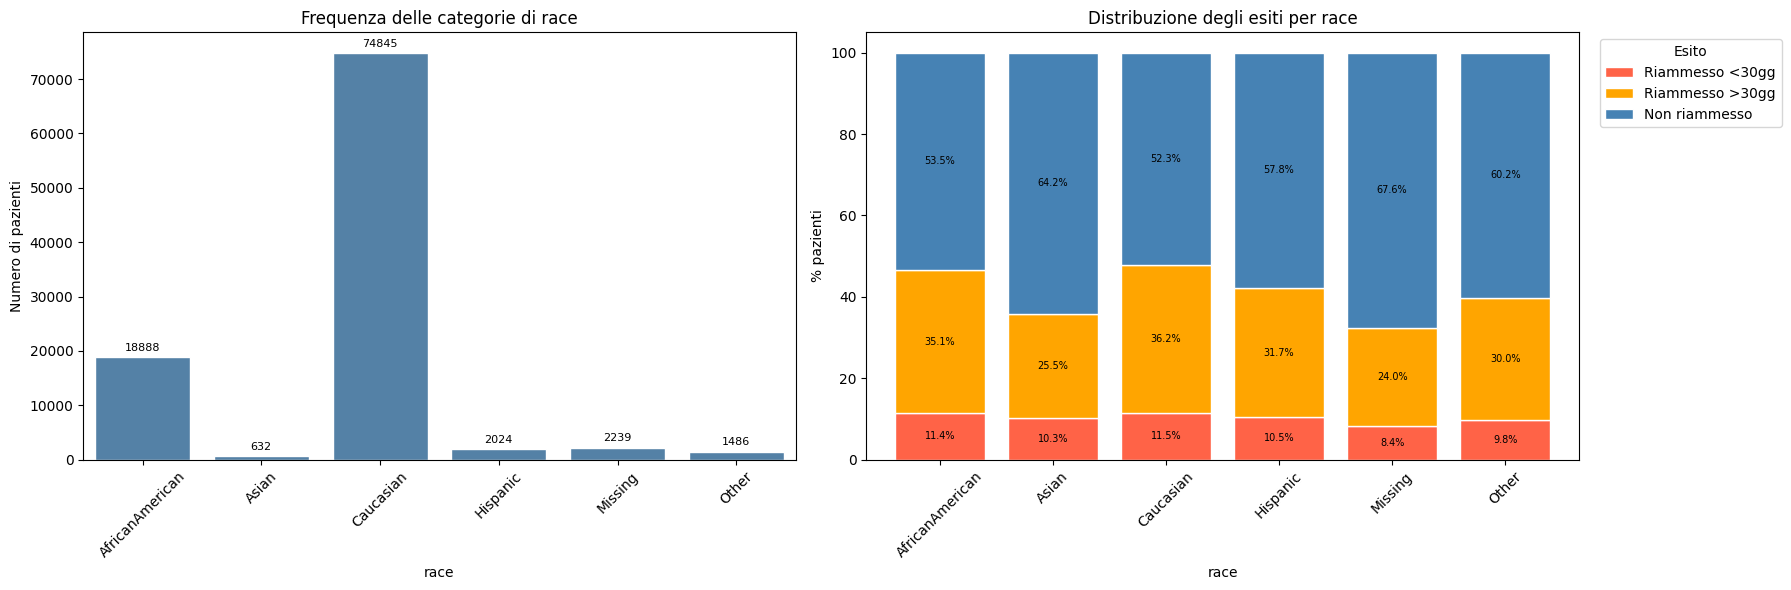

In [ ]:
#@title Grafico analisi: race
plot_categorical_variable_analysis(df, "race", y, top_n=20)

**Commento sul grafico di `race`:**

La variabile race non viene mantenuta perché presenta una distribuzione sbilanciata verso la categoria “Caucasian”, mentre alcune categorie hanno numerosità molto più ridotte. Sebbene siano presenti differenze nella distribuzione degli esiti, tali differenze potrebbero non riflettere una relazione clinica diretta, ma essere legate a fattori indiretti e difficili da interpretare. Inoltre, trattandosi di una variabile sensibile, il suo utilizzo potrebbe introdurre bias nel modello predittivo. Per questi motivi si ritiene opportuno eliminarla dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["race"], inplace=True)

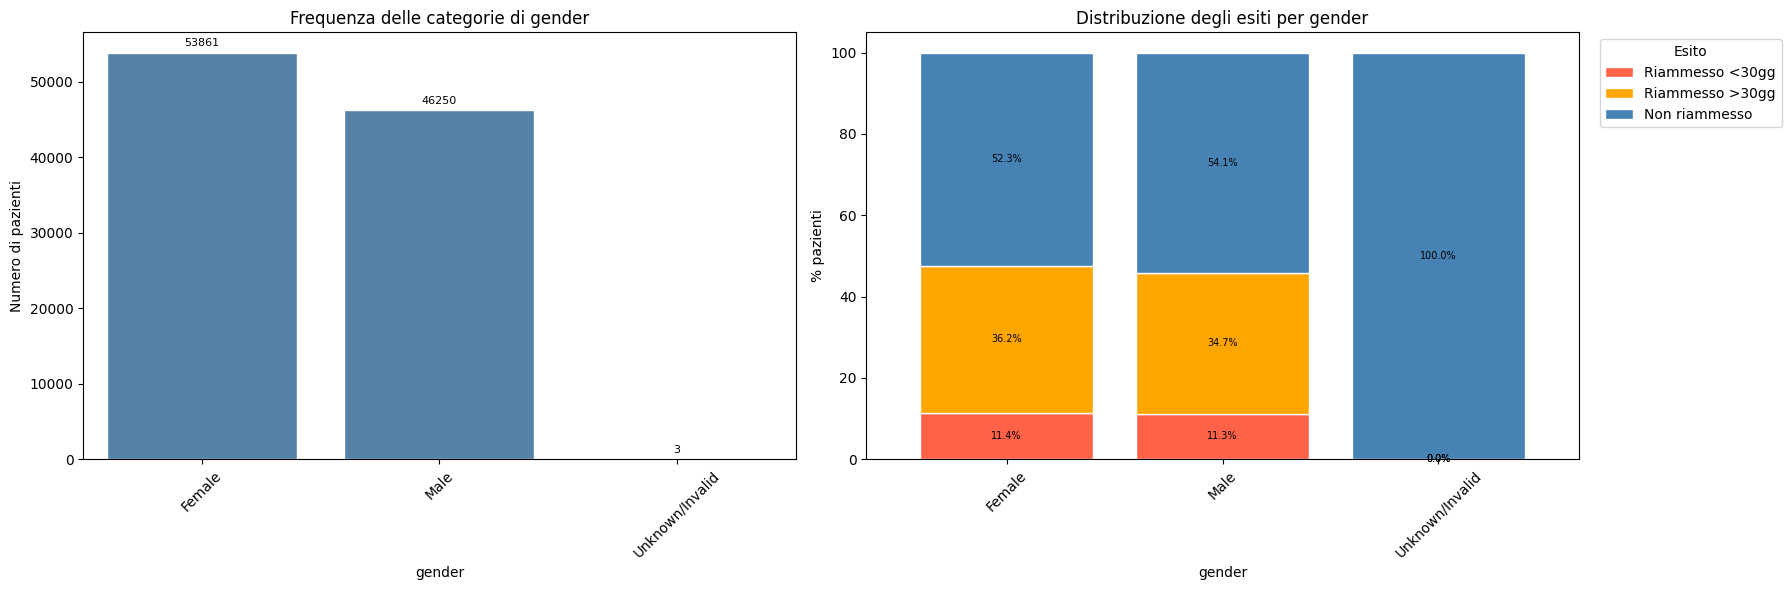

In [ ]:
#@title Grafico analisi: gender
plot_categorical_variable_analysis(df, "gender", y, top_n=20)

**Commento sul grafico di `gender`:**

La variabile gender non viene mantenuta perché, pur essendo ben distribuita tra le categorie principali “Female” e “Male”, non mostra differenze rilevanti nella distribuzione degli esiti. Le percentuali di riammissione e non riammissione risultano infatti molto simili tra maschi e femmine, suggerendo una limitata capacità discriminante rispetto alla variabile target. Inoltre, la categoria “Unknown/Invalid” contiene un solo caso e non fornisce informazione statisticamente affidabile. Per questi motivi si ritiene opportuno eliminare la variabile dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["gender"], inplace=True)

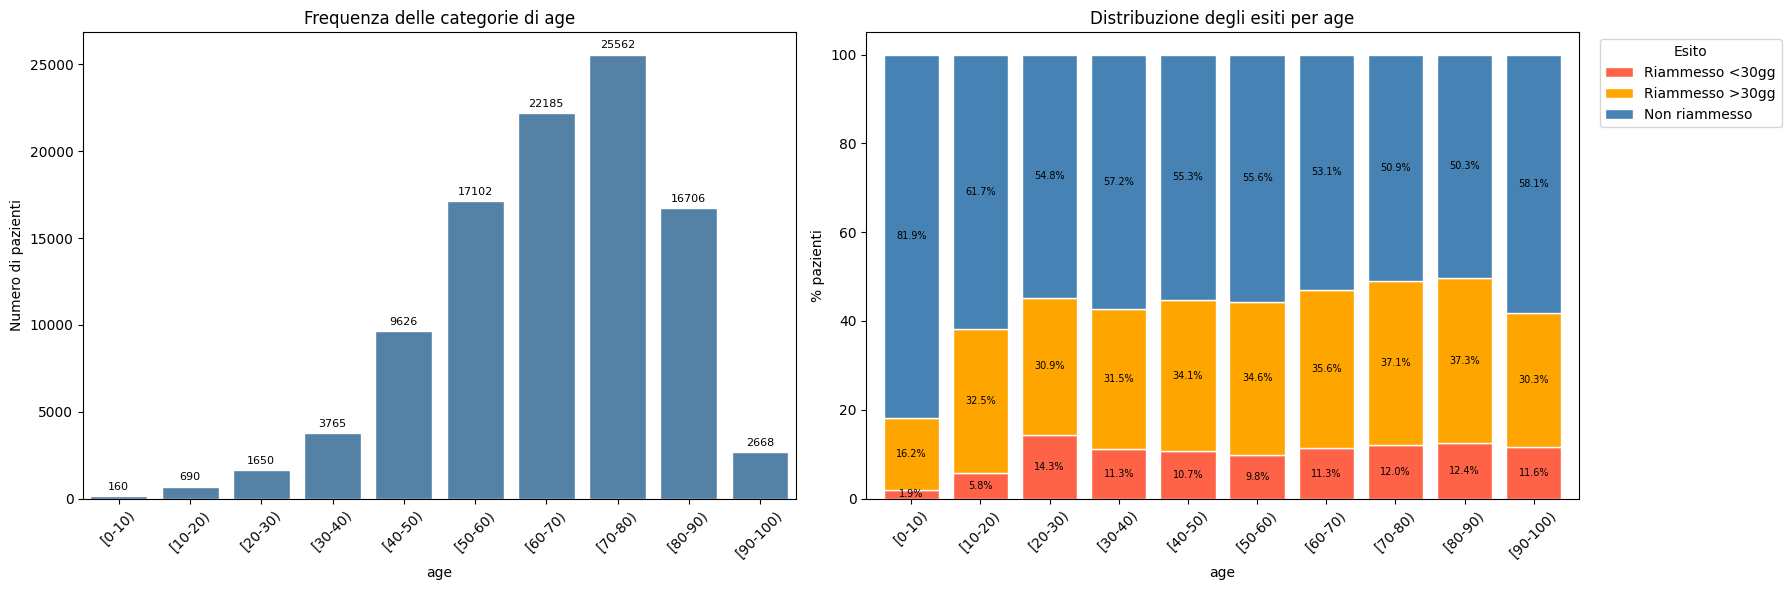

In [ ]:
#@title Grafico analisi: age
plot_categorical_variable_analysis(df, "age", y, top_n=20)

**Commento sul grafico di `age`:**

La variabile age viene mantenuta perché presenta una distribuzione sufficientemente ampia tra diverse fasce d’età e mostra differenze nella distribuzione degli esiti. In particolare, si osserva che la quota di pazienti non riammessi tende a variare tra le classi di età, con percentuali diverse tra pazienti giovani, adulti e anziani. Dal punto di vista clinico, l’età rappresenta una variabile rilevante, poiché può essere associata alla fragilità del paziente e al rischio di riammissione. Per questi motivi, age può fornire un contributo predittivo utile e viene quindi mantenuta nel dataset.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


/tmp/ipykernel_5374/3845496504.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col: df[col].astype(object).fillna("Missing").astype(str),


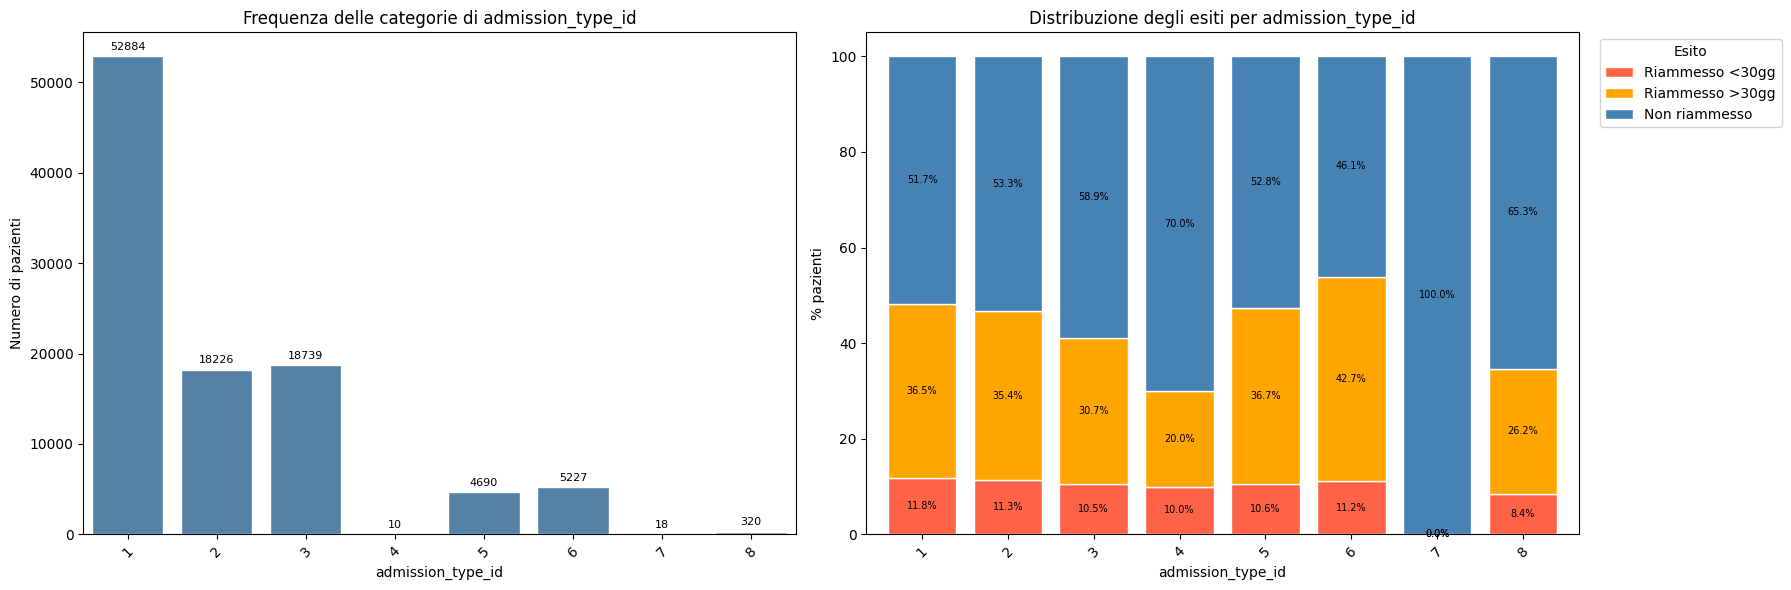

In [ ]:
#@title Grafico analisi: admission_type_id
plot_categorical_variable_analysis(df, "admission_type_id", y, top_n=20)

**Commento sul grafico di `admission_type_id`:**

La variabile admission_type_id viene mantenuta perché rappresenta la tipologia di ammissione del paziente e possiede un significato clinico-organizzativo rilevante. Dal grafico si osserva che alcune categorie sono ben rappresentate e che la distribuzione degli esiti varia tra i diversi tipi di ammissione, suggerendo una possibile relazione con il rischio di riammissione. Le categorie con numerosità molto ridotta, come 4 e 7, possono essere eventualmente accorpate o gestite separatamente per evitare instabilità. Per questi motivi, la variabile viene considerata informativa e mantenuta nel dataset.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


/tmp/ipykernel_5374/3845496504.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col: df[col].astype(object).fillna("Missing").astype(str),


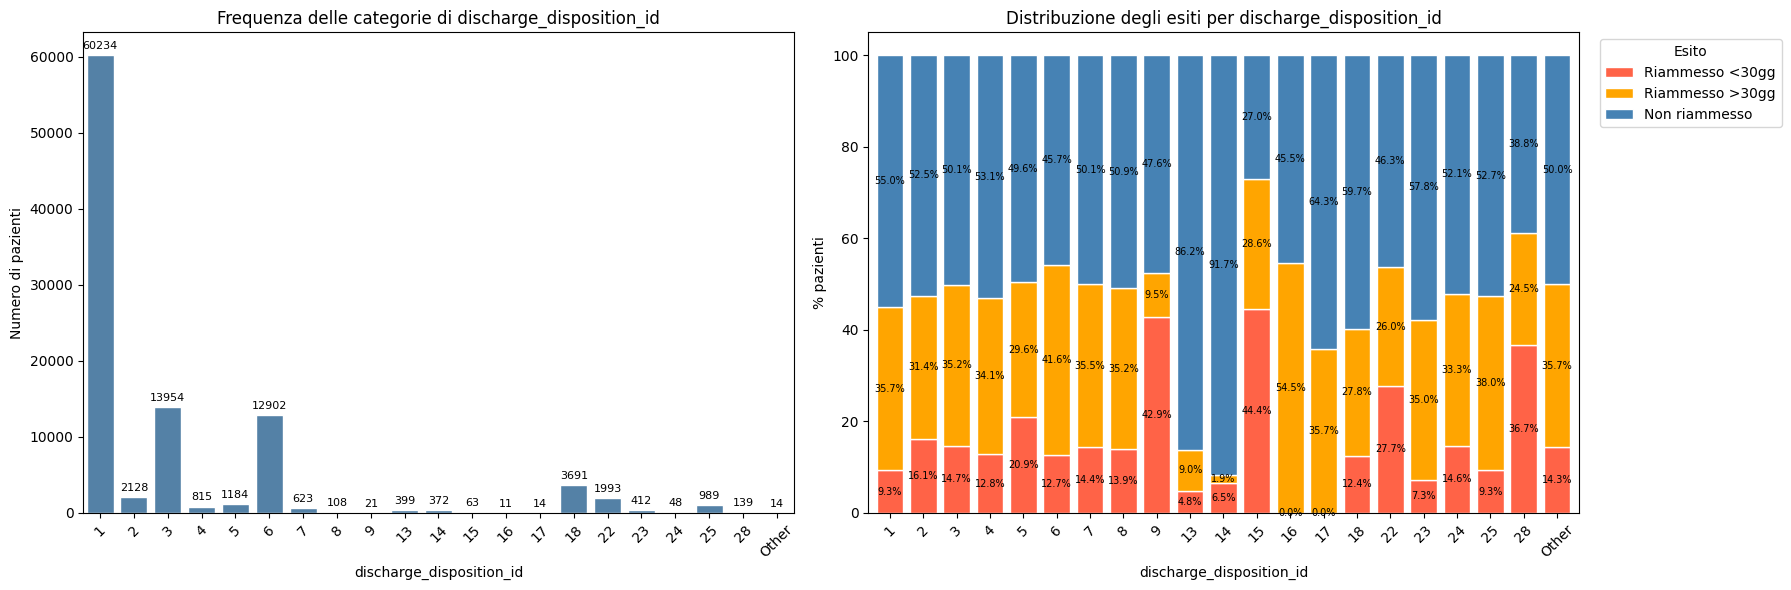

In [ ]:
#@title Grafico analisi: discharge_disposition_id
plot_categorical_variable_analysis(df, "discharge_disposition_id", y, top_n=20)

**Commento sul grafico di `discharge_disposition_id`:**

La variabile discharge_disposition_id viene mantenuta perché rappresenta la destinazione del paziente dopo la dimissione e possiede un significato clinico-organizzativo rilevante. Dal grafico si osserva che alcune categorie hanno numerosità significativa e che la distribuzione degli esiti varia sensibilmente tra le diverse modalità di dimissione. Questo suggerisce una possibile relazione tra il tipo di dimissione e il rischio di riammissione. Le categorie con numerosità molto ridotta possono essere eventualmente accorpate o gestite separatamente per evitare instabilità, ma la variabile nel complesso risulta informativa e viene quindi mantenuta nel dataset.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


/tmp/ipykernel_5374/3845496504.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col: df[col].astype(object).fillna("Missing").astype(str),


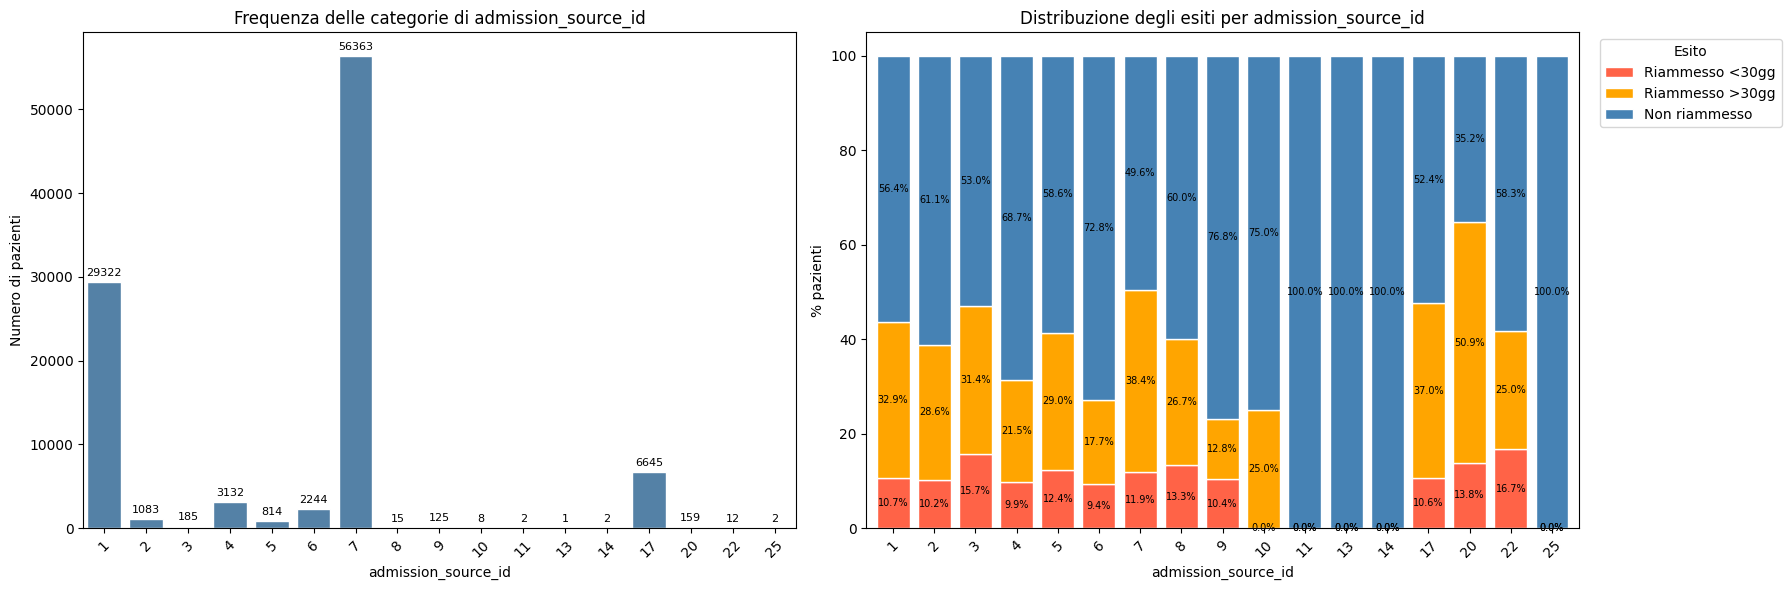

In [ ]:
#@title Grafico analisi: admission_source_id
plot_categorical_variable_analysis(df, "admission_source_id", y, top_n=20)

**Commento sul grafico di `admission_source_id`:**

La variabile admission_source_id viene mantenuta perché rappresenta la provenienza del paziente al momento dell’ammissione e possiede un significato clinico-organizzativo rilevante. Dal grafico si osserva che alcune categorie hanno numerosità significativa e che la distribuzione degli esiti varia tra le diverse fonti di ammissione. Questo suggerisce una possibile relazione tra il contesto di ingresso del paziente e il rischio di riammissione. Le categorie con numerosità molto ridotta possono essere eventualmente accorpate o trattate separatamente, ma nel complesso la variabile risulta informativa e viene quindi mantenuta nel dataset.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


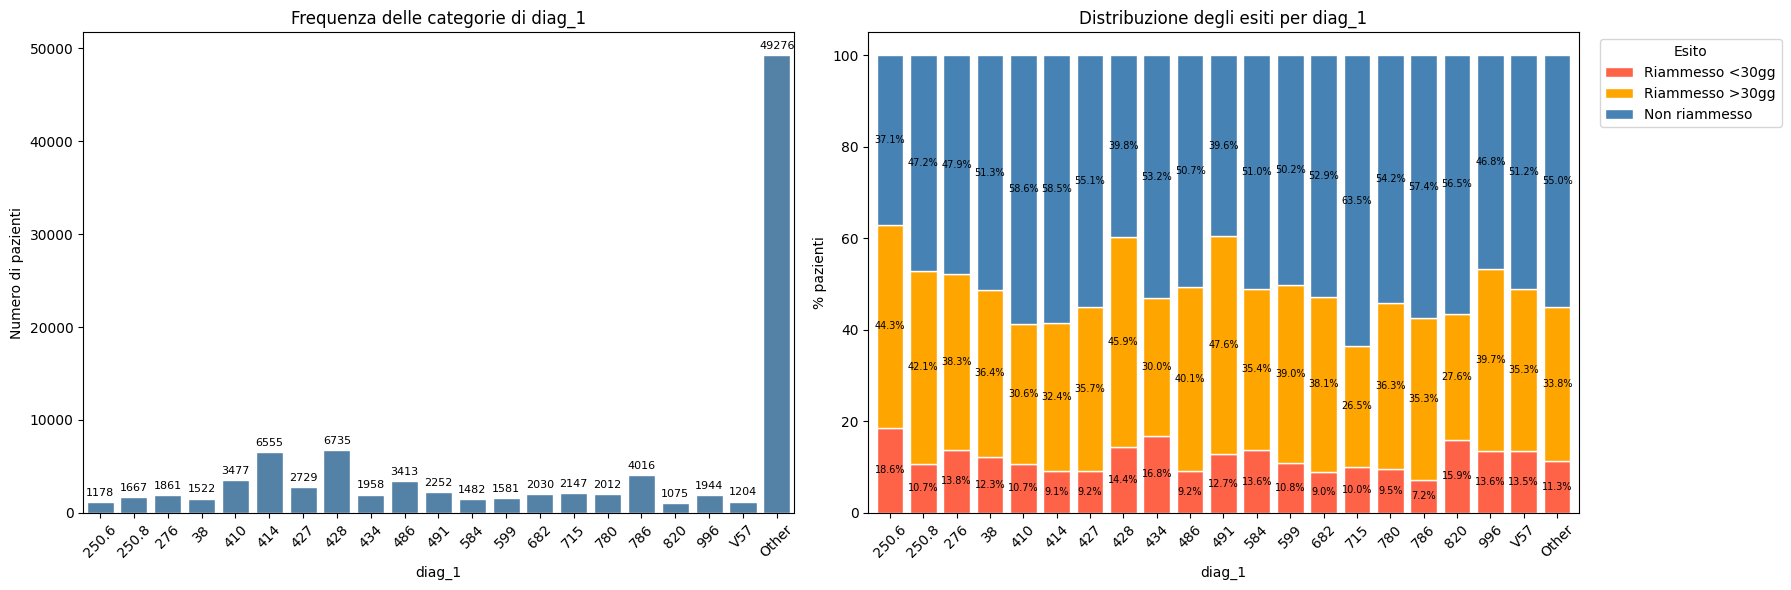

In [ ]:
#@title Grafico analisi: diag_1
plot_categorical_variable_analysis(df, "diag_1", y, top_n=20)

**Commento sul grafico di `diag_1`:**

La variabile `diag_1` viene mantenuta perché rappresenta la diagnosi principale del paziente e mostra una relazione evidente con la variabile target. Dal grafico della distribuzione degli esiti si osserva che le percentuali di riammissione e non riammissione variano tra le diverse categorie diagnostiche, suggerendo che la diagnosi principale possa contribuire alla capacità predittiva del modello. Nonostante la presenza di una categoria “Other” molto numerosa, diverse classi diagnostiche mantengono una numerosità sufficiente e presentano distribuzioni degli esiti differenti, rendendo la variabile informativa e clinicamente interpretabile.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


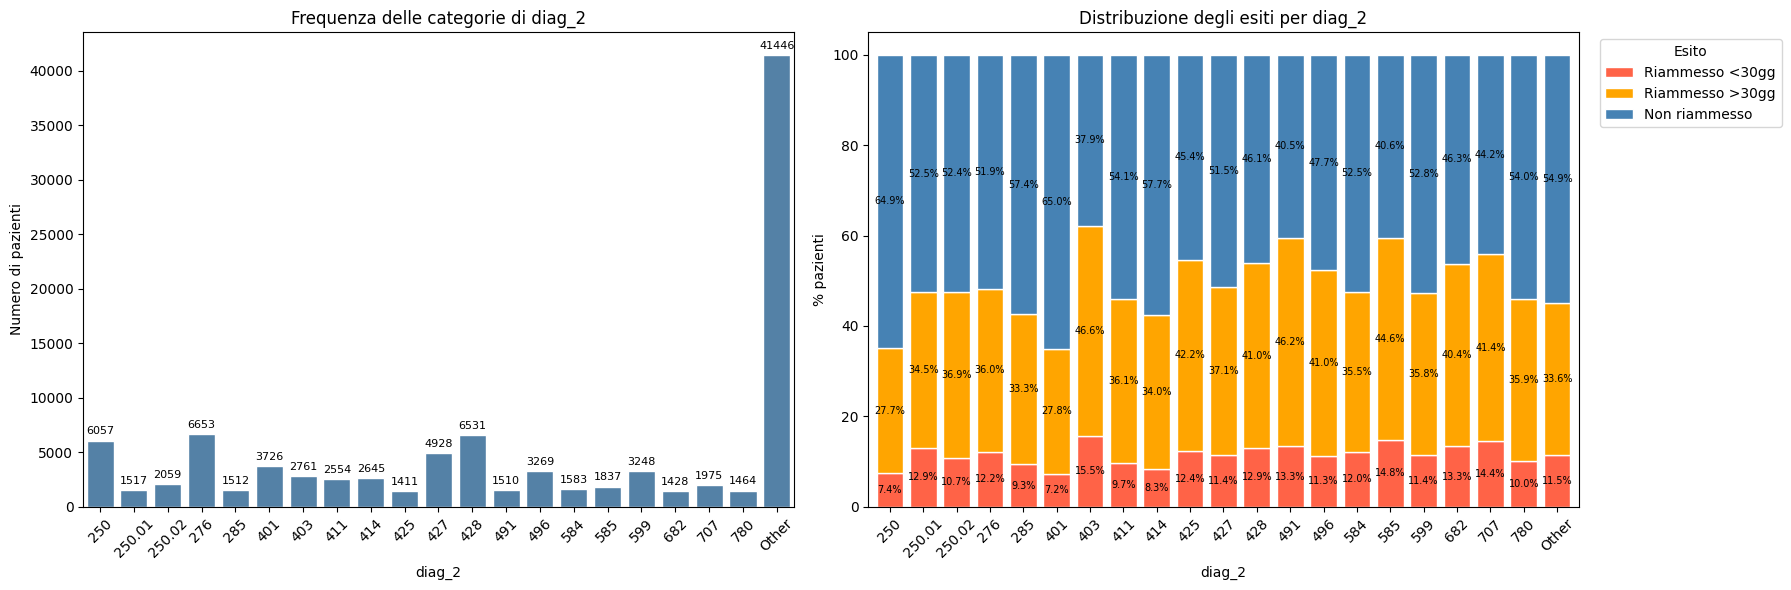

In [ ]:
#@title Grafico analisi: diag_2
plot_categorical_variable_analysis(df, "diag_2", y, top_n=20)

**Commento sul grafico di `diag_2`:**

Per motivazioni analoghe a `diag_1` decidiamo di mantenere anche la variabile `diag_2`

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


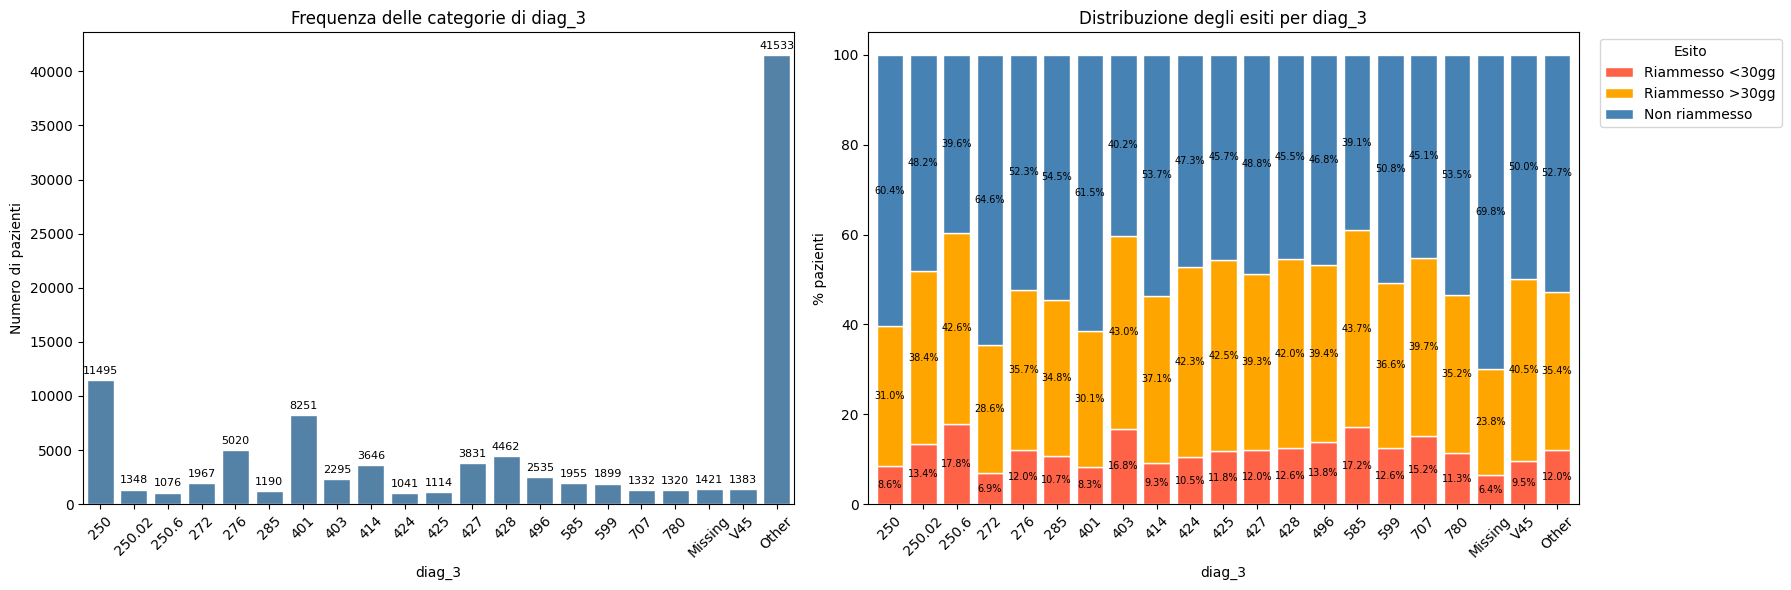

In [ ]:
#@title Grafico analisi: diag_3
plot_categorical_variable_analysis(df, "diag_3", y, top_n=20)

**Commento sul grafico di `diag_3`:**

Per motivazioni analoghe a `diag_1` e `diag_2` decidiamo di mantenere anche la variabile `diag_3`

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


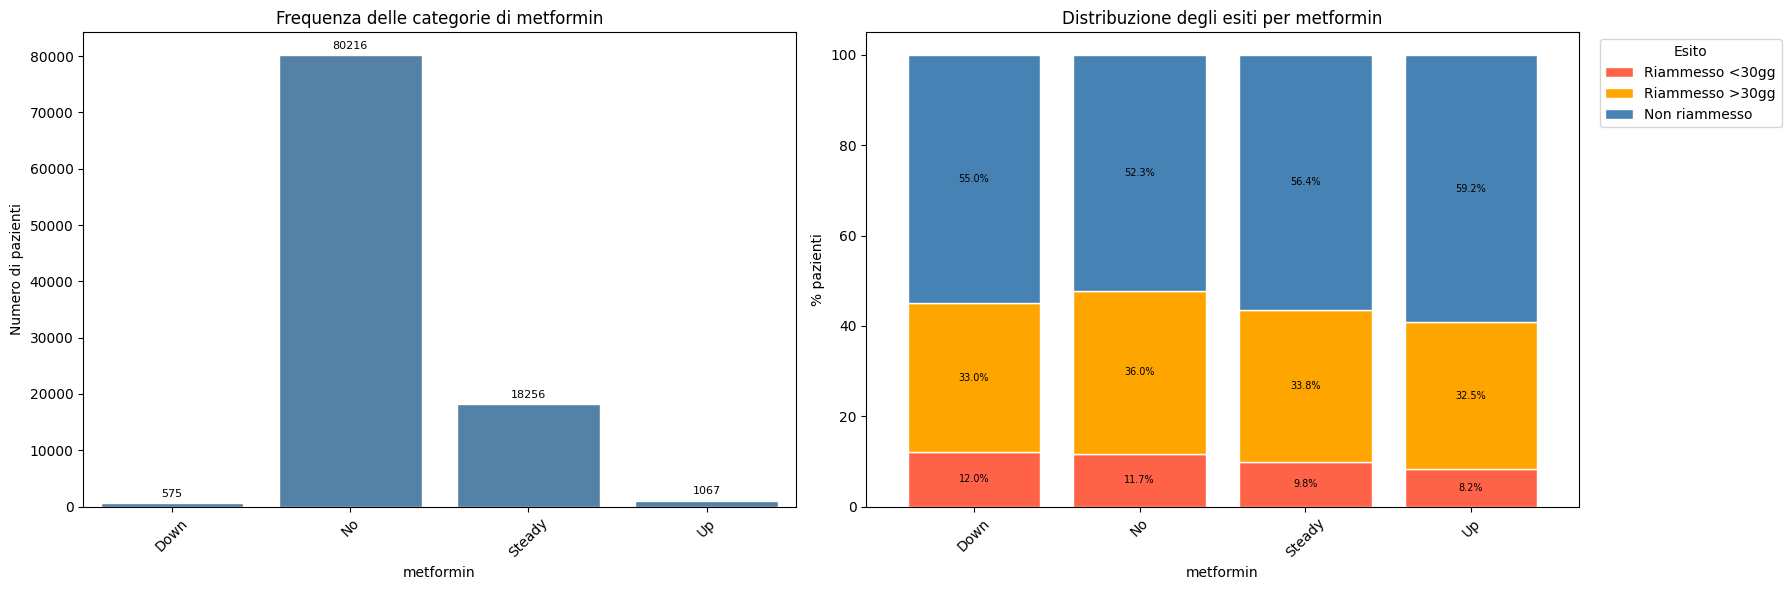

In [ ]:
#@title Grafico analisi: metformin
plot_categorical_variable_analysis(df, "metformin", y, top_n=20)

Proviamo ad accorpare "Down", "Steady" e "Up" visti i pochi valori, per poter differenziare il caso in cui il paziente prende o meno il farmaco metformin

/tmp/ipykernel_5374/3845496504.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col: df[col].astype(object).fillna("Missing").astype(str),


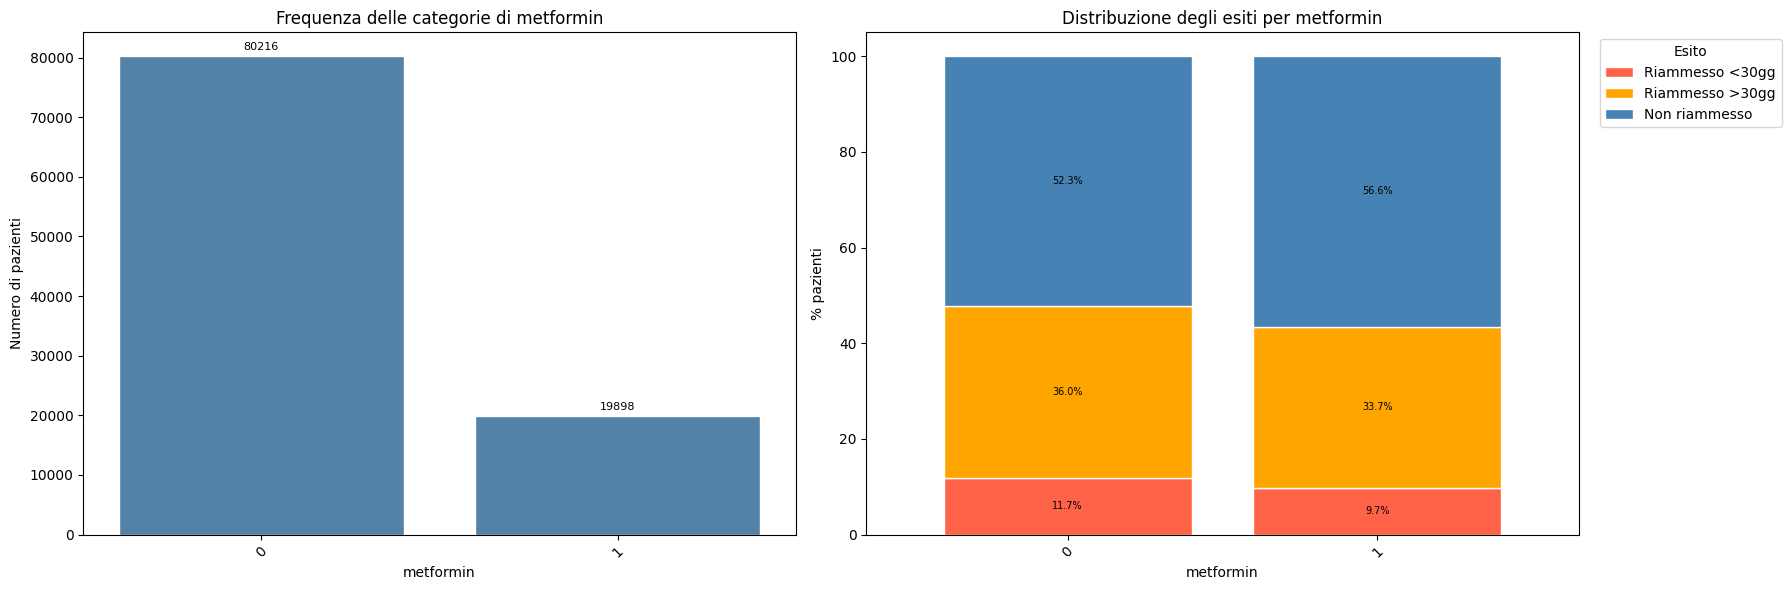

In [ ]:
df["metformin"] = (df["metformin"] != "No").astype(int)
plot_categorical_variable_analysis(df, "metformin", y, top_n=20)

**Commento sul grafico di `metformin`:**

La variabile metformin viene mantenuta perché, pur essendo sbilanciata verso la categoria “No”, presenta una numerosità significativa nella categoria “Steady” e valori non trascurabili anche nelle categorie “Up” e “Down”. Inoltre, la distribuzione degli esiti mostra alcune differenze tra le categorie, in particolare nella quota di pazienti non riammessi e riammessi entro 30 giorni. Dal punto di vista clinico, l’assunzione o la variazione del dosaggio di metformina può rappresentare un’informazione utile sul trattamento del paziente diabetico. Per questi motivi, la variabile può contribuire alla capacità predittiva del modello e viene quindi mantenuta.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


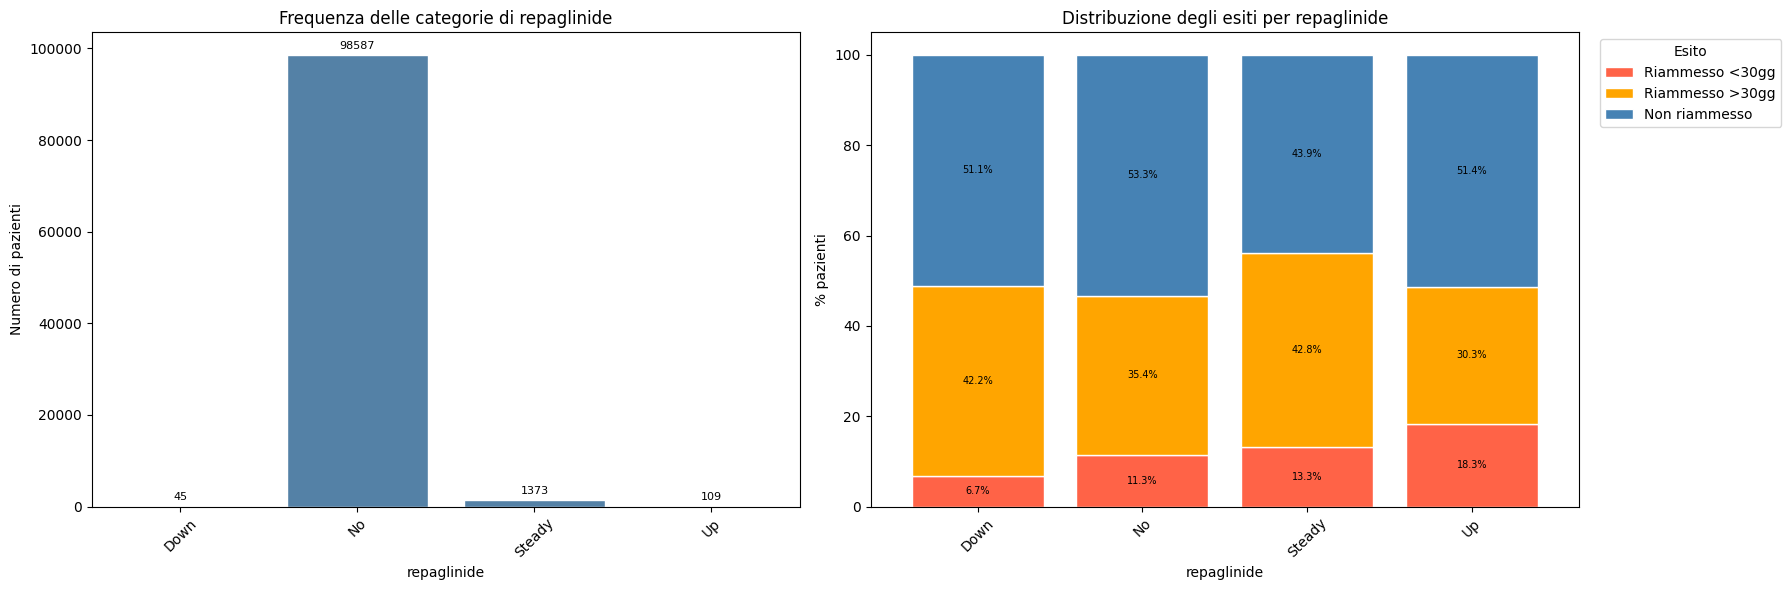

In [ ]:
#@title Grafico analisi: repaglinide
plot_categorical_variable_analysis(df, "repaglinide", y, top_n=20)

**Commento sul grafico di `repaglinide`:**

La variabile repaglinide non viene mantenuta perché presenta una distribuzione fortemente sbilanciata verso la modalità No, che comprende la quasi totalità dei pazienti. Le altre modalità sono rappresentate da un numero molto ridotto di osservazioni, in particolare Up e Down, che contano rispettivamente poche decine o centinaia di casi rispetto alla dimensione complessiva del dataset.

Sebbene dal grafico si osservino alcune differenze nella distribuzione degli esiti tra le categorie, tali differenze sono calcolate su numerosità molto basse e quindi possono risultare poco stabili e non generalizzabili. Mantenere la variabile tramite one-hot encoding produrrebbe colonne estremamente sparse, aumentando la complessità del modello e il rischio di overfitting su pattern legati a pochi pazienti.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["repaglinide"], inplace=True)

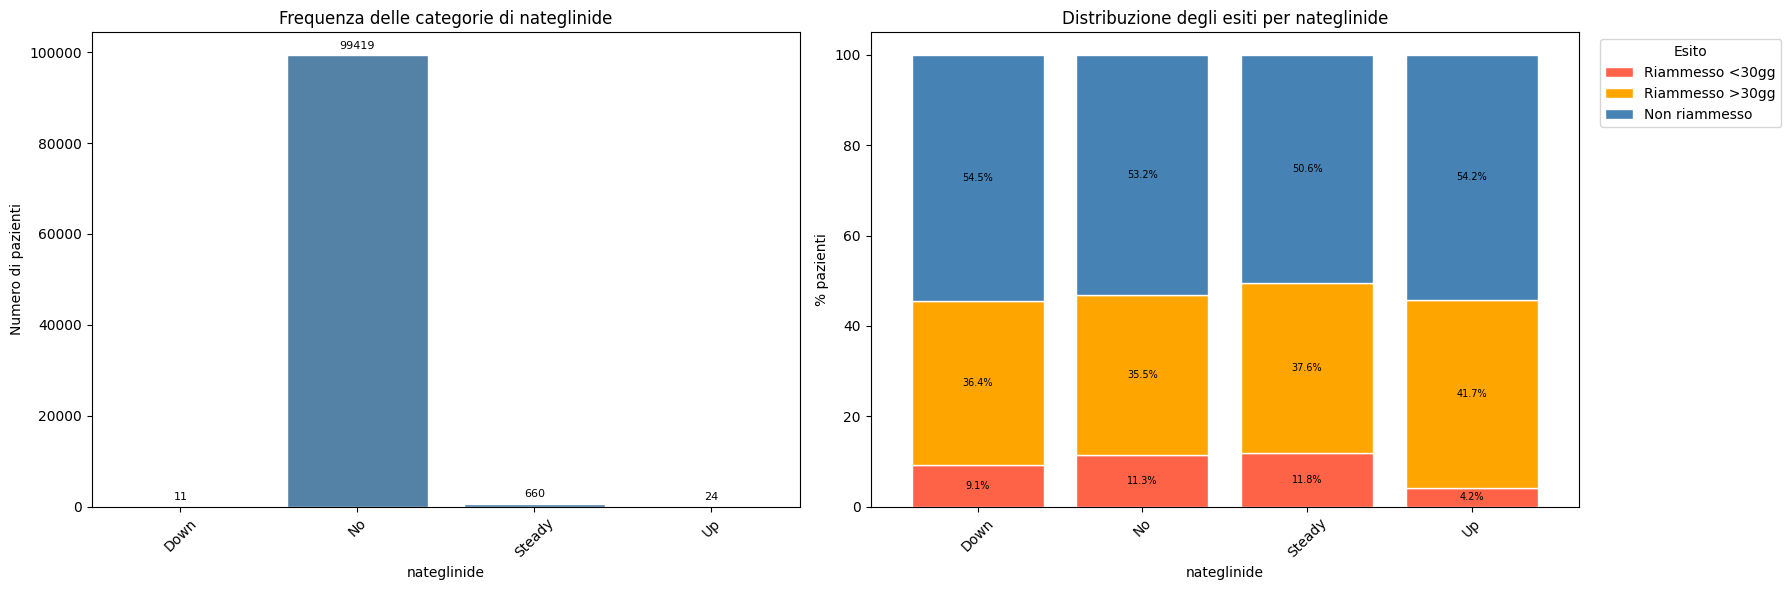

In [ ]:
#@title Grafico analisi: nateglinide
plot_categorical_variable_analysis(df, "nateglinide", y, top_n=20)

**Commento sul grafico di `nateglinide`:**

La variabile nateglinide non viene mantenuta perché presenta una distribuzione fortemente sbilanciata verso la categoria “No”. Sebbene la categoria “Steady” abbia una numerosità superiore rispetto ad altre variabili farmacologiche rare, la distribuzione degli esiti risulta molto simile a quella generale del dataset, suggerendo un contributo predittivo limitato. Inoltre, le categorie “Up” e “Down” hanno numerosità molto ridotte, rendendo poco affidabili le percentuali osservate. Per questi motivi, la variabile rischia di aggiungere complessità senza apportare un’informazione predittiva stabile e significativa.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere

In [ ]:
df.drop(columns=["nateglinide"], inplace=True)

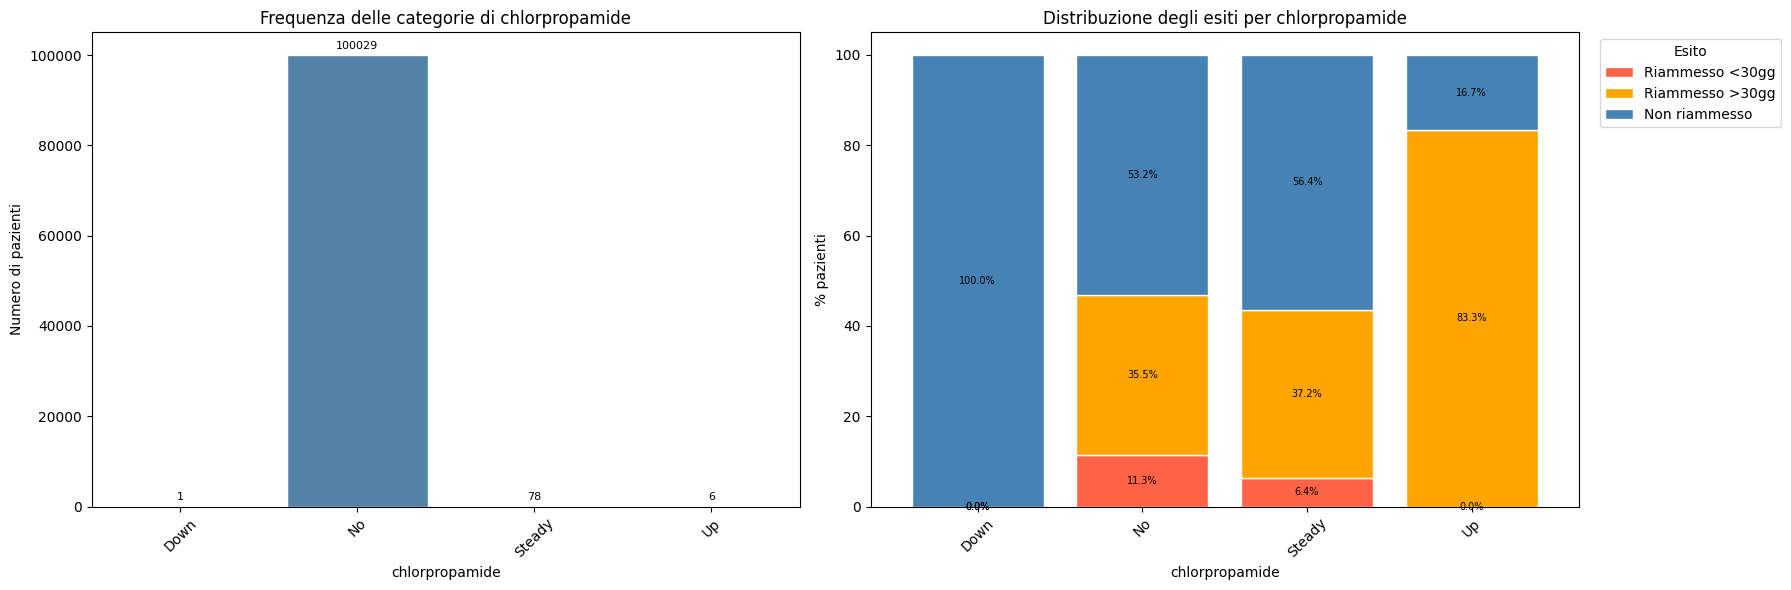

In [ ]:
#@title Grafico analisi: chlorpropamide
plot_categorical_variable_analysis(df, "chlorpropamide", y, top_n=20)

**Commento sul grafico di `chlorpropamide`:**

La variabile chlorpropamide non viene mantenuta perché presenta una distribuzione estremamente sbilanciata: la quasi totalità dei pazienti appartiene alla categoria “No”, mentre le categorie “Down”, “Steady” e “Up” hanno numerosità molto basse. Di conseguenza, le differenze osservate nella distribuzione degli esiti per queste categorie non sono affidabili, perché calcolate su pochi casi. La variabile rischia quindi di introdurre rumore e overfitting nel modello, senza fornire un contributo predittivo stabile. Per questo motivo si ritiene opportuno eliminarla dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["chlorpropamide"], inplace=True)

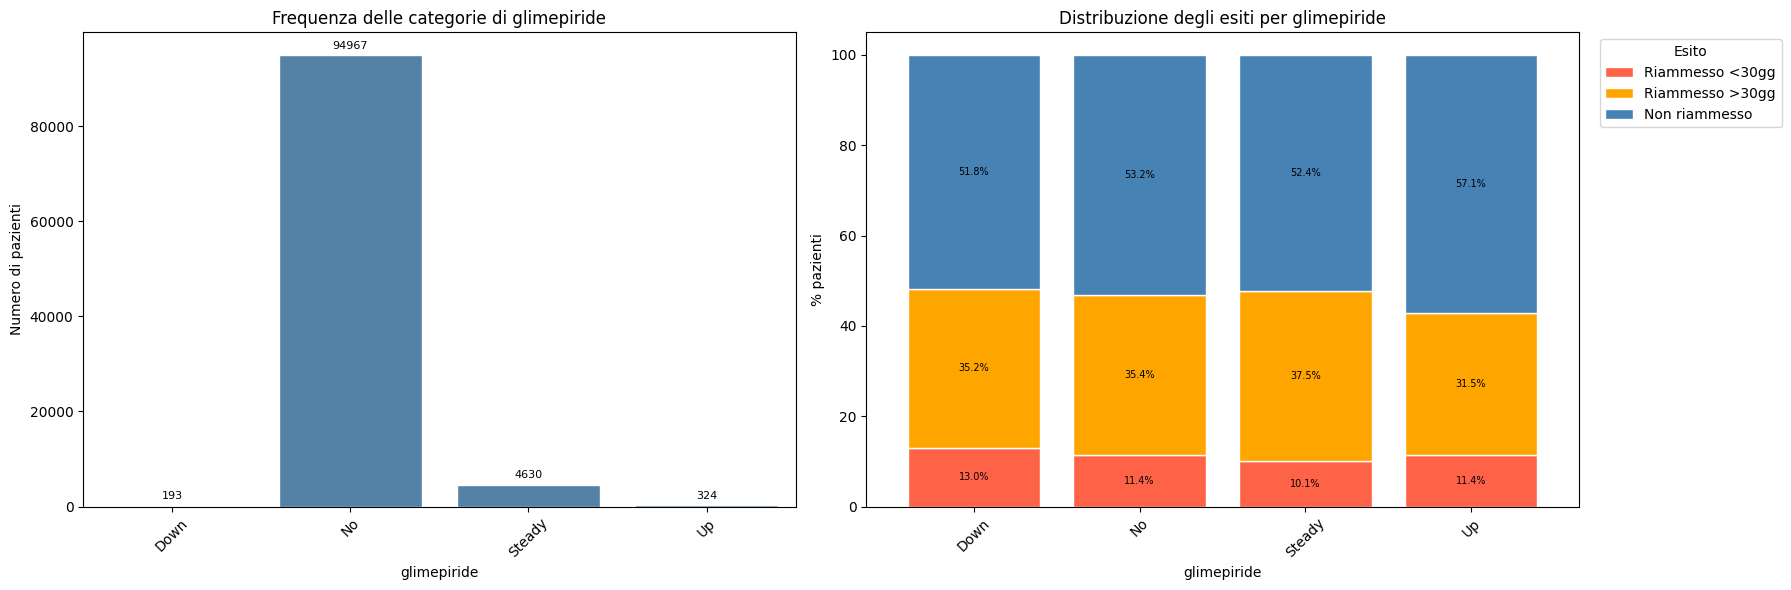

In [ ]:
#@title Grafico analisi: glimepiride
plot_categorical_variable_analysis(df, "glimepiride", y, top_n=20)

Proviamo ad accorpare "Down", "Steady" e "Up" visti i pochi valori, per poter differenziare il caso in cui il paziente prende o meno il farmaco glimepiride

/tmp/ipykernel_5374/3845496504.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col: df[col].astype(object).fillna("Missing").astype(str),


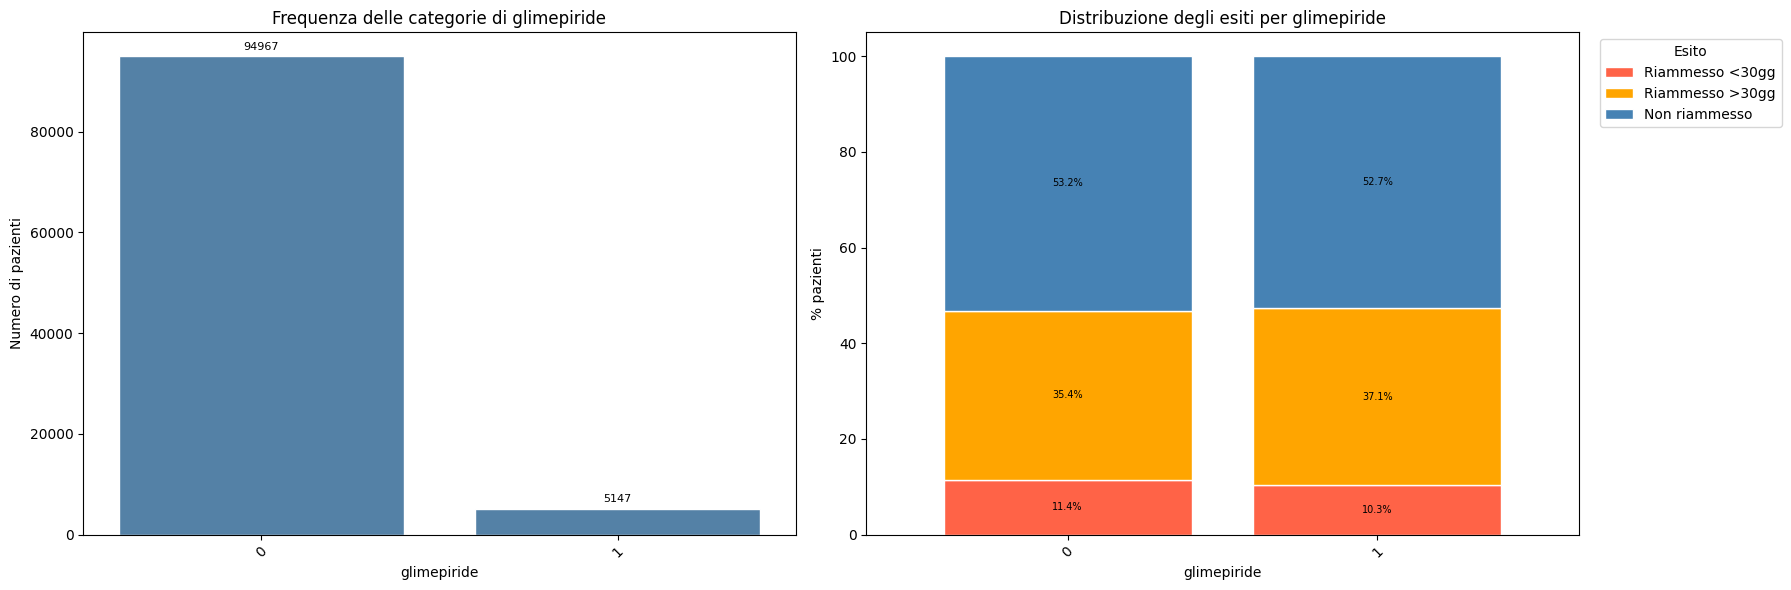

In [ ]:
df["glimepiride"] = (df["glimepiride"] != "No").astype(int)
plot_categorical_variable_analysis(df, "glimepiride", y, top_n=20)

**Commento sul grafico di `glimepiride`:**

La variabile glimepiride non viene mantenuta perché, pur presentando alcune categorie diverse da “No”, risulta fortemente sbilanciata verso quest’ultima. Inoltre, la distribuzione degli esiti è molto simile tra le diverse categorie, con differenze percentuali contenute per riammissione entro 30 giorni, riammissione oltre 30 giorni e non riammissione. Questo suggerisce una bassa capacità discriminante rispetto alla variabile target. Le categorie “Up” e “Down”, inoltre, hanno numerosità ridotte rispetto al totale, rendendo meno stabile l’informazione associata. Per questi motivi si ritiene opportuno eliminare la variabile dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["glimepiride"], inplace=True)

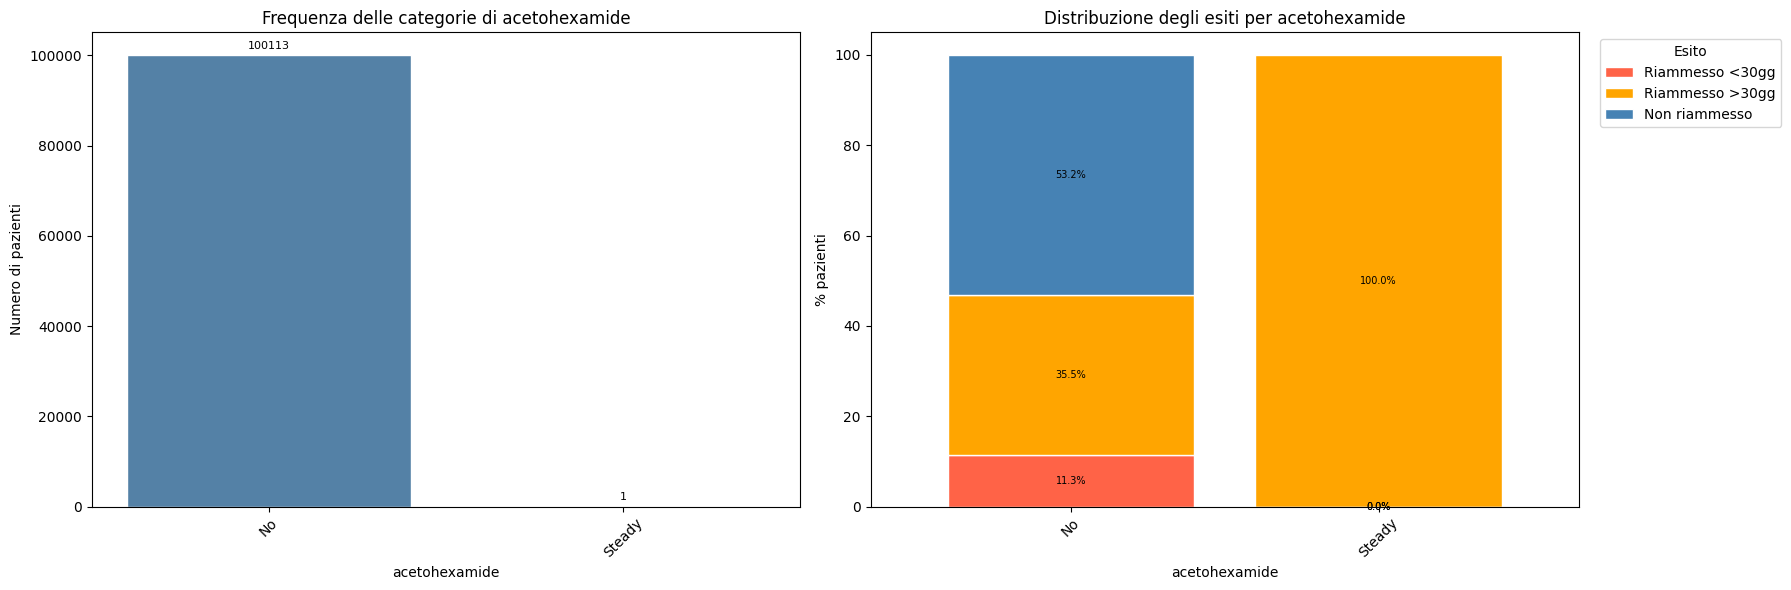

In [ ]:
#@title Grafico analisi: acetohexamide
plot_categorical_variable_analysis(df, "acetohexamide", y, top_n=20)

**Commento sul grafico di `acetohexamide`:**

La variabile acetohexamide non viene mantenuta perché presenta varianza quasi nulla: la quasi totalità dei pazienti appartiene alla categoria “No”, mentre la categoria “Steady” contiene un solo caso. Di conseguenza, la diversa distribuzione degli esiti osservata per “Steady” non è statisticamente significativa né generalizzabile. L’inclusione della variabile rischierebbe di introdurre rumore o overfitting nel modello, senza apportare un reale contributo predittivo. Per questo motivo si ritiene opportuno eliminarla dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["acetohexamide"], inplace=True)

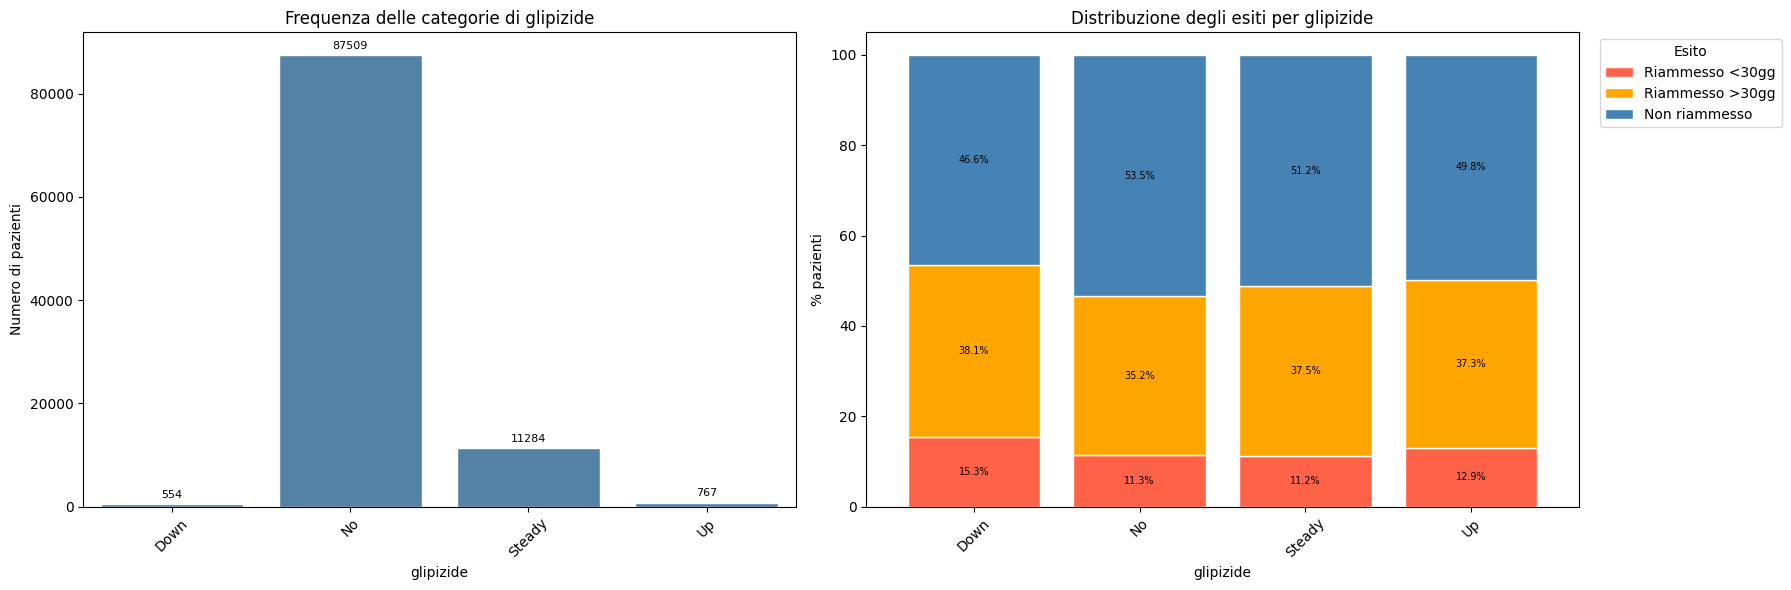

In [ ]:
#@title Grafico analisi: glipizide
plot_categorical_variable_analysis(df, "glipizide", y, top_n=20)

Proviamo ad accorpare "Down", "Steady" e "Up" visti i pochi valori, per poter differenziare il caso in cui il paziente prende o meno il farmaco glipizide

/tmp/ipykernel_5374/3845496504.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col: df[col].astype(object).fillna("Missing").astype(str),


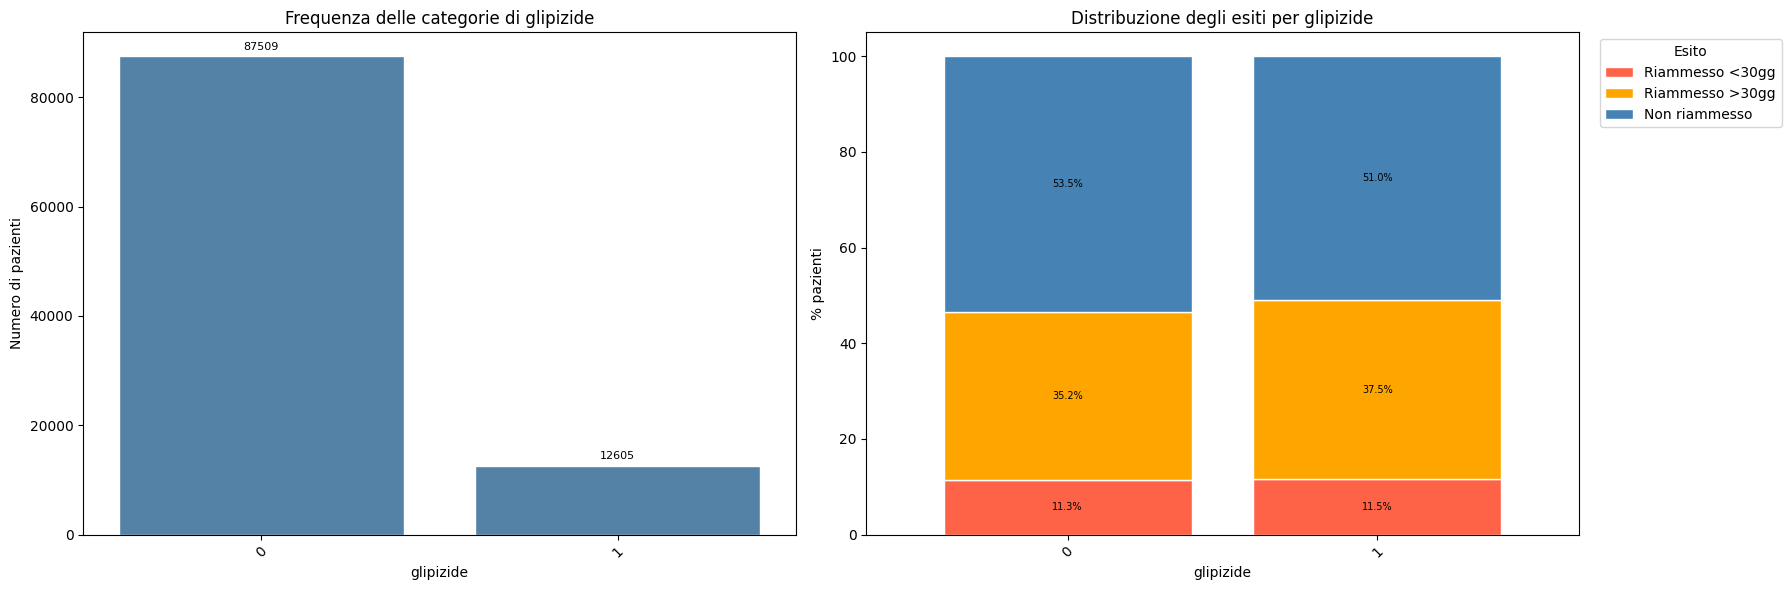

In [ ]:
df["glipizide"] = (df["glipizide"] != "No").astype(int)
plot_categorical_variable_analysis(df, "glipizide", y, top_n=20)

**Commento sul grafico di `glipizide`:**

La variabile glipizide non viene mantenuta perché presenta una distribuzione fortemente sbilanciata verso la categoria “No”. Sebbene la categoria “Steady” abbia una numerosità discreta, la distribuzione degli esiti risulta abbastanza simile a quella della categoria principale, suggerendo una limitata capacità discriminante rispetto alla variabile target. Inoltre, le categorie “Up” e “Down” hanno numerosità molto più ridotte rispetto al totale, rendendo meno stabile l’informazione associata. Per questi motivi, la variabile rischia di aggiungere complessità al modello senza apportare un contributo predittivo sufficientemente significativo.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["glipizide"], inplace=True)

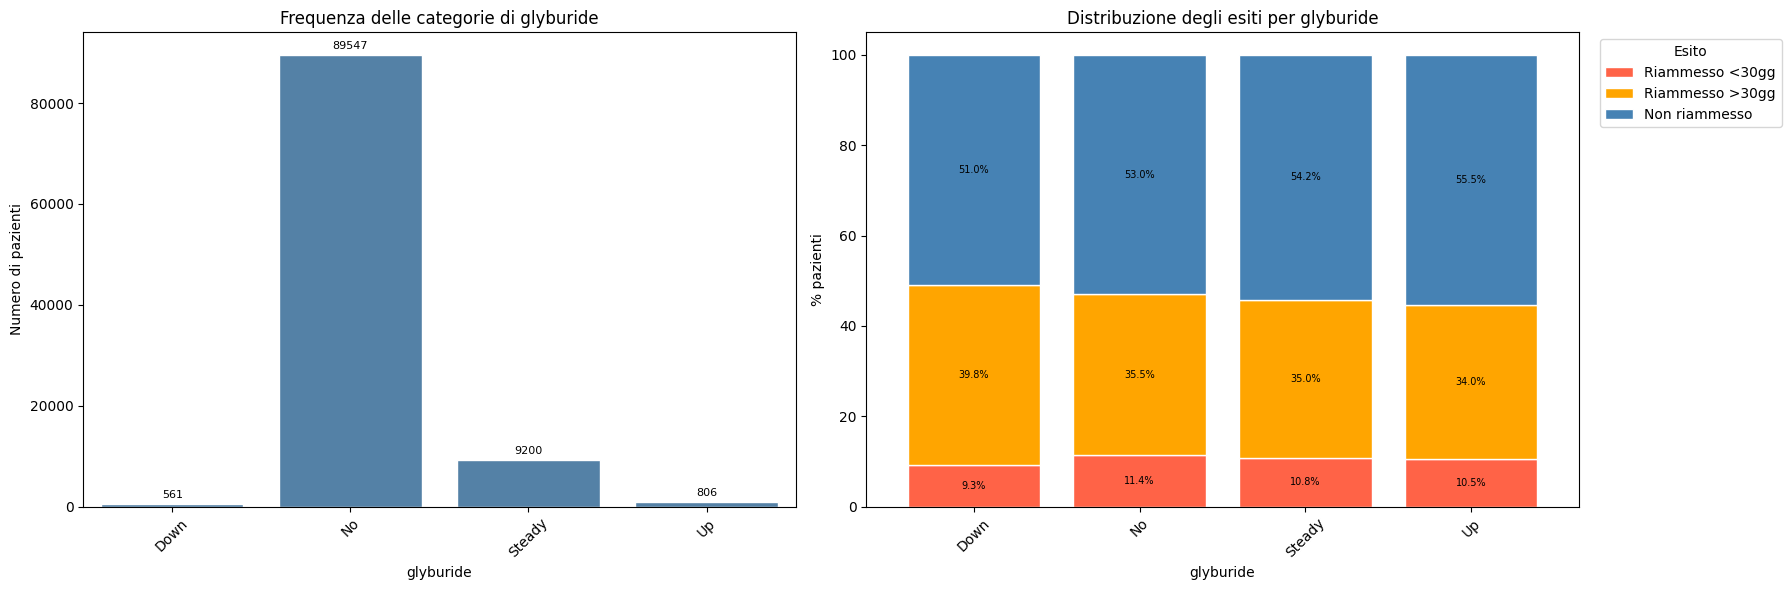

In [ ]:
#@title Grafico analisi: glyburide
plot_categorical_variable_analysis(df, "glyburide", y, top_n=20)

Proviamo ad accorpare "Down", "Steady" e "Up" visti i pochi valori, per poter differenziare il caso in cui il paziente prende o meno il farmaco glyburide

/tmp/ipykernel_5374/3845496504.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col: df[col].astype(object).fillna("Missing").astype(str),


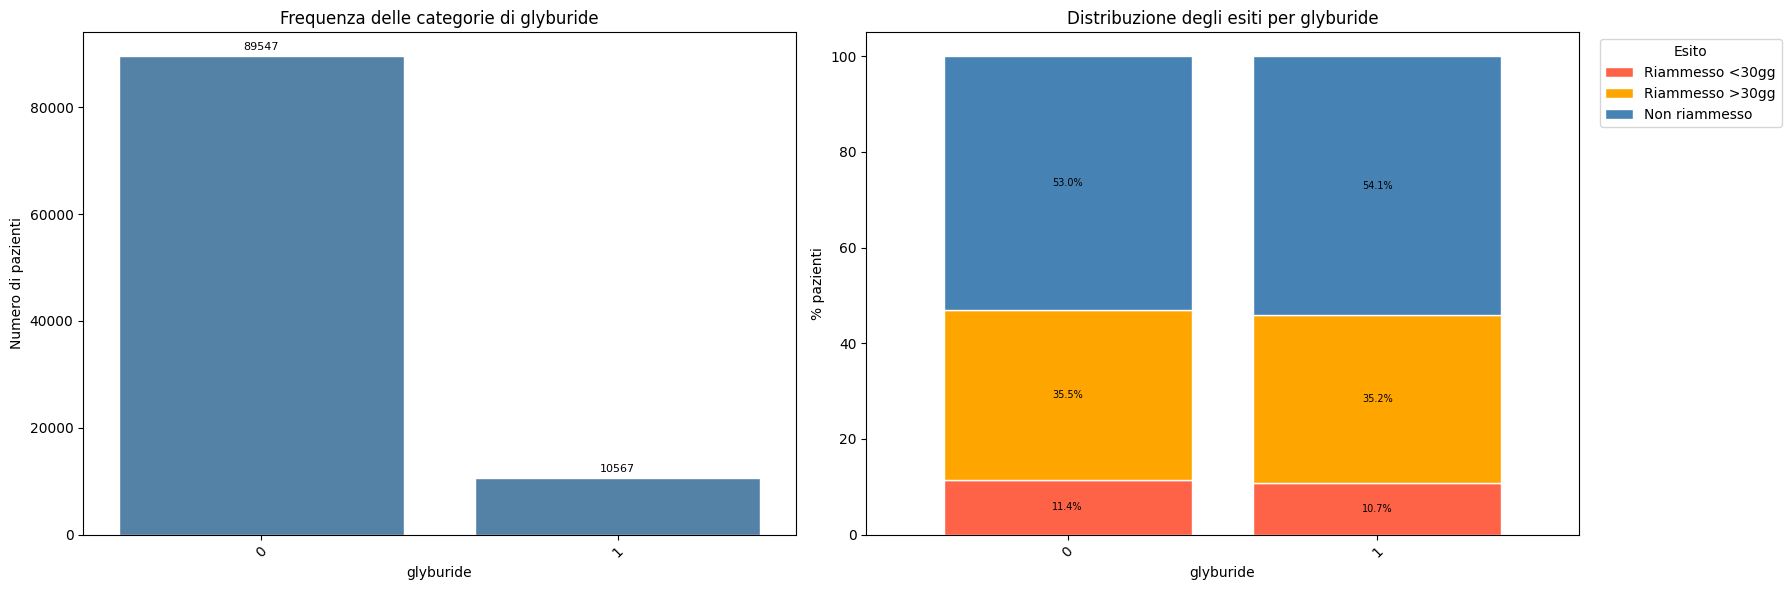

In [ ]:
df["glyburide"] = (df["glyburide"] != "No").astype(int)
plot_categorical_variable_analysis(df, "glyburide", y, top_n=20)

**Commento sul grafico di `glyburide`:**

La variabile glyburide non viene mantenuta perché, pur presentando alcune categorie con numerosità non trascurabile, risulta comunque fortemente sbilanciata verso la categoria “No”. Inoltre, la distribuzione degli esiti è molto simile tra le diverse categorie, con differenze percentuali contenute nella quota di pazienti riammessi e non riammessi. Questo suggerisce una limitata capacità discriminante rispetto alla variabile target. Per questi motivi, la variabile rischia di aggiungere complessità al modello senza apportare un contributo predittivo sufficientemente significativo.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["glyburide"], inplace=True)

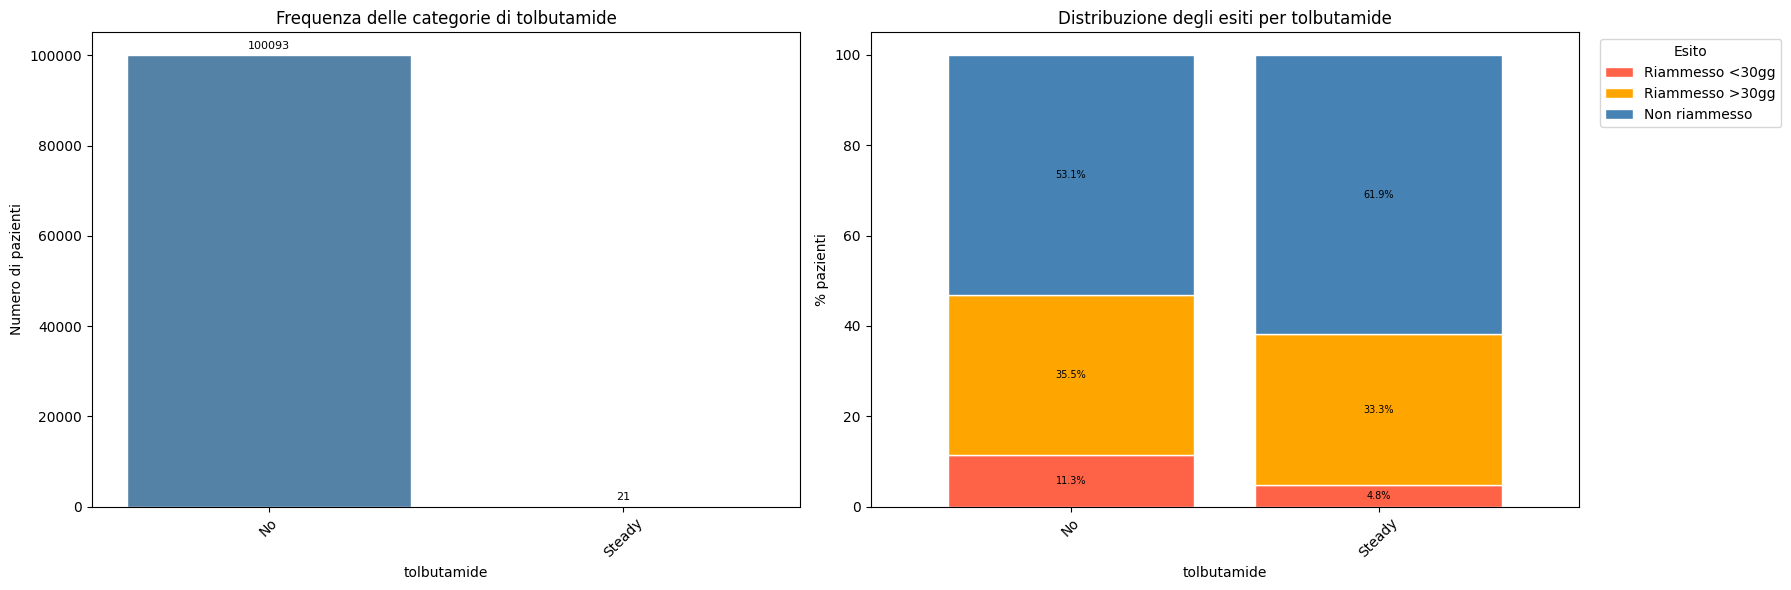

In [ ]:
#@title Grafico analisi: tolbutamide
plot_categorical_variable_analysis(df, "tolbutamide", y, top_n=20)

**Commento sul grafico di `tolbutamide`:**

La variabile tolbutamide non viene mantenuta perché presenta una distribuzione fortemente sbilanciata: la quasi totalità dei pazienti appartiene alla categoria “No”, mentre la categoria “Steady” contiene solo 22 osservazioni. Sebbene la distribuzione degli esiti sembri differire tra le due categorie, tale differenza è calcolata su un numero troppo ridotto di casi per essere considerata affidabile. L’inclusione della variabile potrebbe quindi introdurre rumore e favorire overfitting, senza apportare un contributo predittivo stabile al modello. Per questo motivo si ritiene opportuno eliminarla dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["tolbutamide"], inplace=True)

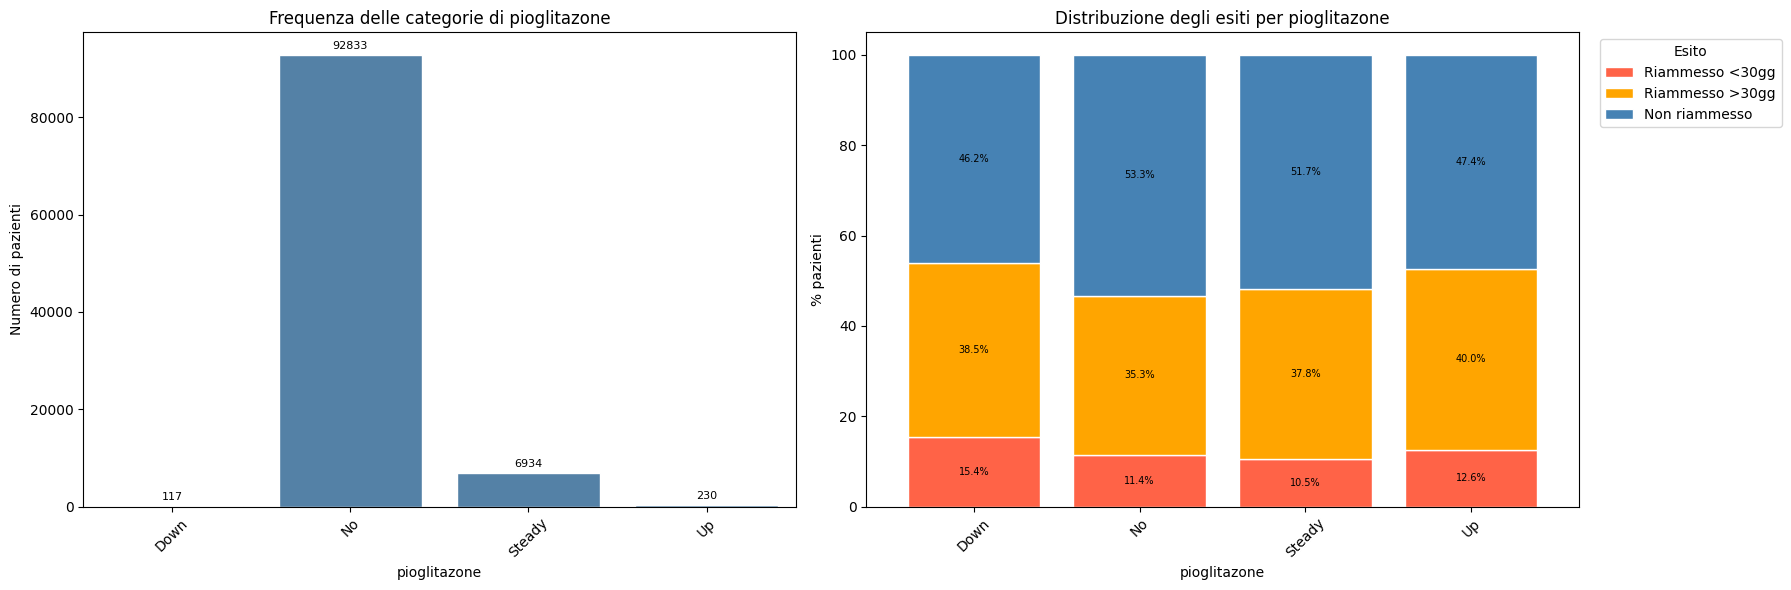

In [ ]:
#@title Grafico analisi: pioglitazone
plot_categorical_variable_analysis(df, "pioglitazone", y, top_n=20)

Proviamo ad accorpare "Down", "Steady" e "Up" visti i pochi valori, per poter differenziare il caso in cui il paziente prende o meno il farmaco pioglitazone

/tmp/ipykernel_5374/3845496504.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col: df[col].astype(object).fillna("Missing").astype(str),


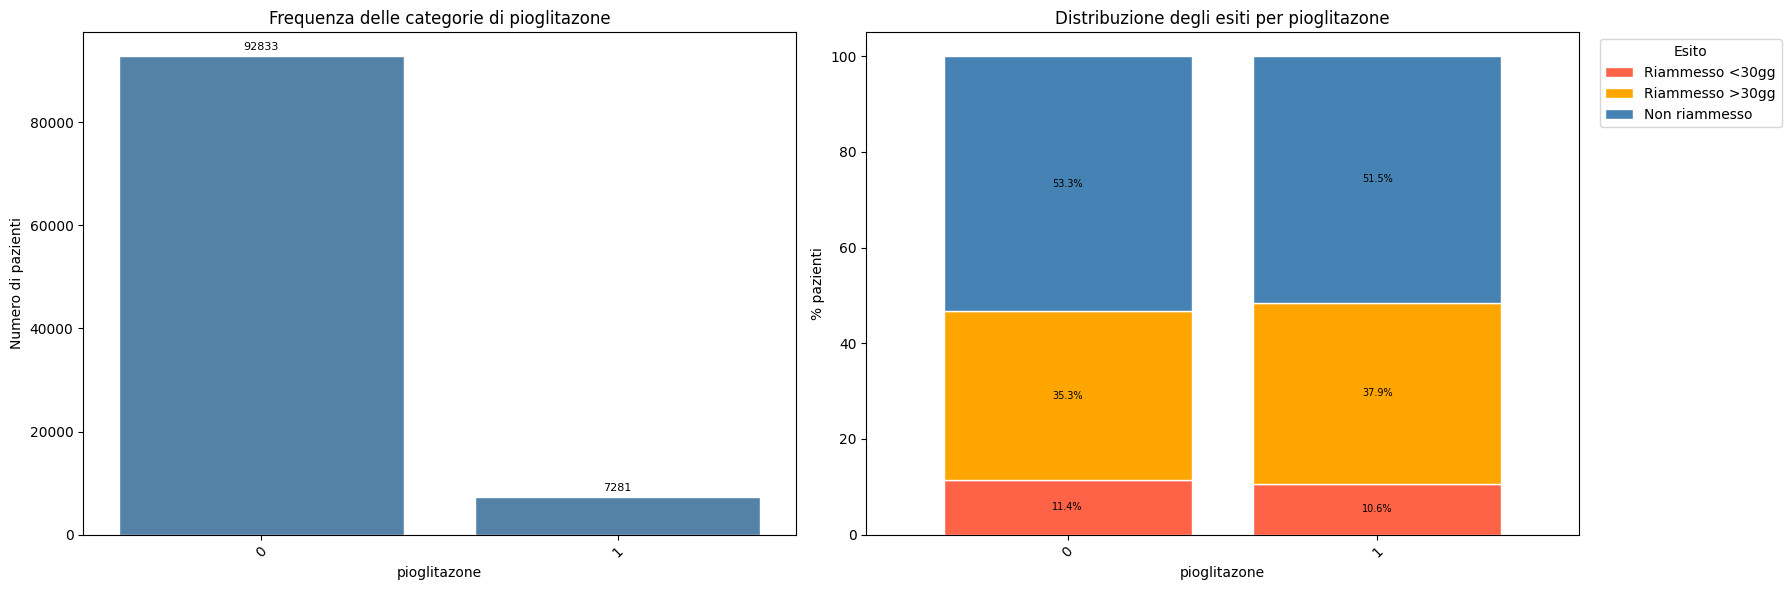

In [ ]:
df["pioglitazone"] = (df["pioglitazone"] != "No").astype(int)
plot_categorical_variable_analysis(df, "pioglitazone", y, top_n=20)

**Commento sul grafico di `pioglitazone`:**

La variabile pioglitazone non viene mantenuta perché presenta una distribuzione fortemente sbilanciata verso la categoria “No”. Sebbene la categoria “Steady” abbia una numerosità discreta, la distribuzione degli esiti risulta abbastanza simile a quella della categoria principale, suggerendo una limitata capacità discriminante rispetto alla variabile target. Inoltre, le categorie “Up” e “Down” hanno numerosità ridotte, rendendo meno stabile l’informazione associata. Per questi motivi, la variabile rischia di aggiungere complessità al modello senza fornire un contributo predittivo sufficientemente significativo.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["pioglitazone"], inplace=True)

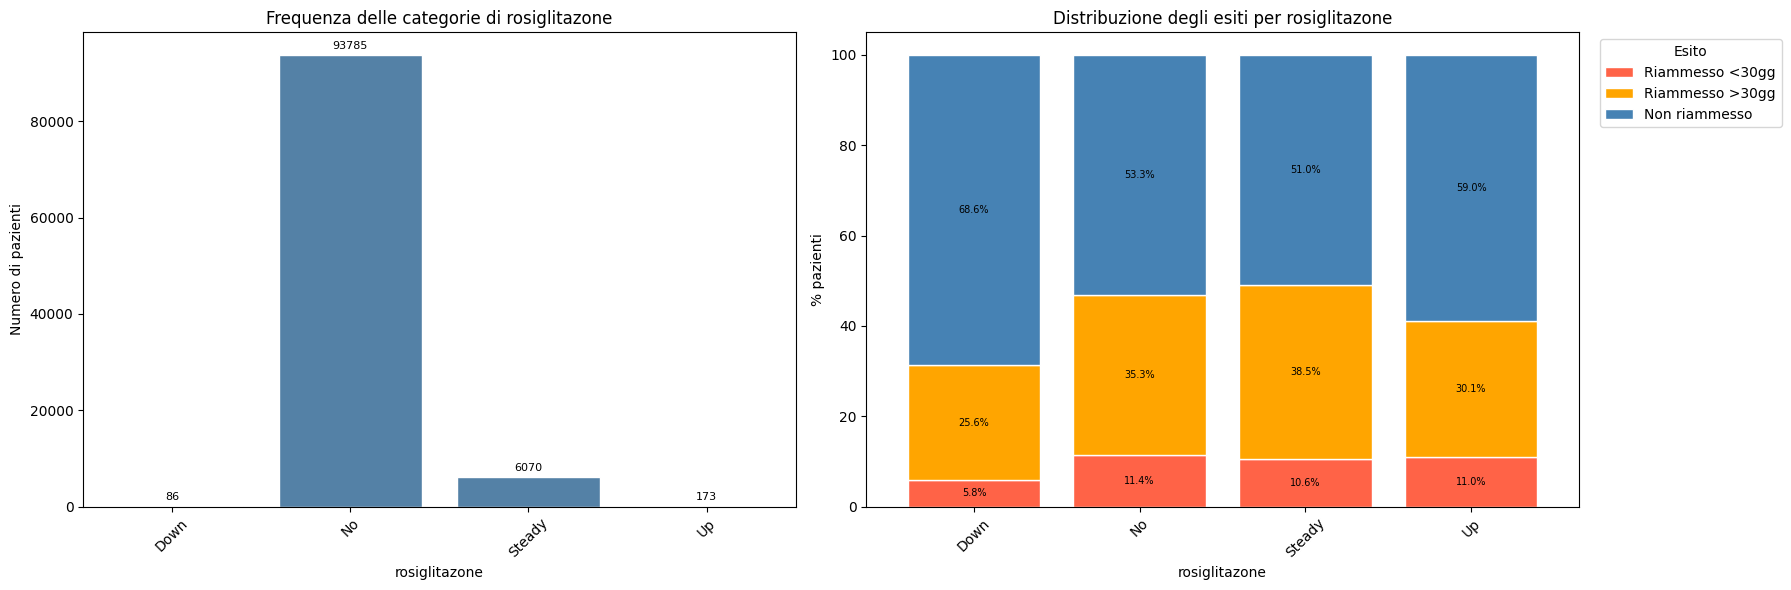

In [ ]:
#@title Grafico analisi: rosiglitazone
plot_categorical_variable_analysis(df, "rosiglitazone", y, top_n=20)

Proviamo ad accorpare "Down", "Steady" e "Up" visti i pochi valori, per poter differenziare il caso in cui il paziente prende o meno il farmaco rosiglitazone

/tmp/ipykernel_5374/3845496504.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col: df[col].astype(object).fillna("Missing").astype(str),


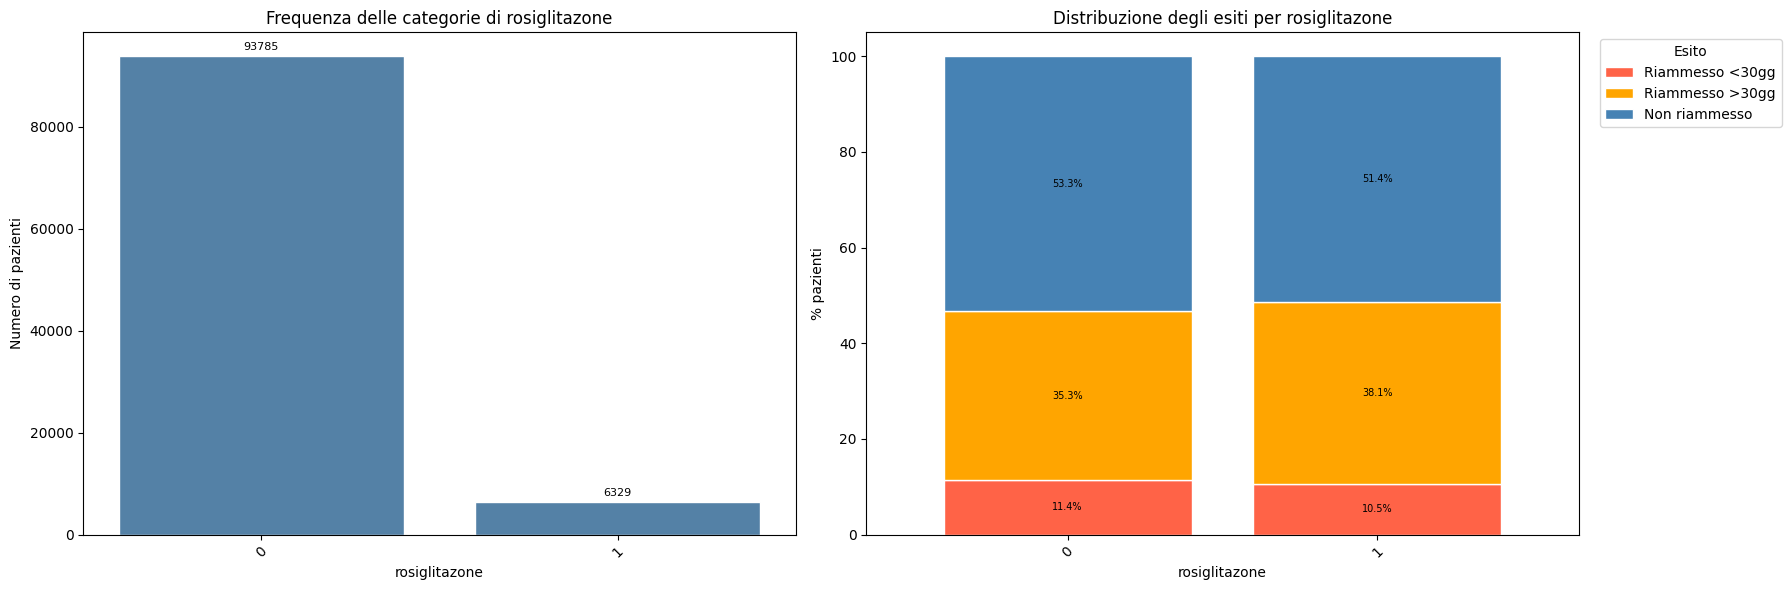

In [ ]:
df["rosiglitazone"] = (df["rosiglitazone"] != "No").astype(int)
plot_categorical_variable_analysis(df, "rosiglitazone", y, top_n=20)

**Commento sul grafico di `rosiglitazone`:**

La variabile rosiglitazone non viene mantenuta perché presenta una distribuzione fortemente sbilanciata verso la categoria “No”. Sebbene la categoria “Steady” abbia una numerosità discreta, la distribuzione degli esiti risulta abbastanza simile a quella della categoria principale, suggerendo una limitata capacità discriminante rispetto alla variabile target. Inoltre, le categorie “Up” e “Down” hanno numerosità molto ridotte, rendendo poco affidabili le differenze percentuali osservate. Per questi motivi, la variabile rischia di aggiungere complessità al modello senza apportare un contributo predittivo stabile e significativo.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["rosiglitazone"], inplace=True)

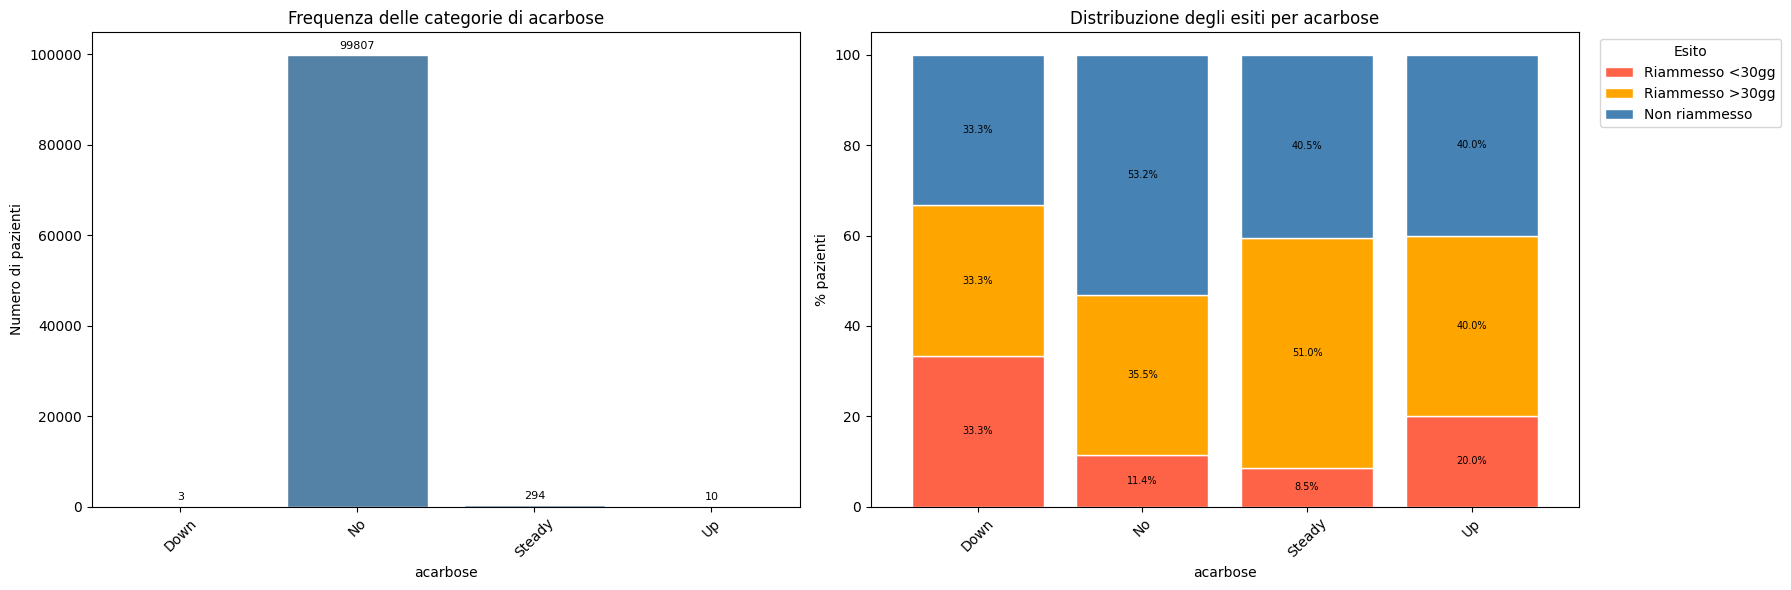

In [ ]:
#@title Grafico analisi: acarbose
plot_categorical_variable_analysis(df, "acarbose", y, top_n=20)

**Commento sul grafico di `acarbose`:**

La variabile acarbose non viene mantenuta perché presenta una distribuzione fortemente sbilanciata: la quasi totalità dei pazienti appartiene alla categoria “No”, mentre le categorie “Steady”, “Up” e “Down” hanno numerosità molto ridotte. Sebbene la distribuzione degli esiti sembri differire tra le categorie, tali differenze sono in parte calcolate su pochi casi e quindi non risultano pienamente affidabili né generalizzabili. L’inclusione della variabile potrebbe introdurre rumore e favorire overfitting, senza garantire un contributo predittivo stabile al modello.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["acarbose"], inplace=True)

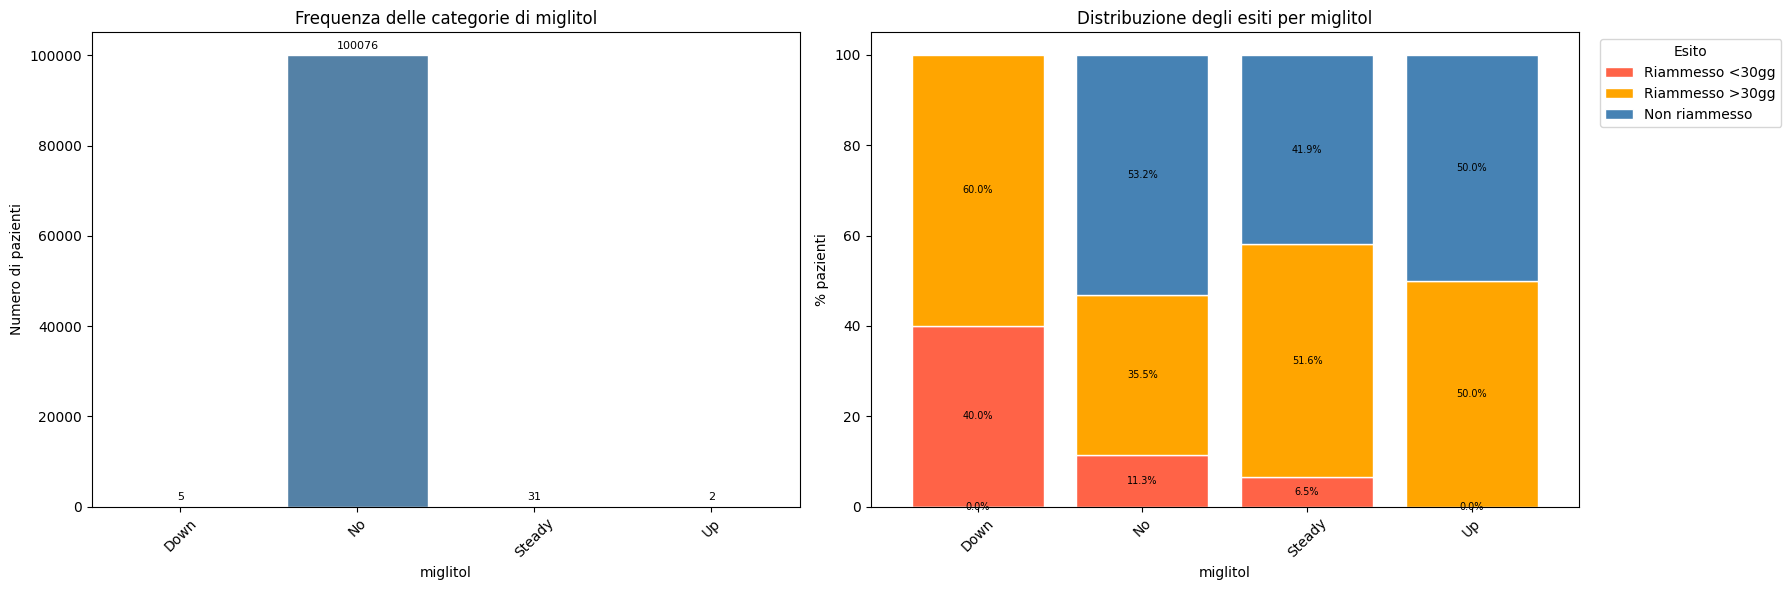

In [ ]:
#@title Grafico analisi: miglitol
plot_categorical_variable_analysis(df, "miglitol", y, top_n=20)

**Commento sul grafico di `miglitol`:**

La variabile miglitol non viene mantenuta perché presenta una distribuzione estremamente sbilanciata: la quasi totalità dei pazienti appartiene alla categoria “No”, mentre le categorie “Steady”, “Down” e “Up” hanno numerosità molto ridotte. Sebbene la distribuzione degli esiti sembri differire tra le categorie, tali differenze sono calcolate su pochi casi e quindi non risultano affidabili né generalizzabili. L’inclusione della variabile potrebbe introdurre rumore e favorire overfitting, senza apportare un contributo predittivo stabile al modello. Per questo motivo si ritiene opportuno eliminarla dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["miglitol"], inplace=True)

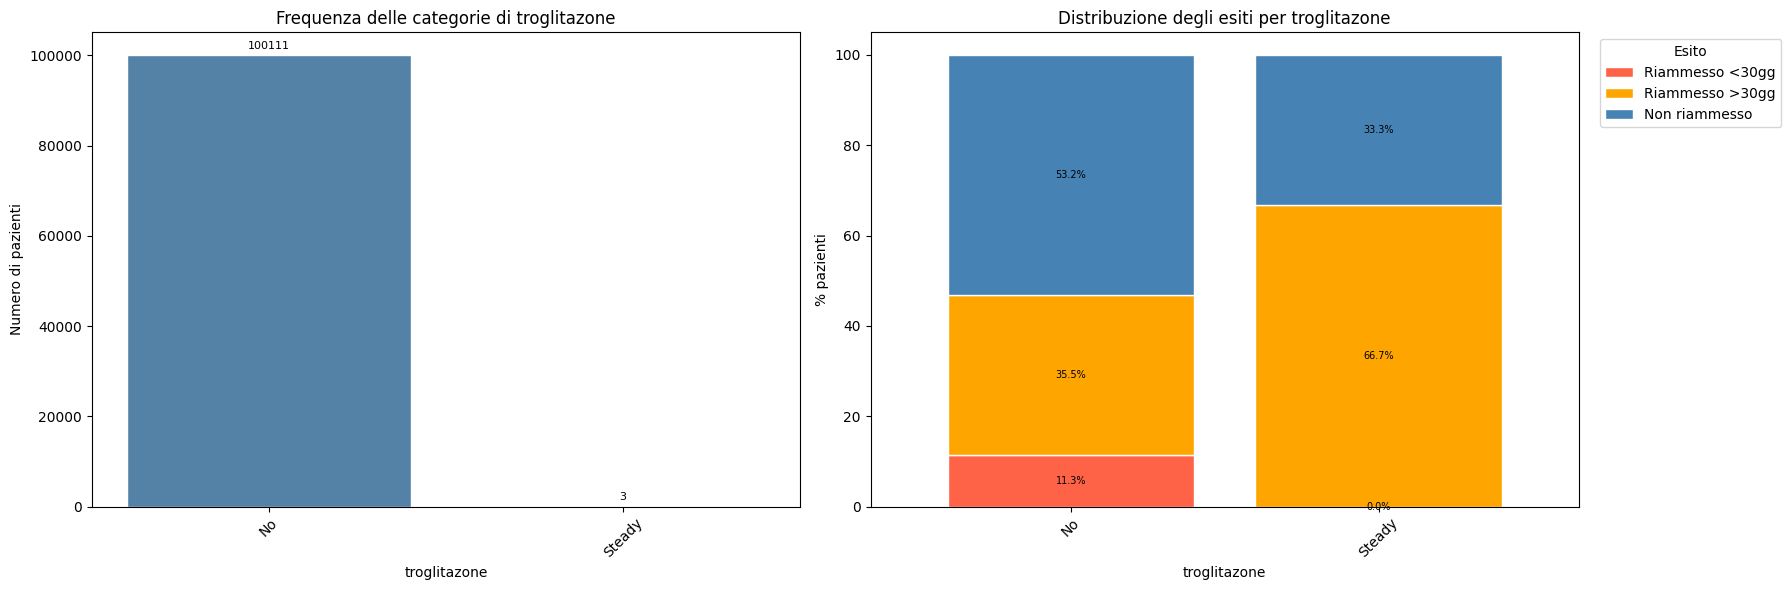

In [ ]:
#@title Grafico analisi: troglitazone
plot_categorical_variable_analysis(df, "troglitazone", y, top_n=20)

**Commento sul grafico di `troglitazone`:**

La variabile troglitazone non viene mantenuta perché presenta una distribuzione estremamente sbilanciata: la quasi totalità dei pazienti appartiene alla categoria “No”, mentre la categoria “Steady” contiene solo 3 osservazioni. Sebbene la distribuzione degli esiti sembri differire tra le due categorie, tale differenza è calcolata su un numero troppo ridotto di casi per essere considerata affidabile. L’inclusione della variabile potrebbe introdurre rumore e favorire overfitting, senza apportare un contributo predittivo stabile al modello. Per questo motivo si ritiene opportuno eliminarla dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["troglitazone"], inplace=True)

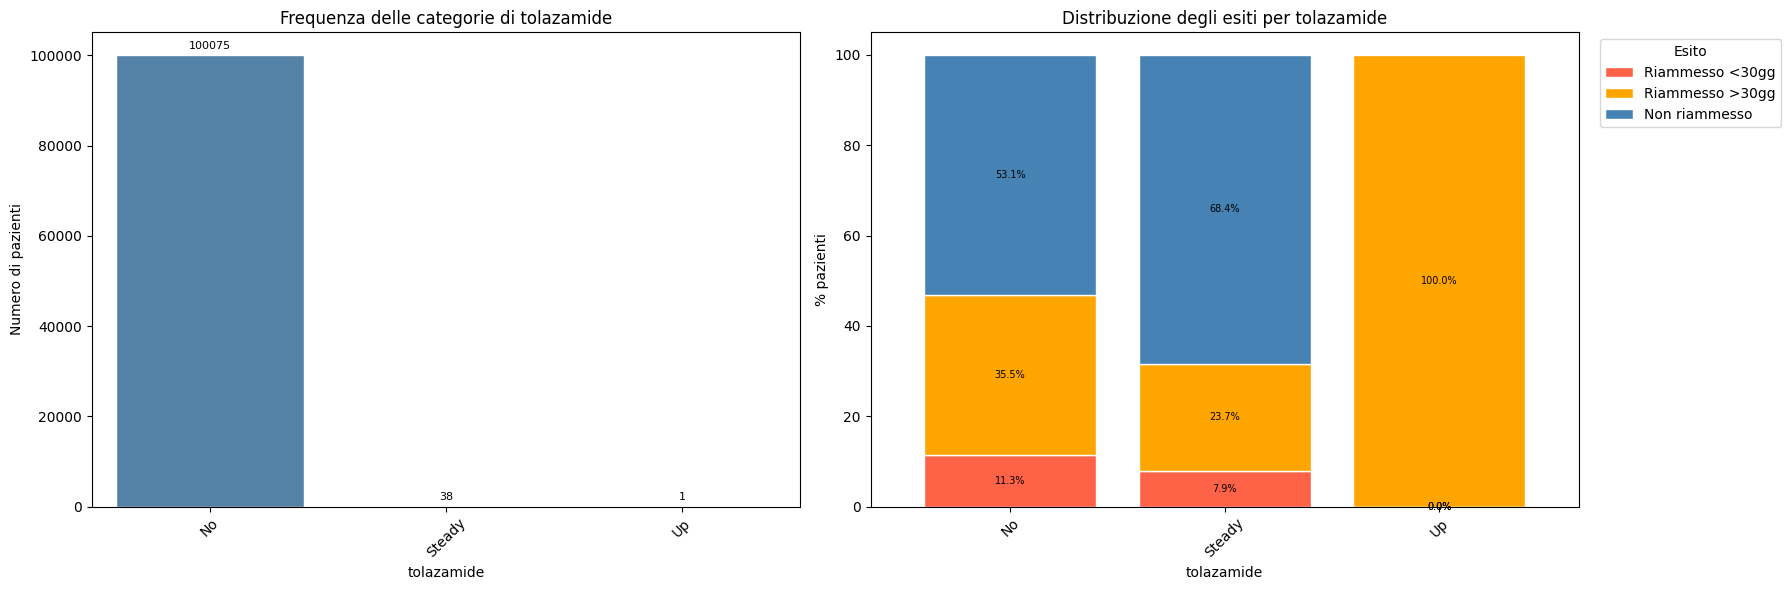

In [ ]:
#@title Grafico analisi: tolazamide
plot_categorical_variable_analysis(df, "tolazamide", y, top_n=20)

**Commento sul grafico di `tolazamide`:**

La variabile tolazamide non viene mantenuta perché presenta una distribuzione estremamente sbilanciata: la quasi totalità dei pazienti appartiene alla categoria “No”, mentre le categorie “Steady” e “Up” hanno numerosità molto ridotte. Le differenze osservate nella distribuzione degli esiti non sono quindi affidabili, poiché calcolate su pochi casi, in particolare la categoria “Up” contiene una sola osservazione. L’inclusione della variabile potrebbe introdurre rumore e favorire overfitting, senza apportare un contributo predittivo stabile al modello. Per questo motivo si ritiene opportuno eliminarla dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["tolazamide"], inplace=True)

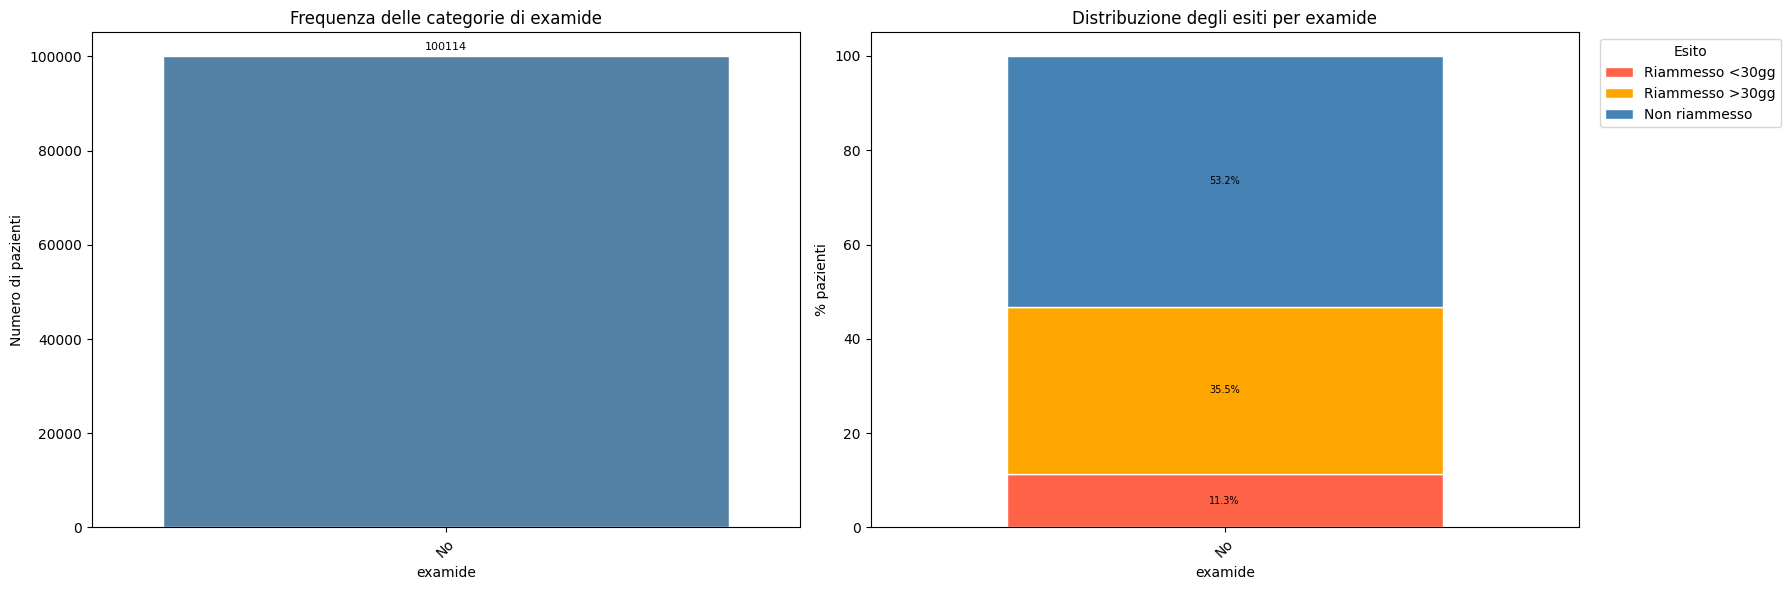

In [ ]:
#@title Grafico analisi: examide
plot_categorical_variable_analysis(df, "examide", y, top_n=20)

**Commento sul grafico di `examide`:**

La variabile examide non viene mantenuta perché presenta una sola modalità osservata, “No”, condivisa da tutti i pazienti. Di conseguenza, la variabile è costante e non possiede capacità discriminante rispetto alla variabile target. Non introducendo alcuna variazione tra le osservazioni, non fornisce informazioni utili al modello predittivo. Per questo motivo si ritiene opportuno eliminarla dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["examide"], inplace=True)

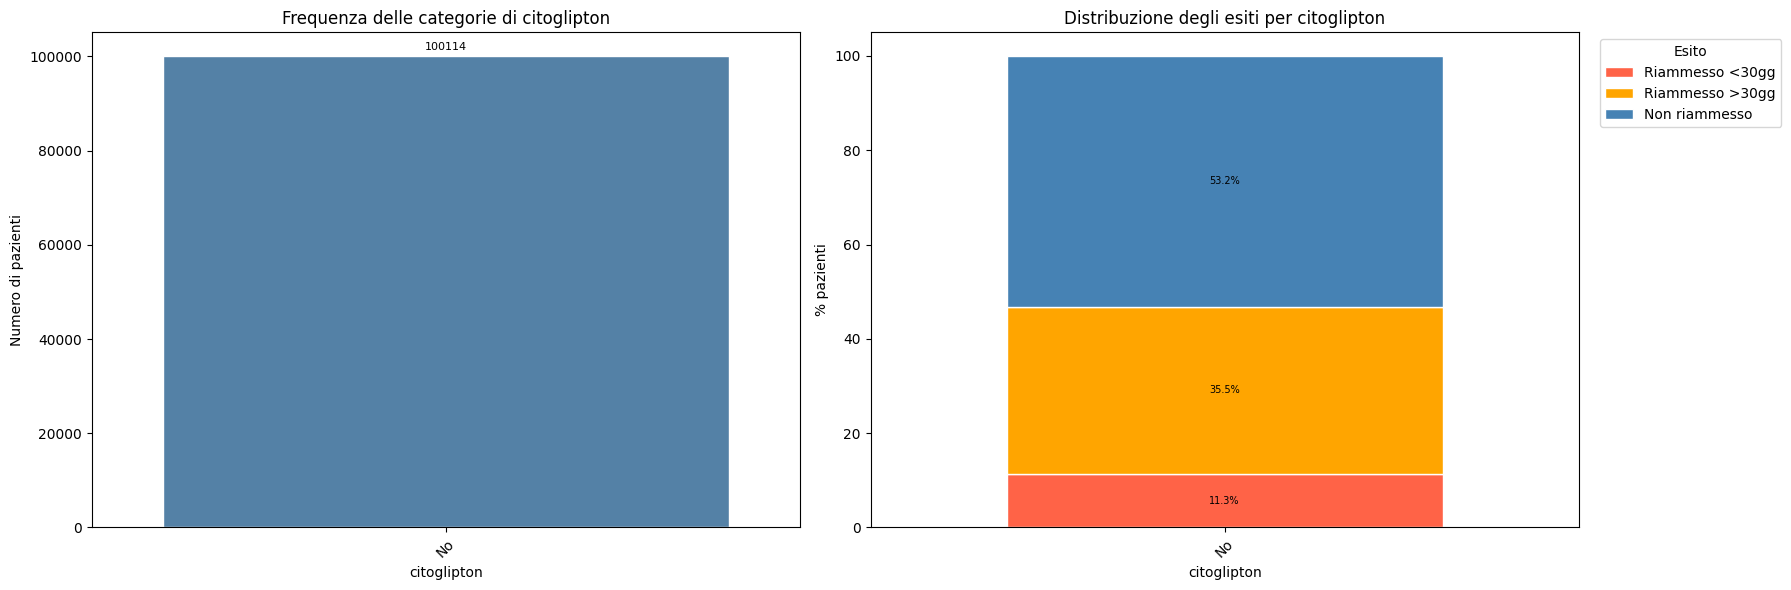

In [ ]:
#@title Grafico analisi: citoglipton
plot_categorical_variable_analysis(df, "citoglipton", y, top_n=20)

**Commento sul grafico di `citoglipton`:**

La variabile citoglipton non viene mantenuta perché presenta una sola modalità osservata, “No”, condivisa da tutti i pazienti. Di conseguenza, la variabile è costante e non possiede capacità discriminante rispetto alla variabile target. Non introducendo alcuna variazione tra le osservazioni, non fornisce informazioni utili al modello predittivo. Per questo motivo si ritiene opportuno eliminarla dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["citoglipton"], inplace=True)

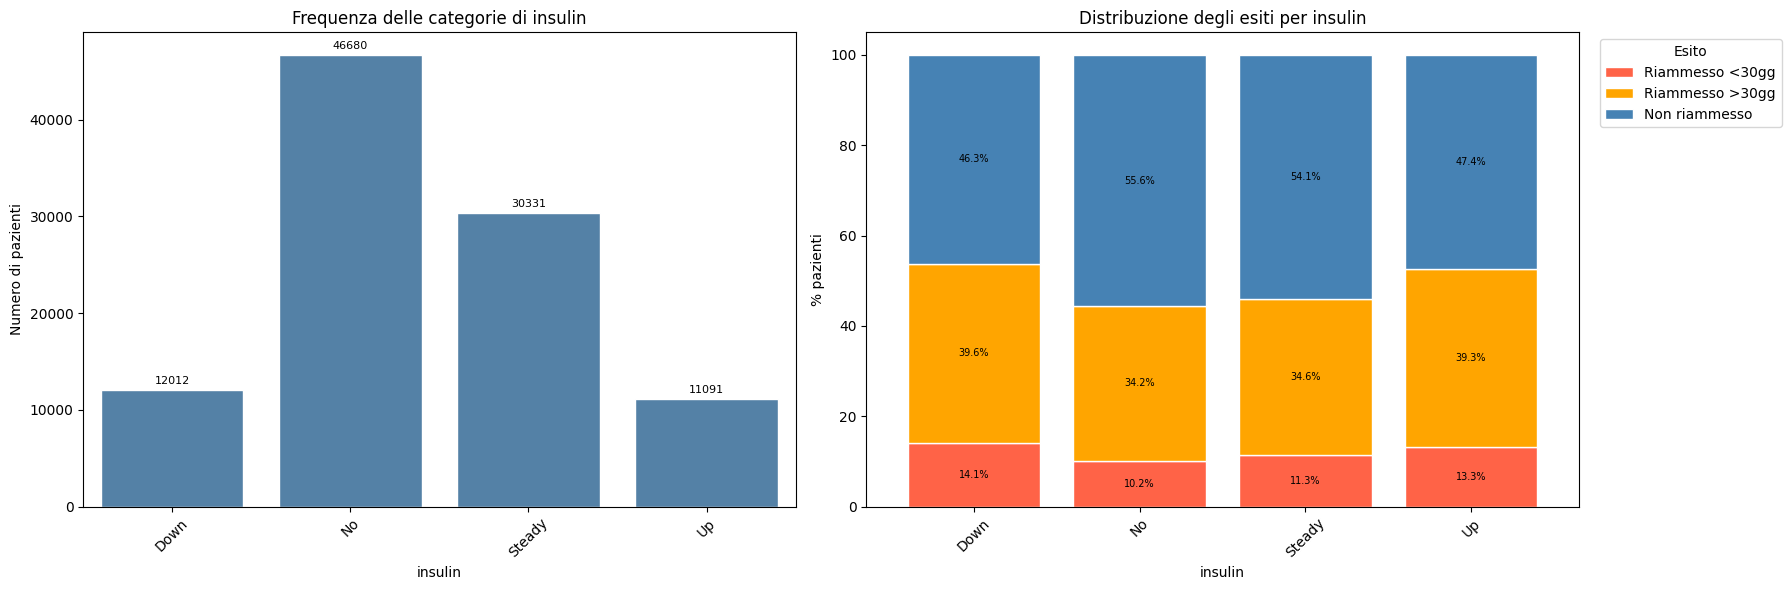

In [ ]:
#@title Grafico analisi: insulin
plot_categorical_variable_analysis(df, "insulin", y, top_n=20)

**Commento sul grafico di `insulin`:**

La variabile insulin viene mantenuta perché presenta una distribuzione sufficientemente bilanciata tra le diverse categorie e tutte le modalità hanno numerosità rilevante. Inoltre, la distribuzione degli esiti varia tra le categorie: i pazienti con variazione del dosaggio, in particolare nelle categorie “Up” e “Down”, mostrano una quota più bassa di non riammissione rispetto alla categoria “No”. Dal punto di vista clinico, l’utilizzo e la modifica dell’insulina rappresentano informazioni rilevanti sulla gravità del diabete e sulla gestione terapeutica del paziente. Per questi motivi, la variabile risulta informativa e viene mantenuta nel dataset.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


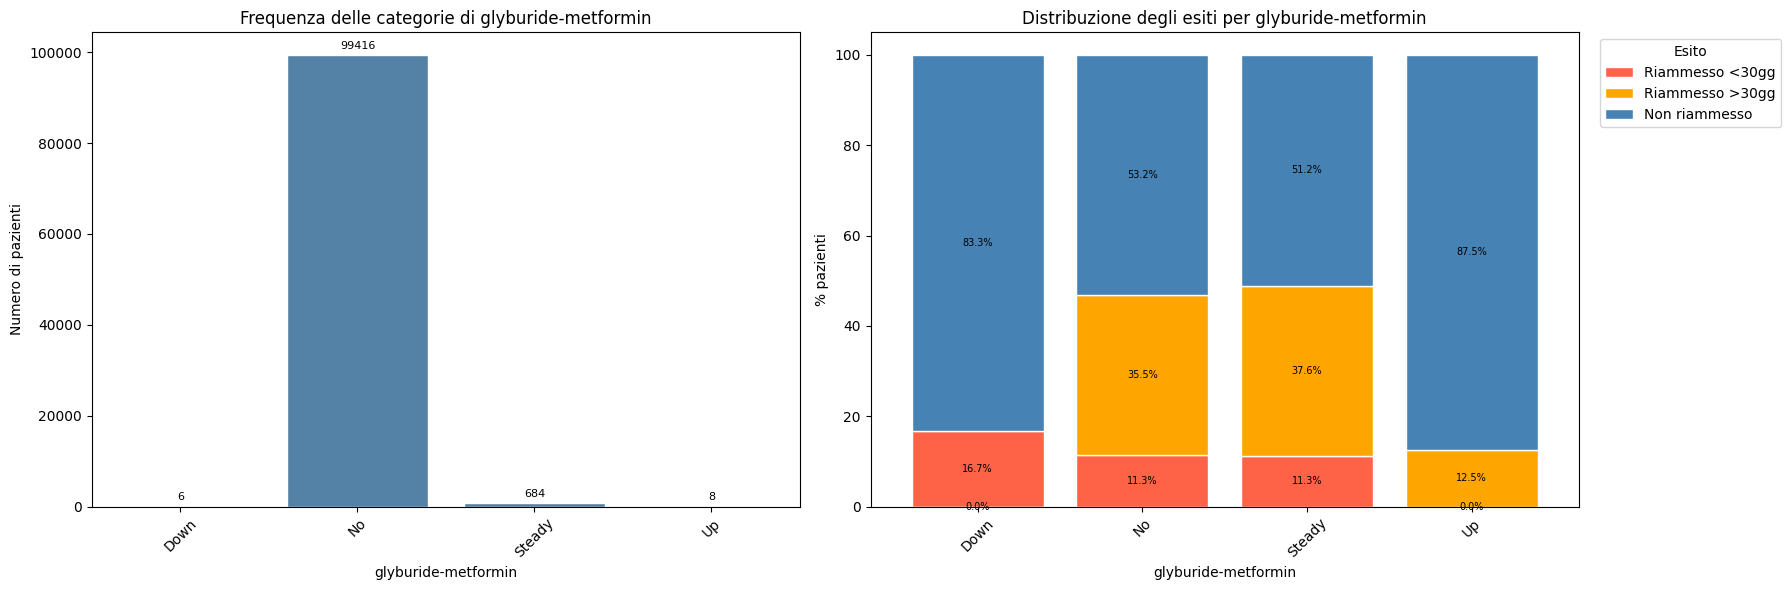

In [ ]:
#@title Grafico analisi: glyburide-metformin
plot_categorical_variable_analysis(df, "glyburide-metformin", y, top_n=20)

**Commento sul grafico di `glyburide-metformin`:**

La variabile glyburide-metformin non viene mantenuta perché presenta una distribuzione fortemente sbilanciata verso la categoria “No”. Sebbene la categoria “Steady” contenga un numero discreto di osservazioni, la distribuzione degli esiti risulta molto simile a quella della categoria principale, suggerendo una limitata capacità discriminante rispetto alla variabile target. Inoltre, le categorie “Up” e “Down” hanno numerosità estremamente ridotte, rendendo poco affidabili le percentuali osservate. Per questi motivi, la variabile rischia di aggiungere complessità e rumore al modello senza fornire un contributo predittivo stabile.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["glyburide-metformin"], inplace=True)

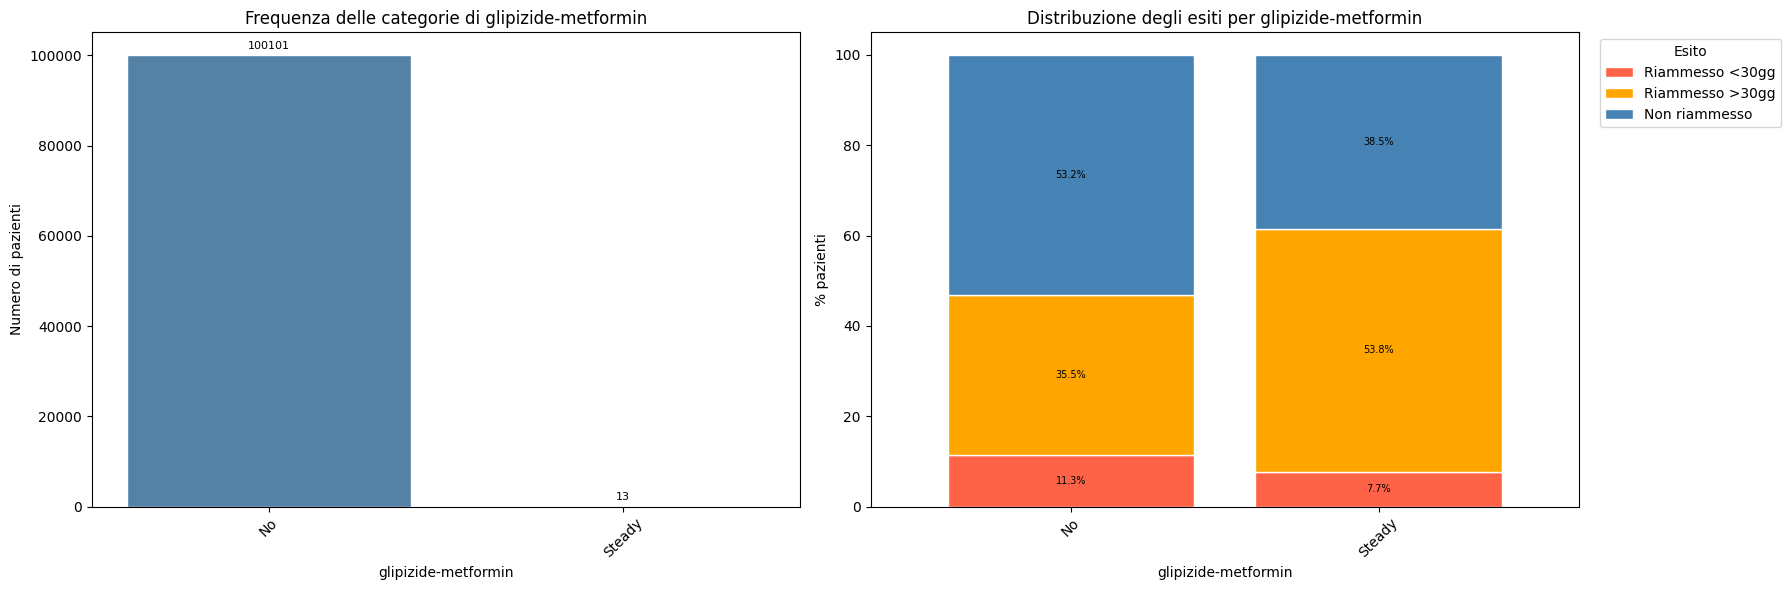

In [ ]:
#@title Grafico analisi: glipizide-metformin
plot_categorical_variable_analysis(df, "glipizide-metformin", y, top_n=20)

**Commento sul grafico di `glipizide-metformin`:**

La variabile glipizide-metformin non viene mantenuta perché presenta una distribuzione estremamente sbilanciata: quasi tutti i pazienti appartengono alla categoria “No”, mentre la categoria “Steady” contiene solo 13 osservazioni. Sebbene la distribuzione degli esiti sembri differire tra le due categorie, tale differenza è calcolata su un numero troppo ridotto di pazienti per essere considerata affidabile e generalizzabile. L’inclusione della variabile potrebbe quindi introdurre rumore e favorire overfitting, senza apportare un contributo predittivo stabile al modello.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["glipizide-metformin"], inplace=True)

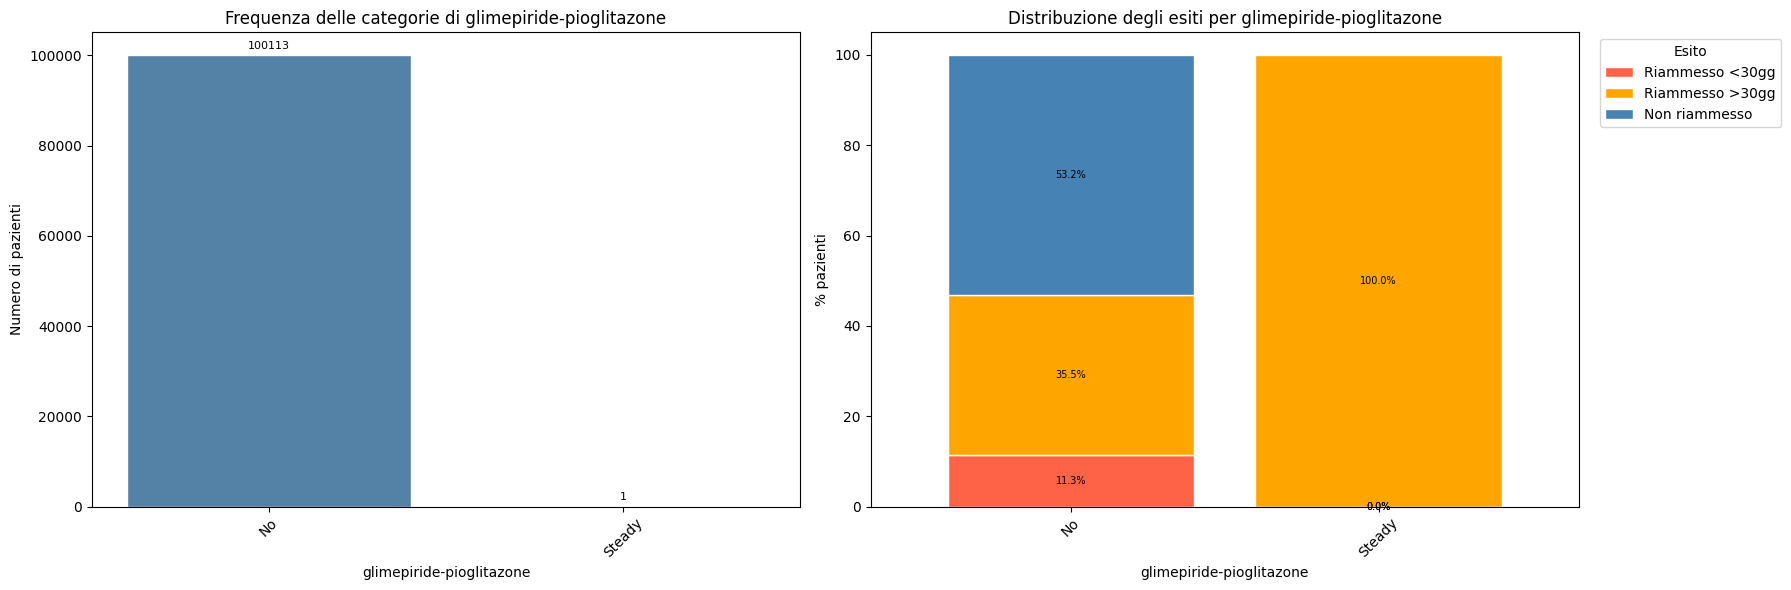

In [ ]:
#@title Grafico analisi: glimepiride-pioglitazone
plot_categorical_variable_analysis(df, "glimepiride-pioglitazone", y, top_n=20)

**Commento sul grafico di `glimepiride-pioglitazone`:**

La variabile glimepiride-pioglitazone non viene mantenuta perché presenta una distribuzione estremamente sbilanciata: quasi tutti i pazienti appartengono alla categoria “No”, mentre la categoria “Steady” contiene un solo caso. La differenza osservata nella distribuzione degli esiti per la categoria “Steady” non è statisticamente affidabile, poiché calcolata su una sola osservazione. Di conseguenza, la variabile ha varianza quasi nulla e rischia di introdurre rumore o overfitting nel modello. Per questo motivo si ritiene opportuno eliminarla dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["glimepiride-pioglitazone"], inplace=True)

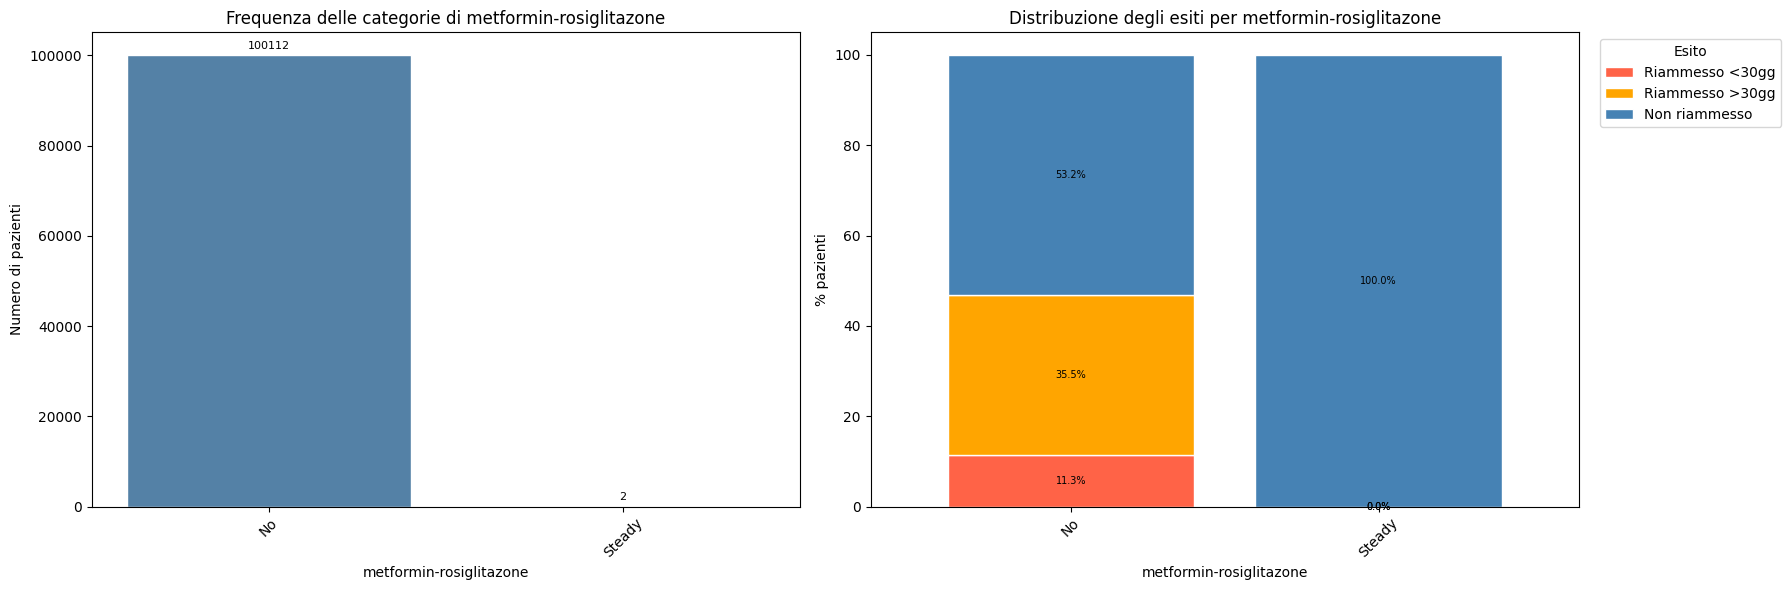

In [ ]:
#@title Grafico analisi: metformin-rosiglitazone
plot_categorical_variable_analysis(df, "metformin-rosiglitazone", y, top_n=20)

**Commento sul grafico di `metformin-rosiglitazone`:**

La variabile metformin-rosiglitazone non viene mantenuta perché presenta una sola modalità osservata, “No”, condivisa da tutti i pazienti. Di conseguenza, la variabile è costante e non fornisce alcuna capacità discriminante rispetto alla variabile target. Non essendoci variazione tra le osservazioni, il modello non può ricavare informazioni utili da questa feature. Per questo motivo si ritiene opportuno eliminarla dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere


In [ ]:
df.drop(columns=["metformin-rosiglitazone"], inplace=True)

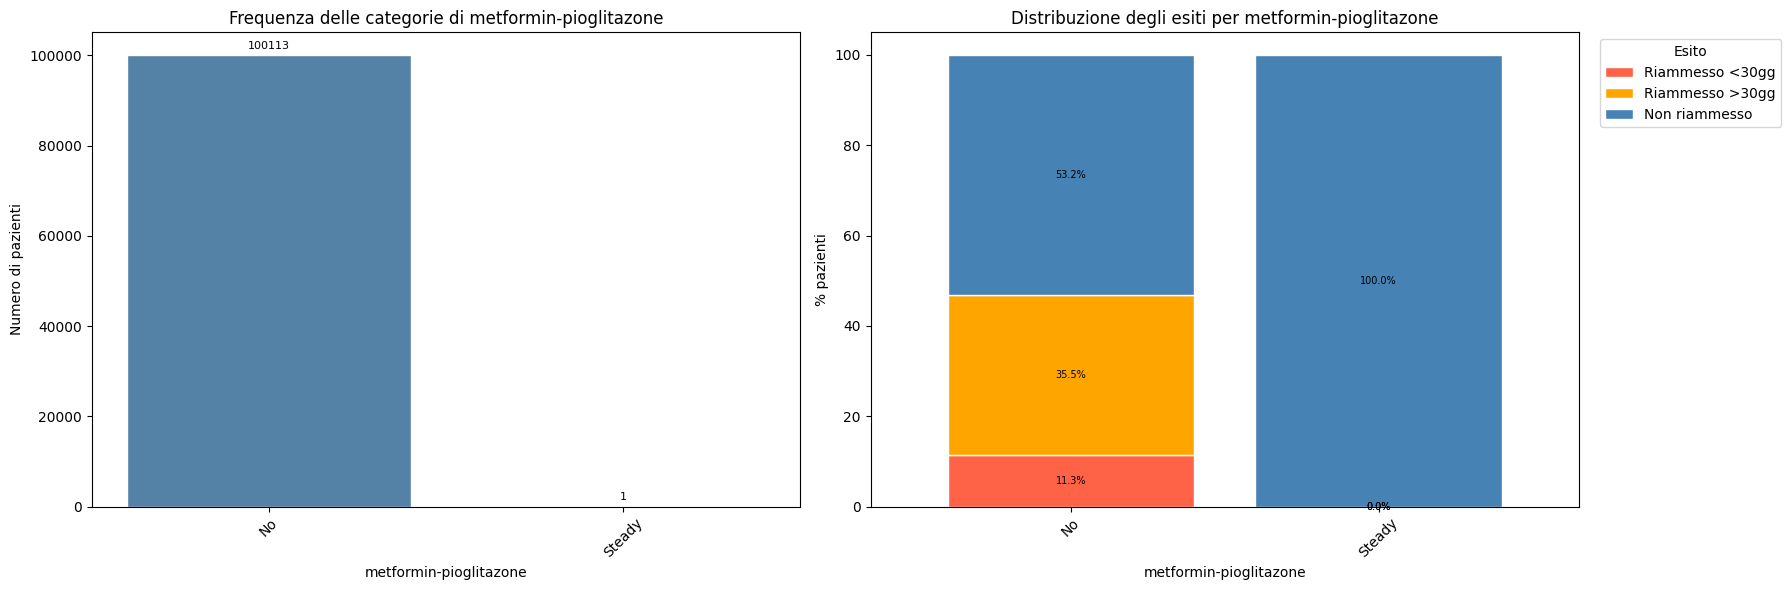

In [ ]:
#@title Grafico analisi: metformin-pioglitazone
plot_categorical_variable_analysis(df, "metformin-pioglitazone", y, top_n=20)

**Commento sul grafico di `metformin-pioglitazone`:**

La variabile metformin-pioglitazone non viene mantenuta perché presenta una distribuzione estremamente sbilanciata: quasi tutti i pazienti appartengono alla categoria “No”, mentre la categoria “Steady” contiene un solo caso. Di conseguenza, la differenza osservata nella distribuzione degli esiti non è statisticamente affidabile né generalizzabile. La variabile ha quindi varianza quasi nulla e rischia di introdurre rumore nel modello, senza apportare un contributo predittivo stabile. Per questo motivo si ritiene opportuno eliminarla dal dataset.

<br>

**Decisione sulla feature:** [ ] mantenere  [x] rimuovere  


In [ ]:
df.drop(columns=["metformin-pioglitazone"], inplace=True)

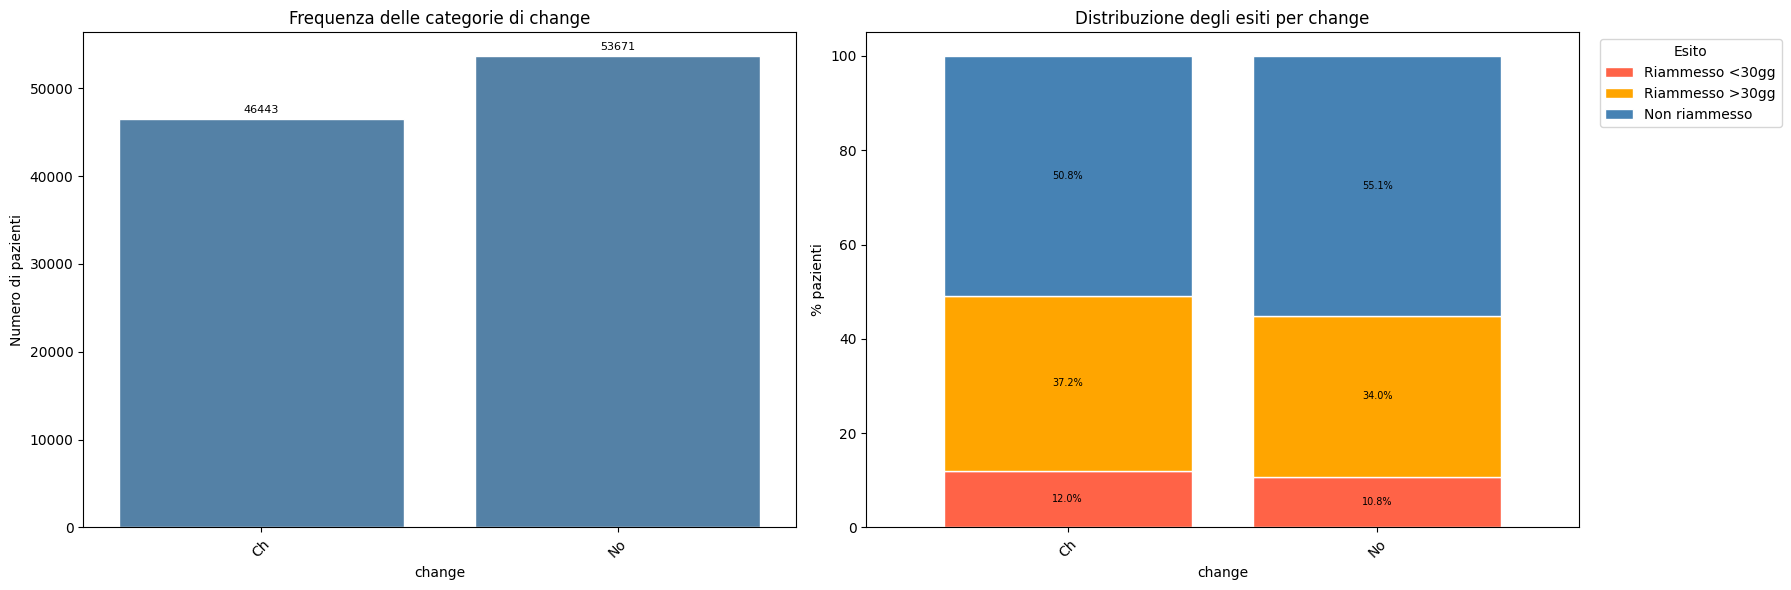

In [ ]:
#@title Grafico analisi: change
plot_categorical_variable_analysis(df, "change", y, top_n=20)

**Commento sul grafico di `change`:**

La variabile change viene mantenuta perché presenta una distribuzione equilibrata tra le categorie “Ch” e “No”, entrambe rappresentate da un numero elevato di osservazioni. Inoltre, la distribuzione degli esiti mostra differenze tra i due gruppi: i pazienti con cambiamento della terapia presentano una quota più bassa di non riammissione e una quota leggermente più alta di riammissioni. Dal punto di vista clinico, una modifica della terapia può riflettere una maggiore complessità del paziente o una diversa gestione del diabete. Per questi motivi, la variabile è considerata informativa e viene mantenuta nel dataset.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere

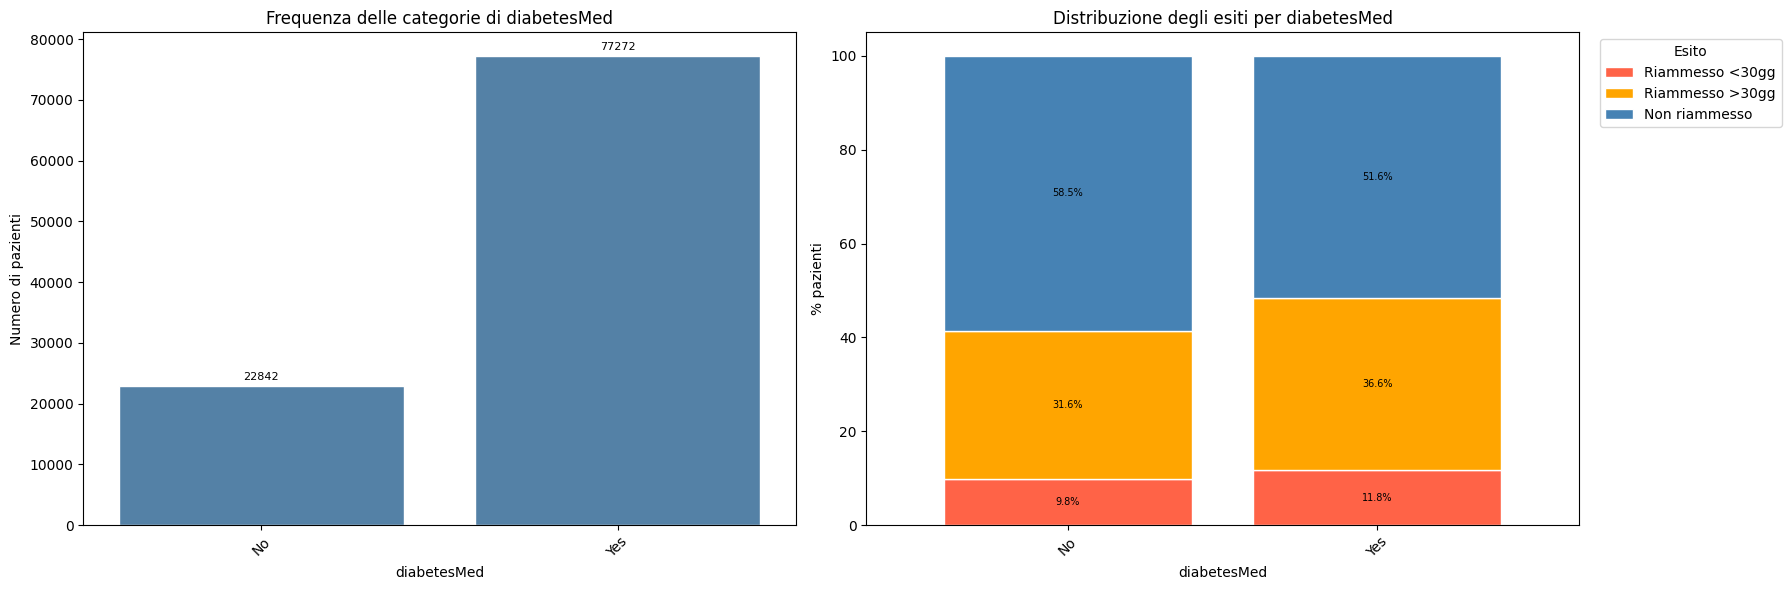

In [ ]:
#@title Grafico analisi: diabetesMed
plot_categorical_variable_analysis(df, "diabetesMed", y, top_n=20)

**Commento sul grafico di `diabetesMed`:**

La variabile diabetesMed viene mantenuta perché presenta una numerosità elevata in entrambe le categorie e mostra differenze nella distribuzione degli esiti. In particolare, i pazienti che assumono farmaci per il diabete presentano una quota più bassa di non riammissione e una quota più alta di riammissioni rispetto ai pazienti che non assumono tali farmaci. Dal punto di vista clinico, la presenza di terapia farmacologica per il diabete può rappresentare un indicatore della condizione del paziente e della complessità della gestione terapeutica. Per questi motivi, la variabile risulta informativa e viene mantenuta nel dataset.

<br>

**Decisione sulla feature:** [x] mantenere  [ ] rimuovere


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100114 entries, 0 to 101765
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   age                       100114 non-null  category
 1   admission_type_id         100114 non-null  category
 2   discharge_disposition_id  100114 non-null  category
 3   admission_source_id       100114 non-null  category
 4   time_in_hospital          100114 non-null  int64   
 5   num_lab_procedures        100114 non-null  int64   
 6   num_procedures            100114 non-null  int64   
 7   num_medications           100114 non-null  int64   
 8   number_outpatient         100114 non-null  int64   
 9   number_emergency          100114 non-null  int64   
 10  number_inpatient          100114 non-null  int64   
 11  diag_1                    100093 non-null  string  
 12  diag_2                    99756 non-null   string  
 13  diag_3                    98693 no

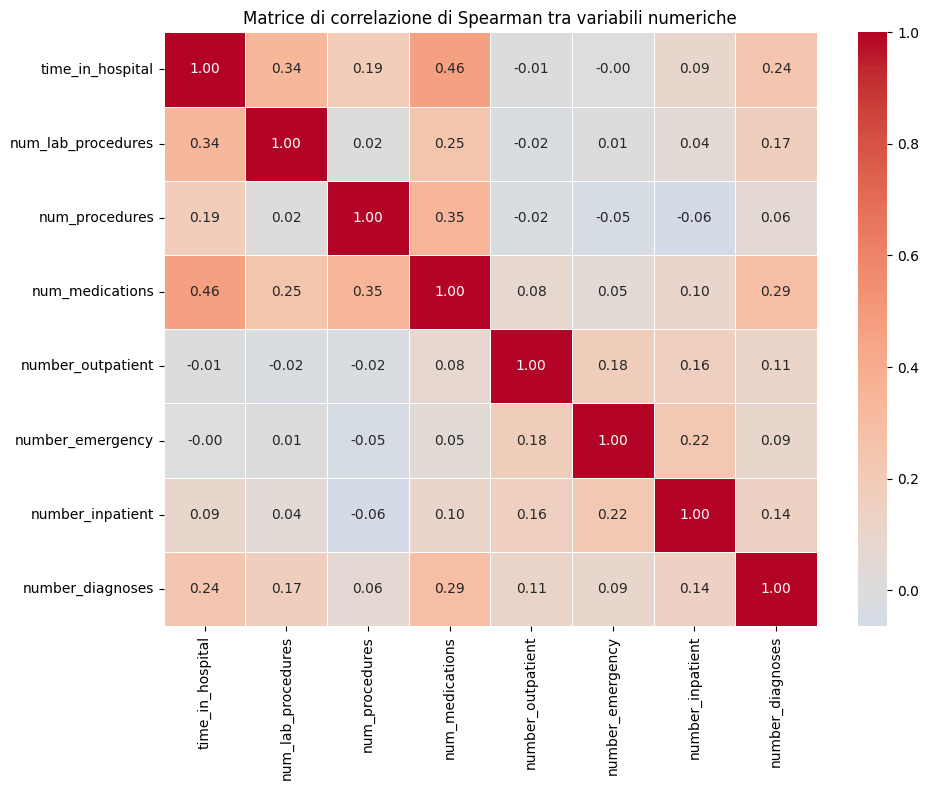

In [ ]:
corr_numeric = df[numeric_cols].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_numeric,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matrice di correlazione di Spearman tra variabili numeriche")
plt.tight_layout()
plt.show()

Dalla matrice di correlazione emerge che non sono presenti coefficienti di correlazione particolarmente elevati tra le variabili. Di conseguenza, non si evidenzia la necessità di condensare o aggregare più variabili tra loro, poiché ciascuna apporta un contributo informativo distinto.

# Preparazione dei dati

**Modifica di age**

La variabile age è originariamente rappresentata tramite fasce d’età decennali, quindi è una variabile categorica ordinale. Le sue modalità non sono semplici categorie nominali indipendenti, ma seguono un ordine naturale crescente. Per questo motivo si decide di trasformare ciascun intervallo nel valore centrale della fascia corrispondente, ad esempio [50-60) viene codificato con 55.

Questa trasformazione permette di conservare l’informazione ordinale contenuta nella variabile e, allo stesso tempo, di renderla utilizzabile dai modelli predittivi come variabile numerica.

In [ ]:
df["age"].value_counts()

,count
age,
[70-80),25562
[60-70),22185
[50-60),17102
[80-90),16706
[40-50),9626
[30-40),3765
[90-100),2668
[20-30),1650
[10-20),690


In [ ]:
age_map = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df["age_midpoint"] = df["age"].map(age_map).astype(int)

/tmp/ipykernel_5374/3845496504.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col: df[col].astype(object).fillna("Missing").astype(str),


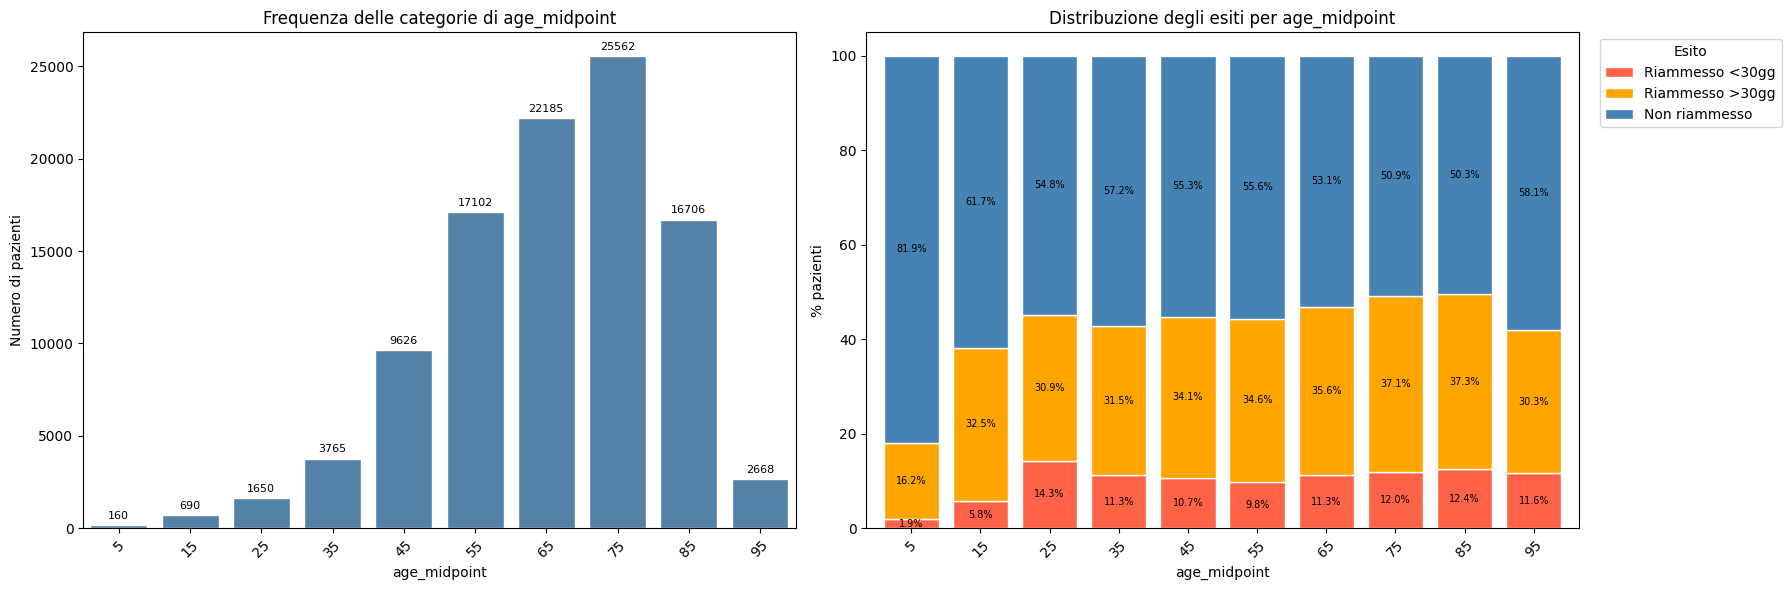

In [ ]:
plot_categorical_variable_analysis(df, "age_midpoint", y, top_n=20)

**Creazione variabile artificiale per age**

La variabile `age` è rappresentata tramite fasce decennali ordinate. Per questo motivo viene mantenuta una codifica numerica tramite il valore centrale della fascia (`age_midpoint`), che consente di conservare l’informazione ordinale dell’età.

Tuttavia, dal grafico della distribuzione degli esiti per fascia d’età si osserva che la relazione tra età e riammissione non è perfettamente lineare. Alcune fasce mostrano percentuali diverse di riammissione, e le classi più giovani presentano una numerosità molto ridotta, rendendo meno stabile l’informazione associata alle singole categorie.

Per questo motivo viene introdotta una variabile artificiale `age_group`, che raggruppa le fasce d’età in macro-categorie più ampie e interpretabili. Questa scelta permette di catturare eventuali differenze tra gruppi di pazienti giovani, adulti e anziani, riducendo al tempo stesso il rumore dovuto alle fasce con pochi casi.

L’utilizzo congiunto di `age_midpoint` e `age_group` consente quindi di preservare sia l’ordine naturale dell’età sia eventuali effetti non lineari osservabili tra macro-fasce.

In [ ]:
def assign_age_group(age):
    if age < 40:
        return "young"
    elif age < 70:
        return "adult"
    else:
        return "elderly"

df["age_group"] = df["age_midpoint"].apply(assign_age_group)

In [ ]:
df = df.drop(columns=["age"])

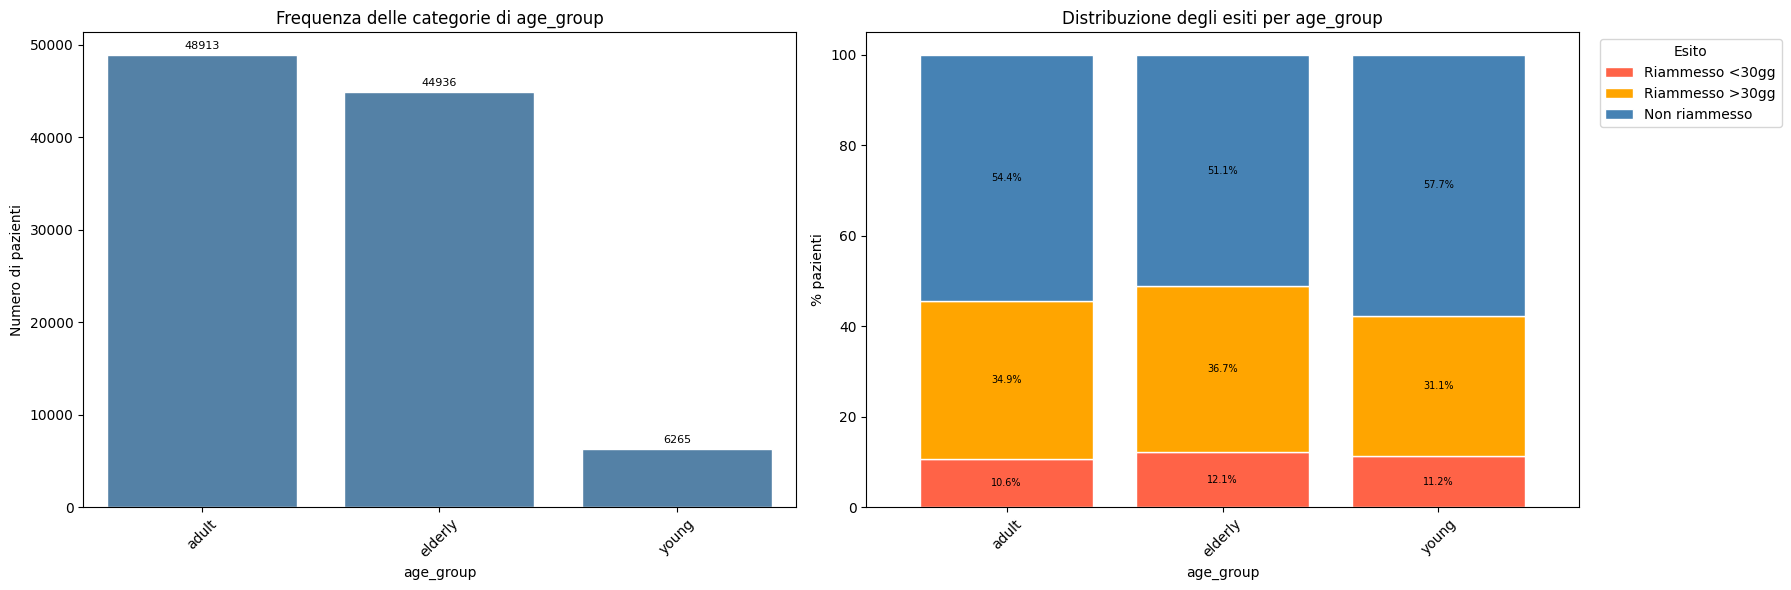

In [ ]:
plot_categorical_variable_analysis(df, "age_group", y, top_n=20)

In [ ]:
df = pd.get_dummies(
    df,
    columns=["age_group"],
    drop_first=True,
    dtype=int
)

**Modifica di admission_type_id**

La variabile admission_type_id è rappresentata tramite codici numerici, ma tali valori non devono essere interpretati come quantità o come livelli ordinati. Ogni codice identifica infatti una diversa tipologia di ammissione ospedaliera, quindi la variabile ha natura categorica nominale.

Per questo motivo si applica una codifica one-hot, trasformando ciascun tipo di ammissione in una variabile binaria separata. In questo modo si evita che il modello interpreti erroneamente i codici come valori numerici ordinabili o confrontabili tra loro. La trasformazione permette quindi di preservare il significato categorico della variabile e di renderla adatta all’utilizzo nei modelli predittivi.

In [ ]:
df["admission_type_id"].value_counts()

,count
admission_type_id,
1,52884
3,18739
2,18226
6,5227
5,4690
8,320
7,18
4,10


In [ ]:
df = pd.get_dummies(
    df,
    columns=["admission_type_id"],
    prefix="admission_type",
    dtype=int,
    drop_first=True
)

**Modifica di discharge_disposition_id**

La variabile discharge_disposition_id rappresenta la modalità di dimissione del paziente, cioè la destinazione o condizione del paziente al termine del ricovero. Sebbene sia codificata tramite valori numerici, questi codici identificano categorie nominali e non devono essere interpretati come grandezze numeriche ordinate.

Prima della codifica, sono stati rimossi i codici associati al decesso del paziente, poiché tali osservazioni non sono coerenti con l’obiettivo predittivo del progetto: un paziente deceduto non può essere riammesso in ospedale. Inoltre, mantenere tali codici potrebbe introdurre leakage informativo.

Dopo questa pulizia, si applica una codifica one-hot per rappresentare correttamente le diverse modalità di dimissione come variabili binarie distinte. In questo modo si evita che il modello attribuisca un ordine artificiale ai codici numerici e si conserva il significato categorico della variabile.

In [ ]:
df["discharge_disposition_id"].value_counts()

,count
discharge_disposition_id,
1,60234
3,13954
6,12902
18,3691
2,2128
22,1993
5,1184
25,989
4,815


In [ ]:
df = pd.get_dummies(
    df,
    columns=["discharge_disposition_id"],
    prefix="discharge_disposition",
    drop_first=True,
    dtype=int

)

**Modifica di admission_source_id**

La variabile admission_source_id rappresenta la fonte di ammissione del paziente, cioè il canale attraverso cui il paziente è arrivato al ricovero. Sebbene sia codificata tramite valori numerici, tali valori identificano categorie nominali e non devono essere interpretati come grandezze numeriche o ordinali.

Per evitare che il modello attribuisca ai codici un ordine artificiale o una distanza matematica inesistente, si applica una codifica one-hot. In questo modo ogni fonte di ammissione viene rappresentata tramite una variabile binaria distinta, preservando correttamente il significato categorico della feature e rendendola utilizzabile nella fase di modellazione.

In [ ]:
df["admission_source_id"].value_counts()

,count
admission_source_id,
7,56363
1,29322
17,6645
4,3132
6,2244
2,1083
5,814
3,185
20,159


In [ ]:
df = pd.get_dummies(
    df,
    columns=["admission_source_id"],
    prefix="admission_source",
    drop_first=True,
    dtype=int
)

**Modifica di insulin**

La variabile insulin descrive lo stato della terapia insulinica durante il ricovero, indicando se l’insulina non è stata somministrata, se il dosaggio è rimasto stabile oppure se è stato aumentato o diminuito. Si tratta quindi di una variabile categorica relativa al trattamento farmacologico.

Nonostante le modalità Up e Down facciano riferimento a una variazione del dosaggio, la variabile non viene trattata come numerica ordinale, poiché le categorie non rappresentano valori quantitativi equidistanti. La codifica one-hot consente invece di rappresentare ogni stato terapeutico tramite una variabile binaria separata, evitando che il modello introduca un ordine o una distanza artificiale tra le modalità.

In [ ]:
df["insulin"].value_counts()

,count
insulin,
No,46680
Steady,30331
Down,12012
Up,11091


In [ ]:
df = pd.get_dummies(
    df,
    columns=["insulin"],
    prefix="insulin",
    drop_first=True,
    dtype=int
)

**Modifica di change**

La variabile change indica se durante il ricovero è stata effettuata una modifica nella terapia farmacologica del paziente. Poiché presenta due sole modalità, Ch e No, viene trattata come variabile binaria.

Si assegna il valore 1 ai casi in cui la terapia è stata modificata e il valore 0 ai casi in cui non è stata effettuata alcuna modifica. Questa codifica mantiene il significato informativo della variabile, rende la feature direttamente utilizzabile dai modelli predittivi e non introduce un aumento inutile del numero di colonne, come accadrebbe con una codifica one-hot.

In [ ]:
df["change"].value_counts()

,count
change,
No,53671
Ch,46443


In [ ]:
df["change"] = df["change"].map({
    "No": 0,
    "Ch": 1
}).astype(int)

**Modifica di diabetesMed**

La variabile diabetesMed indica se al paziente è stato prescritto almeno un farmaco per il diabete. Poiché presenta due sole modalità, Yes e No, viene trattata come variabile binaria.

Si assegna il valore 1 ai pazienti per cui è presente una terapia farmacologica per il diabete e il valore 0 ai pazienti per cui tale terapia non è presente. Questa trasformazione conserva il significato della variabile in modo semplice e interpretabile, rendendola direttamente utilizzabile dai modelli predittivi senza introdurre colonne aggiuntive non necessarie.

In [ ]:
df["diabetesMed"].value_counts()

,count
diabetesMed,
Yes,77272
No,22842


In [ ]:
df["diabetesMed"] = df["diabetesMed"].map({
    "No": 0,
    "Yes": 1
}).astype(int)

**Modifica della variabile target readmission**

La variabile target viene codificata in tre classi numeriche, assegnando 0 a NO, 1 a >30 e 2 a <30. Tale trasformazione rende la variabile compatibile con gli algoritmi di classificazione multiclasse, mantenendo però una corrispondenza chiara e interpretabile con le categorie originali.

In [ ]:
target_map = {
    "NO": 0,
    ">30": 1,
    "<30": 2
}

y_model = y.squeeze().map(target_map)

In [ ]:
y_model.value_counts()

,count
readmitted,
0,53212
1,35545
2,11357


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100114 entries, 0 to 101765
Data columns (total 68 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   time_in_hospital          100114 non-null  int64 
 1   num_lab_procedures        100114 non-null  int64 
 2   num_procedures            100114 non-null  int64 
 3   num_medications           100114 non-null  int64 
 4   number_outpatient         100114 non-null  int64 
 5   number_emergency          100114 non-null  int64 
 6   number_inpatient          100114 non-null  int64 
 7   diag_1                    100093 non-null  string
 8   diag_2                    99756 non-null   string
 9   diag_3                    98693 non-null   string
 10  number_diagnoses          100114 non-null  int64 
 11  metformin                 100114 non-null  int64 
 12  change                    100114 non-null  int64 
 13  diabetesMed               100114 non-null  int64 
 14  age_midpo

**Modifica di diag_1, diag_2 e diag_3**

Le variabili diag_1, diag_2 e diag_3 rappresentano rispettivamente la diagnosi principale, la diagnosi secondaria e la terza diagnosi associata al paziente. Poiché queste variabili hanno una diversa importanza clinica, non vengono fuse in un’unica rappresentazione, in modo da non perdere la gerarchia informativa tra diagnosi principale e diagnosi secondarie.

Per ridurre la cardinalità dei codici ICD-9, ciascuna diagnosi viene prima ricondotta a una macro-categoria clinica. Successivamente si applica una codifica one-hot separata per diag_1, diag_2 e diag_3. In questo modo il modello può distinguere, ad esempio, una diagnosi circolatoria principale da una diagnosi circolatoria secondaria, preservando sia l’informazione clinica sia la posizione gerarchica della diagnosi.

In [ ]:
diag_cols = ["diag_1", "diag_2", "diag_3"]

def map_icd9_to_group(code):
    code = str(code).strip().upper()

    if code in ["?", "NAN", "NONE"]:
        return "Missing"

    code = code.split(".")[0]

    if code.startswith("V"):
        return "V_code"
    if code.startswith("E"):
        return "E_code"

    try:
        code_num = int(code)
    except ValueError:
        return "Other"

    if code_num == 250:
        return "Diabetes"
    elif 390 <= code_num <= 459 or code_num == 785:
        return "Circulatory"
    elif 460 <= code_num <= 519 or code_num == 786:
        return "Respiratory"
    elif 520 <= code_num <= 579 or code_num == 787:
        return "Digestive"
    elif 800 <= code_num <= 999:
        return "Injury"
    elif 710 <= code_num <= 739:
        return "Musculoskeletal"
    elif 580 <= code_num <= 629:
        return "Genitourinary"
    elif 140 <= code_num <= 239:
        return "Neoplasms"
    else:
        return "Other"

for col in diag_cols:
    df[col + "_group"] = df[col].apply(map_icd9_to_group)

df = pd.get_dummies(
    df,
    columns=["diag_1_group", "diag_2_group", "diag_3_group"],
    prefix=["diag1", "diag2", "diag3"],
    drop_first=True,
    dtype=int
)

df.drop(columns=["diag_1", "diag_2", "diag_3"], inplace=True)

### Creazione variabili artificiali

Con questa tecnica si introducono features che non erano presenti originariamente nel dataset. Le features aggiunte sono derivate direttamente o indirettamente dalle features già a disposizione nel dataset.

In [ ]:
df["total_prior_visits"] = (
    df["number_outpatient"] + df["number_emergency"] + df["number_inpatient"]
)
df["high_utilizer"]   = (df["total_prior_visits"] > 3).astype(int)
df["polypharmacy"]    = (df["num_medications"] > 10).astype(int)
df["high_comorbidity"] = (df["number_diagnoses"] > 7).astype(int)
df["procedures_per_day"] = (df["num_procedures"] / df["time_in_hospital"]).round(3)

#### Rimozioni righe che presentano dei NaN

In [ ]:
mask = df.notna().all(axis=1)
df = df[mask]
y = y[mask]
y_model = y_model.loc[df.index]

## Divisione in train e test set

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df, y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

FEATURE_COLUMNS = X_train.columns.tolist()
TARGET_NAMES = ['NO', '>30', '<30']

print(f'Train: {X_train.shape[0]} righe')
print(f'Test:  {X_test.shape[0]} righe')
print(f'Numero feature: {len(FEATURE_COLUMNS)}')
print(f'\nClassi nel train:\n{y_train.value_counts()}')
print(f'\nClassi nel test:\n{y_test.value_counts()}')


Train: 80091 righe
Test:  20023 righe
Numero feature: 100

Classi nel train:
readmitted
0    42569
1    28436
2     9086
Name: count, dtype: int64

Classi nel test:
readmitted
0    10643
1     7109
2     2271
Name: count, dtype: int64


In [ ]:
import joblib
import os

# Salvataggio del dataset processato per ripartire velocemente
dataset_paths = {
    'X_train': os.path.join(DRIVE_MODELS_DIR, 'X_train.pkl'),
    'X_test': os.path.join(DRIVE_MODELS_DIR, 'X_test.pkl'),
    'y_train': os.path.join(DRIVE_MODELS_DIR, 'y_train.pkl'),
    'y_test': os.path.join(DRIVE_MODELS_DIR, 'y_test.pkl')
}

joblib.dump(X_train, dataset_paths['X_train'])
joblib.dump(X_test, dataset_paths['X_test'])
joblib.dump(y_train, dataset_paths['y_train'])
joblib.dump(y_test, dataset_paths['y_test'])

print(f"Dataset salvato con successo in: {DRIVE_MODELS_DIR}")
print("In una nuova sessione potrai usare: X_train = joblib.load('percorso/X_train.pkl')")

Dataset salvato con successo in: /content/drive/MyDrive/Colab_Models/diabetes_readmission_models
In una nuova sessione potrai usare: X_train = joblib.load('percorso/X_train.pkl')


# Creazione modelli

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

### Salvataggio modelli su Google Drive


In [ ]:
import json
import os
from pathlib import Path
import joblib

# Configuration for saving
if 'DRIVE_MODELS_DIR' not in globals():
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_MODELS_DIR = '/content/drive/MyDrive/Colab_Models/diabetes_readmission_models'

models_dir = Path(DRIVE_MODELS_DIR)
models_dir.mkdir(parents=True, exist_ok=True)

# Mapping for filenames
MODEL_FILE_MAP = {
    'Perceptron': 'perceptron.pkl',
    'Logistic Regression': 'logistic_regression.pkl',
    'Logistic Regression SMOTE': 'lr_plus_smote.pkl',
    'Linear SVM': 'linear_svm.pkl',
    'Linear SVM SMOTE': 'svm_plus_smote.pkl',
    'Decision Tree': 'decision_tree.pkl',
    'Random Forest': 'random_forest.pkl',
    'XGBoost': 'xgboost.pkl',
    'XGBoost SMOTE': 'xgboost_plus_smote.pkl',
    'CatBoost': 'catboost.pkl',
}

def save_model_to_drive(name, model_obj):
    """Saves a single model and updates the manifest."""
    if name not in MODEL_FILE_MAP:
        print(f"Warning: Model {name} not mapped to a filename.")
        return

    # Extract best estimator if it's a search object
    fitted_model = model_obj.best_estimator_ if hasattr(model_obj, 'best_estimator_') else model_obj

    # Save model
    path = models_dir / MODEL_FILE_MAP[name]
    joblib.dump(fitted_model, path)
    print(f"Successfully saved {name} to {path}")

    # Save helper files if they don't exist
    if not (models_dir / 'feature_columns.pkl').exists():
        joblib.dump(X_train.columns.tolist(), models_dir / 'feature_columns.pkl')
    if not (models_dir / 'target_names.pkl').exists():
        joblib.dump(['NO', '>30', '<30'], models_dir / 'target_names.pkl')

# Helper to print the list of available models later
print(f"Persistence utilities initialized. Models will be saved to: {DRIVE_MODELS_DIR}")

Persistence utilities initialized. Models will be saved to: /content/drive/MyDrive/Colab_Models/diabetes_readmission_models


In [ ]:
all_models = []
cv_results = []

In [ ]:
#@title Valutazione modello

from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, accuracy_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# Nomi delle classi: 0=NO, 1=>30, 2=<30
CLASS_NAMES = ["NO", ">30", "<30"]

def evaluate_models(models, X_test, y_test):
    """
    Valuta una lista di modelli già fittati su X_test, y_test.

    Parameters
    ----------
    models  : dict {name: fitted_model}
              oppure lista [{"name": ..., "model": ...}]
    X_test  : test set features
    y_test  : test set target (values 0, 1, 2)

    Returns
    -------
    summary_df : DataFrame con le metriche di tutti i modelli
    """
    if isinstance(models, list):
        models = {m["name"]: m["model"] for m in models}

    summary = []

    for name, model in models.items():
        print("=" * 60)
        print(f"  {name}")
        print("=" * 60)

        y_pred = model.predict(X_test)

        # --- Accuracy ---
        acc = accuracy_score(y_test, y_pred)
        print(f"\nAccuracy: {acc:.3f}")

        # --- Confusion matrix come DataFrame ---
        cm = confusion_matrix(y_test, y_pred)
        cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
        cm_df.index.name   = "Actual"
        cm_df.columns.name = "Predicted"
        print(f"\nConfusion matrix:\n{cm_df}")

        # --- Classification report: precision, recall, F1 per classe ---
        print(f"\nClassification report:")
        print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

        # --- F1 per classe e F1 macro ---
        f1_per_class = f1_score(y_test, y_pred, average=None)
        f1_macro     = f1_score(y_test, y_pred, average="macro")
        print(f"F1 per class:  NO={f1_per_class[0]:.3f}  "
              f">30={f1_per_class[1]:.3f}  "
              f"<30={f1_per_class[2]:.3f}")
        print(f"F1 macro:      {f1_macro:.3f}")

        # --- Grafico confusion matrix ---
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
            ax=ax, colorbar=False
        )
        ax.set_title(f"Confusion Matrix — {name}")
        plt.tight_layout()
        plt.show()

        # Accumula i risultati per la tabella riepilogativa
        summary.append({
            "Model":    name,
            "Accuracy": round(acc, 3),
            "F1 NO":    round(f1_per_class[0], 3),
            "F1 >30":   round(f1_per_class[1], 3),
            "F1 <30":   round(f1_per_class[2], 3),
            "F1 macro": round(f1_macro, 3),
        })

    # --- Tabella comparativa ordinata per F1 macro ---
    print("\n" + "=" * 60)
    print("  SUMMARY")
    print("=" * 60)
    summary_df = (
        pd.DataFrame(summary)
        .sort_values("F1 macro", ascending=False)
        .reset_index(drop=True)
    )
    print(summary_df.to_string(index=False))
    return summary_df

In [ ]:
#@title Definizione dei fold per la nested-cross validation
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Perceptron

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron

In [ ]:
perceptron_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Perceptron(
        penalty="l2",
        alpha=0.0001,
        class_weight="balanced",
        max_iter=1000,
        tol=1e-3,
        random_state=42,
        early_stopping = True
    ))
])

In [ ]:
param_grid_perc = {
    "model__alpha":   [0.00001, 0.0001, 0.001, 0.01],
    "model__penalty": ["l1", "l2"]
}

inner_search_perc = GridSearchCV(
    perceptron_model,
    param_grid_perc,
    cv=inner_cv,
    scoring="f1_macro",
    n_jobs=-1
)

scores_perc = cross_val_score(
    inner_search_perc,
    X_train, y_train,
    cv=outer_cv,
    scoring="f1_macro",
    n_jobs=1
)

In [ ]:
print(f"Perceptron — F1 macro: {scores_perc.mean():.3f} ± {scores_perc.std():.3f}")
cv_results.append({
    "model":    "Perceptron",
    "f1_mean":  round(scores_perc.mean(), 3),
    "f1_std":   round(scores_perc.std(),  3),
    "scores":   scores_perc.tolist()
})

Perceptron — F1 macro: 0.365 ± 0.017


In [ ]:
inner_search_perc.fit(X_train, y_train)
print(inner_search_perc.best_params_)

{'model__alpha': 1e-05, 'model__penalty': 'l2'}


In [ ]:
perc_model = inner_search_perc.best_estimator_.named_steps["model"]

coef_df_perc = pd.DataFrame(
    perc_model.coef_,
    columns=X_train.columns,
    index=["NO", ">30", "<30"]
)

for cls in ["NO", ">30", "<30"]:
    print(f"\n--- Top 15 features per classe {cls} ---")
    print(coef_df_perc.loc[cls].abs().sort_values(ascending=False).head(15))


--- Top 15 features per classe NO ---
admission_source_10         79.859781
discharge_disposition_10    54.688376
admission_type_4            49.304843
discharge_disposition_17    38.673497
discharge_disposition_24    29.268264
discharge_disposition_15    27.503503
admission_source_8          21.658968
admission_type_7            19.269328
admission_type_8            18.806291
discharge_disposition_23    15.410724
discharge_disposition_28    14.676527
discharge_disposition_9     14.152158
admission_source_3          13.337102
admission_source_20         13.063722
diag2_E_code                12.590805
Name: NO, dtype: float64

--- Top 15 features per classe >30 ---
admission_type_4            87.932746
discharge_disposition_16    75.591975
discharge_disposition_17    58.666450
admission_source_10         41.823533
admission_source_3          36.072958
discharge_disposition_10    35.277314
admission_source_22         34.500421
discharge_disposition_24    33.928649
admission_source_8    

In [ ]:
all_models.append({"name": "Perceptron", "model": inner_search_perc})
save_model_to_drive("Perceptron", inner_search_perc)

Successfully saved Perceptron to /content/drive/MyDrive/Colab_Models/diabetes_readmission_models/perceptron.pkl


  Perceptron

Accuracy: 0.404

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         4428  3763  2452
>30        2301  3030  1778
<30         729   907   635

Classification report:
              precision    recall  f1-score   support

          NO       0.59      0.42      0.49     10643
         >30       0.39      0.43      0.41      7109
         <30       0.13      0.28      0.18      2271

    accuracy                           0.40     20023
   macro avg       0.37      0.37      0.36     20023
weighted avg       0.47      0.40      0.43     20023

F1 per class:  NO=0.489  >30=0.409  <30=0.178
F1 macro:      0.359


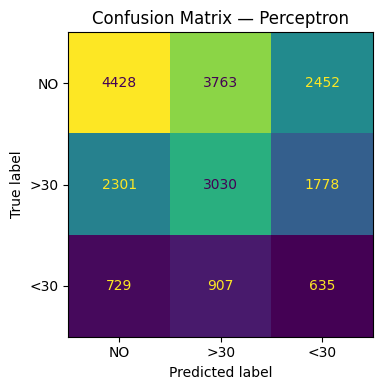


  SUMMARY
     Model  Accuracy  F1 NO  F1 >30  F1 <30  F1 macro
Perceptron     0.404  0.489   0.409   0.178     0.359


,Model,Accuracy,F1 NO,F1 >30,F1 <30,F1 macro
0,Perceptron,0.404,0.489,0.409,0.178,0.359


In [ ]:
evaluate_models(all_models, X_test, y_test)

### Commento Risultati

Il Perceptron ottiene un F1 macro di circa 0.359 sul test (0.365 ± 0.017 in CV), con i due valori quasi coincidenti: nessun overfitting, semmai underfitting strutturale dovuto alla linearità del modello. Grazie a class_weight="balanced" non ignora le classi minoritarie, ma l'accuracy scende al 40% come effetto collaterale. La classe <30, la più rilevante clinicamente, viene gestita molto male (F1 ~0.178, precisione 0.13): il confine lineare non è sufficiente a separarla in modo affidabile nel feature space.

## Logistic Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_regression = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="saga",
        random_state=42,
        tol=1e-3
    ))
])

In [ ]:
param_grid_lr = [
    {
        "model__penalty": ["l2", "l1"],
        "model__C":       [0.001, 0.01, 0.05, 0.1, 1],
        "model__solver":  ["saga"]
    },
    {
        "model__penalty":   ["elasticnet"],
        "model__C":         [0.001, 0.01, 0.05, 0.1, 1],
        "model__solver":    ["saga"],
        "model__l1_ratio":  [0.2, 0.5, 0.8]
    }
]

inner_search_lr = GridSearchCV(
    logistic_regression,
    param_grid_lr,
    cv=inner_cv,
    scoring="f1_macro",
    n_jobs=-1
)

scores_lr = cross_val_score(
    inner_search_lr,
    X_train, y_train,
    cv=outer_cv,
    scoring="f1_macro",
    n_jobs=1
)

In [ ]:
print(f"Logistic Regression — F1 macro: {scores_lr.mean():.3f} ± {scores_lr.std():.3f}")
cv_results.append({
    "model":    "Logistic Regression",
    "f1_mean":  round(scores_lr.mean(), 3),
    "f1_std":   round(scores_lr.std(),  3),
    "scores":   scores_lr.tolist()
})

Logistic Regression — F1 macro: 0.438 ± 0.004


In [ ]:
inner_search_lr.fit(X_train, y_train)
print(inner_search_lr.best_params_)

{'model__C': 0.05, 'model__l1_ratio': 0.5, 'model__penalty': 'elasticnet', 'model__solver': 'saga'}


In [ ]:
lr_model = inner_search_lr.best_estimator_.named_steps["model"]

coef_df = pd.DataFrame(
    lr_model.coef_,
    columns=X_train.columns,
    index=["NO", ">30", "<30"]
)

print(coef_df.loc["<30"].abs().sort_values(ascending=False).head(30))

number_inpatient            0.216163
discharge_disposition_22    0.129604
total_prior_visits          0.103519
discharge_disposition_3     0.102857
discharge_disposition_5     0.077602
discharge_disposition_2     0.059372
diag1_Respiratory           0.058287
number_diagnoses            0.052956
insulin_No                  0.050979
discharge_disposition_18    0.050783
procedures_per_day          0.048643
number_outpatient           0.048349
age_midpoint                0.043987
discharge_disposition_28    0.041070
diag2_Neoplasms             0.040669
number_emergency            0.039706
diabetesMed                 0.037539
diag1_Musculoskeletal       0.037216
discharge_disposition_6     0.037126
discharge_disposition_15    0.036435
diag2_Diabetes              0.033578
insulin_Steady              0.033341
metformin                   0.031353
diag3_Diabetes              0.031332
admission_type_3            0.028014
discharge_disposition_9     0.027856
diag3_Genitourinary         0.025766
d

In [ ]:
all_models.append({"name": "Logistic Regression", "model": inner_search_lr})
save_model_to_drive("Logistic Regression", inner_search_lr)

Successfully saved Logistic Regression to /content/drive/MyDrive/Colab_Models/diabetes_readmission_models/logistic_regression.pkl


  Perceptron

Accuracy: 0.404

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         4428  3763  2452
>30        2301  3030  1778
<30         729   907   635

Classification report:
              precision    recall  f1-score   support

          NO       0.59      0.42      0.49     10643
         >30       0.39      0.43      0.41      7109
         <30       0.13      0.28      0.18      2271

    accuracy                           0.40     20023
   macro avg       0.37      0.37      0.36     20023
weighted avg       0.47      0.40      0.43     20023

F1 per class:  NO=0.489  >30=0.409  <30=0.178
F1 macro:      0.359


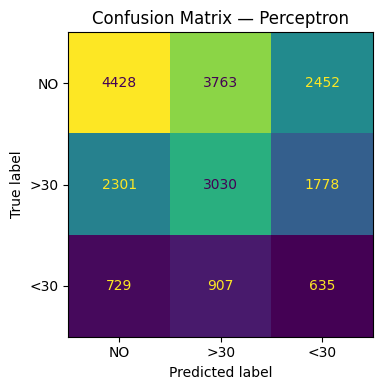

  Logistic Regression

Accuracy: 0.502

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6455  2397  1791
>30        2630  2679  1800
<30         716   647   908

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.61      0.63     10643
         >30       0.47      0.38      0.42      7109
         <30       0.20      0.40      0.27      2271

    accuracy                           0.50     20023
   macro avg       0.44      0.46      0.44     20023
weighted avg       0.54      0.50      0.51     20023

F1 per class:  NO=0.631  >30=0.418  <30=0.268
F1 macro:      0.439


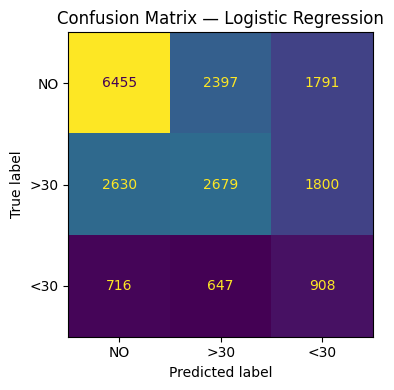


  SUMMARY
              Model  Accuracy  F1 NO  F1 >30  F1 <30  F1 macro
Logistic Regression     0.502  0.631   0.418   0.268     0.439
         Perceptron     0.404  0.489   0.409   0.178     0.359


,Model,Accuracy,F1 NO,F1 >30,F1 <30,F1 macro
0,Logistic Regression,0.502,0.631,0.418,0.268,0.439
1,Perceptron,0.404,0.489,0.409,0.178,0.359


In [ ]:
evaluate_models(all_models, X_test, y_test)

### Commento Risultati
La Regressione Logistica rappresenta un passo avanti rispetto al Perceptron pur restando un modello lineare: l'ottimizzazione su penalità (L1, L2, ElasticNet) e sul parametro C permette un miglior controllo della regolarizzazione. Con class_weight="balanced" e solver SAGA, il modello riesce a dare qualche segnale sulla classe <30, ma i limiti della linearità restano evidenti. L'F1 macro in CV è modesto e comparabile al Perceptron; il vantaggio principale è l'interpretabilità diretta tramite i coefficienti, utile per capire quali feature pesano di più sulla predizione di ogni classe.

## Logistic Regression con SMOTE

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline

lr_SMOTE = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    ))
])

In [ ]:
param_grid_lr = {
    "model__C": [0.001, 0.01, 0.02, 0.05, 0.1, 0.2, 1]
}

inner_search_lr_SMOTE = GridSearchCV(
    lr_SMOTE,
    param_grid_lr,
    cv=inner_cv,
    scoring="f1_macro",
    n_jobs=-1
)

scores_lr_SMOTE = cross_val_score(
    inner_search_lr_SMOTE,
    X_train, y_train,
    cv=outer_cv,
    scoring="f1_macro",
    n_jobs=1
)

In [ ]:
print(f"Logistic Regression SMOTE — F1 macro: {scores_lr_SMOTE.mean():.3f} ± {scores_lr_SMOTE.std():.3f}")

cv_results.append({
    "model":    "Logistic Regression SMOTE",
    "f1_mean":  round(scores_lr_SMOTE.mean(), 3),
    "f1_std":   round(scores_lr_SMOTE.std(),  3),
    "scores":   scores_lr_SMOTE.tolist()
})

Logistic Regression SMOTE — F1 macro: 0.430 ± 0.003


In [ ]:
inner_search_lr_SMOTE.fit(X_train, y_train)
print(inner_search_lr_SMOTE.best_params_)

{'model__C': 0.001}


In [ ]:
lr_model_SMOTE = inner_search_lr_SMOTE.best_estimator_.named_steps["model"]

coef_df = pd.DataFrame(
    lr_model_SMOTE.coef_,
    columns=X_train.columns,
    index=["NO", ">30", "<30"]
)

print(coef_df.loc["<30"].abs().sort_values(ascending=False).head(30))

number_inpatient            0.228273
discharge_disposition_22    0.118104
total_prior_visits          0.104439
discharge_disposition_3     0.093168
diag1_Respiratory           0.091831
procedures_per_day          0.080411
discharge_disposition_5     0.075003
number_outpatient           0.063344
diag1_Other                 0.058629
diag1_Musculoskeletal       0.057762
metformin                   0.055719
diag1_Injury                0.054696
insulin_No                  0.053255
diag1_Digestive             0.052299
polypharmacy                0.051194
number_diagnoses            0.049072
diag1_Genitourinary         0.047618
insulin_Steady              0.045562
diabetesMed                 0.044292
discharge_disposition_2     0.042606
age_midpoint                0.041948
discharge_disposition_28    0.040074
diag2_Respiratory           0.038999
admission_type_2            0.038805
admission_type_3            0.036740
discharge_disposition_18    0.036488
diag2_Genitourinary         0.035957
a

In [ ]:
all_models.append({"name": "Logistic Regression SMOTE", "model": inner_search_lr_SMOTE})
save_model_to_drive("Logistic Regression SMOTE", inner_search_lr_SMOTE)

Successfully saved Logistic Regression SMOTE to /content/drive/MyDrive/Colab_Models/diabetes_readmission_models/lr_plus_smote.pkl


  Perceptron

Accuracy: 0.404

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         4428  3763  2452
>30        2301  3030  1778
<30         729   907   635

Classification report:
              precision    recall  f1-score   support

          NO       0.59      0.42      0.49     10643
         >30       0.39      0.43      0.41      7109
         <30       0.13      0.28      0.18      2271

    accuracy                           0.40     20023
   macro avg       0.37      0.37      0.36     20023
weighted avg       0.47      0.40      0.43     20023

F1 per class:  NO=0.489  >30=0.409  <30=0.178
F1 macro:      0.359


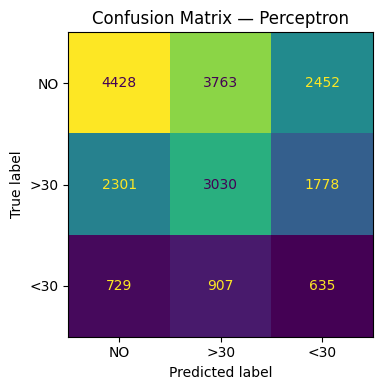

  Logistic Regression

Accuracy: 0.502

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6455  2397  1791
>30        2630  2679  1800
<30         716   647   908

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.61      0.63     10643
         >30       0.47      0.38      0.42      7109
         <30       0.20      0.40      0.27      2271

    accuracy                           0.50     20023
   macro avg       0.44      0.46      0.44     20023
weighted avg       0.54      0.50      0.51     20023

F1 per class:  NO=0.631  >30=0.418  <30=0.268
F1 macro:      0.439


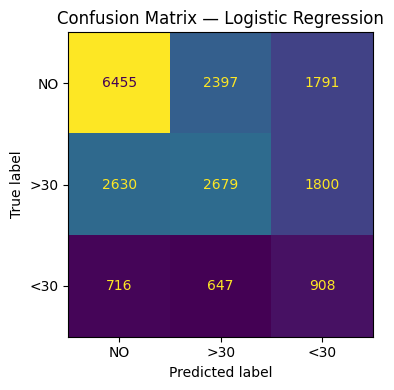

  Logistic Regression SMOTE

Accuracy: 0.494

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6383  2404  1856
>30        2594  2618  1897
<30         723   648   900

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.60      0.63     10643
         >30       0.46      0.37      0.41      7109
         <30       0.19      0.40      0.26      2271

    accuracy                           0.49     20023
   macro avg       0.44      0.45      0.43     20023
weighted avg       0.54      0.49      0.51     20023

F1 per class:  NO=0.628  >30=0.410  <30=0.260
F1 macro:      0.432


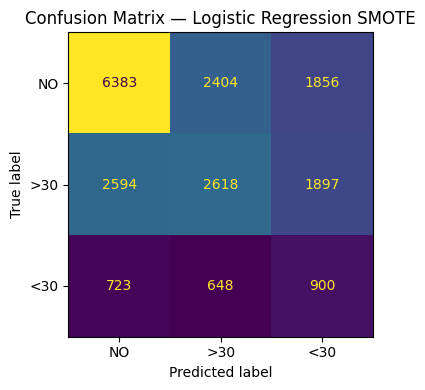


  SUMMARY
                    Model  Accuracy  F1 NO  F1 >30  F1 <30  F1 macro
      Logistic Regression     0.502  0.631   0.418   0.268     0.439
Logistic Regression SMOTE     0.494  0.628   0.410   0.260     0.432
               Perceptron     0.404  0.489   0.409   0.178     0.359


,Model,Accuracy,F1 NO,F1 >30,F1 <30,F1 macro
0,Logistic Regression,0.502,0.631,0.418,0.268,0.439
1,Logistic Regression SMOTE,0.494,0.628,0.410,0.260,0.432
2,Perceptron,0.404,0.489,0.409,0.178,0.359


In [ ]:
evaluate_models(all_models, X_test, y_test)

### Commento Risultati
L'aggiunta di SMOTE nella pipeline (con oversampling applicato solo sul train interno ad ogni fold) punta a migliorare la sensibilità sulla classe minoritaria <30 generando campioni sintetici. I risultati in CV mostrano un effetto limitato rispetto alla versione con class_weight: il problema non è la quantità di esempi ma la difficoltà intrinseca di separare le classi con un modello lineare. L'F1 macro rimane su livelli simili alla versione base, a conferma che lo SMOTE da solo non colma il gap di capacità espressiva del modello.

## SVM: Support Vector Machines

In [ ]:
from sklearn.svm import LinearSVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearSVC(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

In [ ]:
param_grid_svm = {"model__C": [0.01, 0.1, 1, 10]}

inner_search_svm = GridSearchCV(
    svm_model,
    param_grid_svm,
    cv=inner_cv,
    scoring="f1_macro",
    n_jobs=-1
)

scores_svm = cross_val_score(
    inner_search_svm,
    X_train, y_train,
    cv=outer_cv,
    scoring="f1_macro",
    n_jobs=1
)

In [ ]:
print(f"Linear SVM — F1 macro: {scores_svm.mean():.3f} ± {scores_svm.std():.3f}")

cv_results.append({
    "model":    "Linear SVM",
    "f1_mean":  round(scores_svm.mean(), 3),
    "f1_std":   round(scores_svm.std(),  3),
    "scores":   scores_svm.tolist()
})

Linear SVM — F1 macro: 0.438 ± 0.004


In [ ]:
inner_search_svm.fit(X_train, y_train)
print(inner_search_svm.best_params_)

{'model__C': 1}


In [ ]:
svm_model_best = inner_search_svm.best_estimator_.named_steps["model"]

coef_df_svm = pd.DataFrame(
    svm_model_best.coef_,
    columns=X_train.columns,
    index=["NO", ">30", "<30"]
)

for cls in ["NO", ">30", "<30"]:
    print(f"\n--- Top 15 features per classe {cls} ---")
    print(coef_df_svm.loc[cls].abs().sort_values(ascending=False).head(15))


--- Top 15 features per classe NO ---
number_inpatient            0.151279
total_prior_visits          0.106113
number_diagnoses            0.084849
discharge_disposition_14    0.062421
admission_type_6            0.062353
diabetesMed                 0.059487
discharge_disposition_13    0.052384
admission_source_4          0.049513
number_emergency            0.045806
high_utilizer               0.041964
admission_source_6          0.038149
polypharmacy                0.036986
metformin                   0.032632
admission_source_17         0.031528
insulin_Steady              0.030840
Name: NO, dtype: float64

--- Top 15 features per classe >30 ---
number_diagnoses            0.062482
admission_type_6            0.061252
number_inpatient            0.059058
total_prior_visits          0.052499
discharge_disposition_14    0.051168
diabetesMed                 0.045549
admission_source_4          0.040724
discharge_disposition_13    0.036293
admission_source_7          0.035512
polyphar

In [ ]:
all_models.append({"name": "Linear SVM", "model": inner_search_svm})
save_model_to_drive("Linear SVM", inner_search_svm)

Successfully saved Linear SVM to /content/drive/MyDrive/Colab_Models/diabetes_readmission_models/linear_svm.pkl


  Perceptron

Accuracy: 0.404

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         4428  3763  2452
>30        2301  3030  1778
<30         729   907   635

Classification report:
              precision    recall  f1-score   support

          NO       0.59      0.42      0.49     10643
         >30       0.39      0.43      0.41      7109
         <30       0.13      0.28      0.18      2271

    accuracy                           0.40     20023
   macro avg       0.37      0.37      0.36     20023
weighted avg       0.47      0.40      0.43     20023

F1 per class:  NO=0.489  >30=0.409  <30=0.178
F1 macro:      0.359


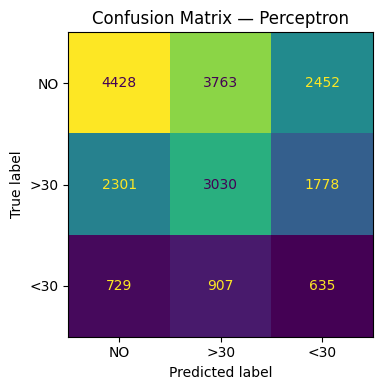

  Logistic Regression

Accuracy: 0.502

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6455  2397  1791
>30        2630  2679  1800
<30         716   647   908

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.61      0.63     10643
         >30       0.47      0.38      0.42      7109
         <30       0.20      0.40      0.27      2271

    accuracy                           0.50     20023
   macro avg       0.44      0.46      0.44     20023
weighted avg       0.54      0.50      0.51     20023

F1 per class:  NO=0.631  >30=0.418  <30=0.268
F1 macro:      0.439


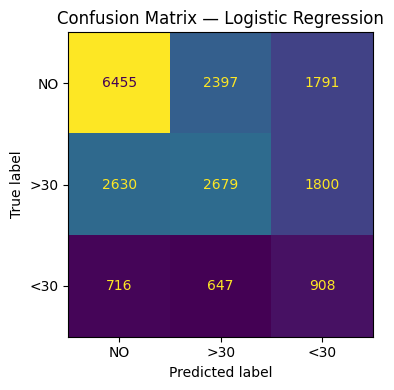

  Logistic Regression SMOTE

Accuracy: 0.494

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6383  2404  1856
>30        2594  2618  1897
<30         723   648   900

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.60      0.63     10643
         >30       0.46      0.37      0.41      7109
         <30       0.19      0.40      0.26      2271

    accuracy                           0.49     20023
   macro avg       0.44      0.45      0.43     20023
weighted avg       0.54      0.49      0.51     20023

F1 per class:  NO=0.628  >30=0.410  <30=0.260
F1 macro:      0.432


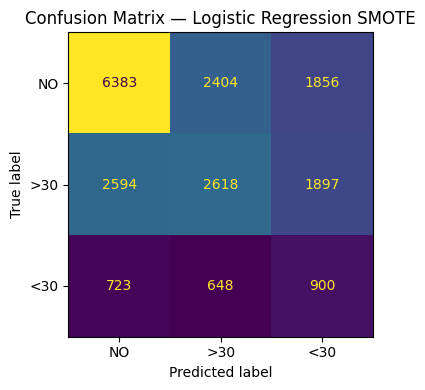

  Linear SVM

Accuracy: 0.562

Confusion matrix:
Predicted    NO   >30  <30
Actual                    
NO         8196  1930  517
>30        3874  2681  554
<30        1097   799  375

Classification report:
              precision    recall  f1-score   support

          NO       0.62      0.77      0.69     10643
         >30       0.50      0.38      0.43      7109
         <30       0.26      0.17      0.20      2271

    accuracy                           0.56     20023
   macro avg       0.46      0.44      0.44     20023
weighted avg       0.54      0.56      0.54     20023

F1 per class:  NO=0.688  >30=0.428  <30=0.202
F1 macro:      0.440


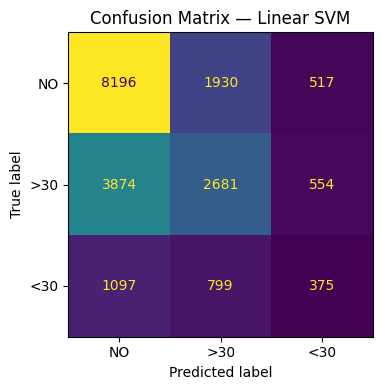


  SUMMARY
                    Model  Accuracy  F1 NO  F1 >30  F1 <30  F1 macro
               Linear SVM     0.562  0.688   0.428   0.202     0.440
      Logistic Regression     0.502  0.631   0.418   0.268     0.439
Logistic Regression SMOTE     0.494  0.628   0.410   0.260     0.432
               Perceptron     0.404  0.489   0.409   0.178     0.359


,Model,Accuracy,F1 NO,F1 >30,F1 <30,F1 macro
0,Linear SVM,0.562,0.688,0.428,0.202,0.440
1,Logistic Regression,0.502,0.631,0.418,0.268,0.439
2,Logistic Regression SMOTE,0.494,0.628,0.410,0.260,0.432
3,Perceptron,0.404,0.489,0.409,0.178,0.359


In [ ]:
evaluate_models(all_models, X_test, y_test)

### Commento Risultati
Il Linear SVM con class_weight="balanced" e regularizzazione ottimizzata su C condivide la stessa frontiera lineare della regressione logistica, ma è generalmente più robusto nei dataset ad alta dimensionalità. Le performance in CV risultano analoghe a quelle della Logistic Regression, con F1 macro simile e stessa difficoltà sulla classe <30. L'analisi dei coefficienti per classe mostra quali feature incidono maggiormente sulla discriminazione, offrendo un'interpretabilità paragonabile al modello lineare.

## SVM: Support Vector Machines con SMOTE

In [ ]:
svm_smote = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LinearSVC(
        max_iter=5000,
        random_state=42
    ))
])

In [ ]:
param_grid_svm = {"model__C": [0.01, 0.1, 1, 10]}

inner_search_svm_smote = GridSearchCV(
    svm_smote,
    param_grid_svm,
    cv=inner_cv,
    scoring="f1_macro",
    n_jobs=-1
)

scores_svm_smote = cross_val_score(
    inner_search_svm_smote,
    X_train, y_train,
    cv=outer_cv,
    scoring="f1_macro",
    n_jobs=1
)

In [ ]:
print(f"Linear SVM SMOTE — F1 macro: {scores_svm_smote.mean():.3f} ± {scores_svm_smote.std():.3f}")

cv_results.append({
    "model":    "Linear SVM SMOTE",
    "f1_mean":  round(scores_svm_smote.mean(), 3),
    "f1_std":   round(scores_svm_smote.std(),  3),
    "scores":   scores_svm_smote.tolist()
})

Linear SVM SMOTE — F1 macro: 0.424 ± 0.003


In [ ]:
inner_search_svm_smote.fit(X_train, y_train)
print(inner_search_svm_smote.best_params_)

{'model__C': 0.01}


In [ ]:
svm_smote_model_best = inner_search_svm_smote.best_estimator_.named_steps["model"]

coef_df_svm_smote = pd.DataFrame(
    svm_smote_model_best.coef_,
    columns=X_train.columns,
    index=["NO", ">30", "<30"]
)

for cls in ["NO", ">30", "<30"]:
    print(f"\n--- Top 15 features per classe {cls} (SVM+SMOTE) ---")
    print(coef_df_svm_smote.loc[cls].abs().sort_values(ascending=False).head(15))


--- Top 15 features per classe NO (SVM+SMOTE) ---
number_inpatient            0.157718
total_prior_visits          0.101603
number_diagnoses            0.085362
diabetesMed                 0.060329
discharge_disposition_14    0.056580
discharge_disposition_13    0.053856
polypharmacy                0.053238
high_utilizer               0.051574
admission_type_6            0.045605
metformin                   0.044500
number_emergency            0.040824
admission_source_4          0.040302
procedures_per_day          0.039355
insulin_Steady              0.037280
discharge_disposition_12    0.036860
Name: NO, dtype: float64

--- Top 15 features per classe >30 (SVM+SMOTE) ---
admission_type_6            0.057341
number_diagnoses            0.052950
discharge_disposition_3     0.051842
discharge_disposition_22    0.048678
discharge_disposition_14    0.046468
number_outpatient           0.040735
admission_source_7          0.035680
discharge_disposition_12    0.035654
admission_type_5     

In [ ]:
all_models.append({"name": "Linear SVM SMOTE", "model": inner_search_svm_smote})
save_model_to_drive("Linear SVM SMOTE", inner_search_svm_smote)

Successfully saved Linear SVM SMOTE to /content/drive/MyDrive/Colab_Models/diabetes_readmission_models/svm_plus_smote.pkl


  Perceptron

Accuracy: 0.404

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         4428  3763  2452
>30        2301  3030  1778
<30         729   907   635

Classification report:
              precision    recall  f1-score   support

          NO       0.59      0.42      0.49     10643
         >30       0.39      0.43      0.41      7109
         <30       0.13      0.28      0.18      2271

    accuracy                           0.40     20023
   macro avg       0.37      0.37      0.36     20023
weighted avg       0.47      0.40      0.43     20023

F1 per class:  NO=0.489  >30=0.409  <30=0.178
F1 macro:      0.359


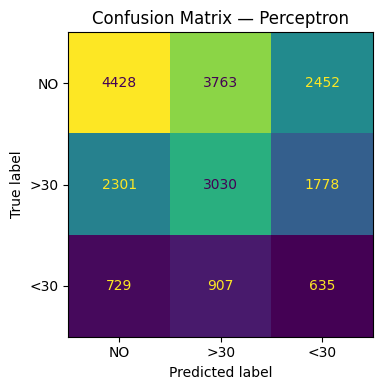

  Logistic Regression

Accuracy: 0.502

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6455  2397  1791
>30        2630  2679  1800
<30         716   647   908

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.61      0.63     10643
         >30       0.47      0.38      0.42      7109
         <30       0.20      0.40      0.27      2271

    accuracy                           0.50     20023
   macro avg       0.44      0.46      0.44     20023
weighted avg       0.54      0.50      0.51     20023

F1 per class:  NO=0.631  >30=0.418  <30=0.268
F1 macro:      0.439


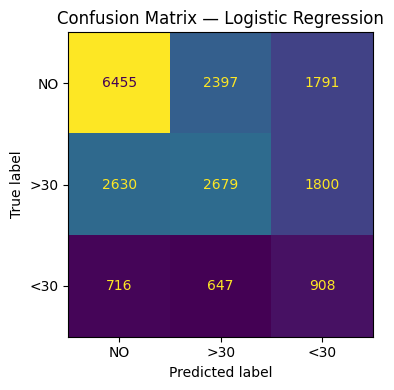

  Logistic Regression SMOTE

Accuracy: 0.494

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6383  2404  1856
>30        2594  2618  1897
<30         723   648   900

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.60      0.63     10643
         >30       0.46      0.37      0.41      7109
         <30       0.19      0.40      0.26      2271

    accuracy                           0.49     20023
   macro avg       0.44      0.45      0.43     20023
weighted avg       0.54      0.49      0.51     20023

F1 per class:  NO=0.628  >30=0.410  <30=0.260
F1 macro:      0.432


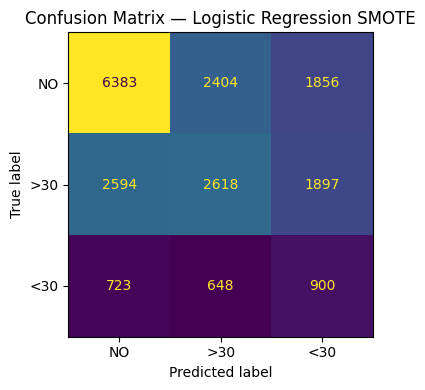

  Linear SVM

Accuracy: 0.562

Confusion matrix:
Predicted    NO   >30  <30
Actual                    
NO         8196  1930  517
>30        3874  2681  554
<30        1097   799  375

Classification report:
              precision    recall  f1-score   support

          NO       0.62      0.77      0.69     10643
         >30       0.50      0.38      0.43      7109
         <30       0.26      0.17      0.20      2271

    accuracy                           0.56     20023
   macro avg       0.46      0.44      0.44     20023
weighted avg       0.54      0.56      0.54     20023

F1 per class:  NO=0.688  >30=0.428  <30=0.202
F1 macro:      0.440


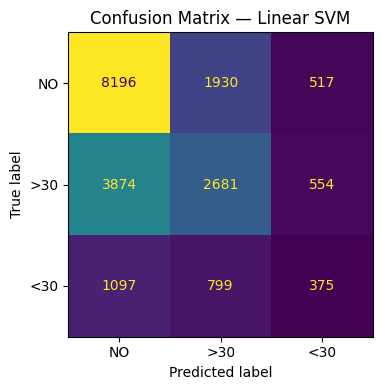

  Linear SVM SMOTE

Accuracy: 0.487

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6349  2342  1952
>30        2638  2445  2026
<30         734   574   963

Classification report:
              precision    recall  f1-score   support

          NO       0.65      0.60      0.62     10643
         >30       0.46      0.34      0.39      7109
         <30       0.19      0.42      0.27      2271

    accuracy                           0.49     20023
   macro avg       0.43      0.45      0.43     20023
weighted avg       0.53      0.49      0.50     20023

F1 per class:  NO=0.624  >30=0.392  <30=0.267
F1 macro:      0.428


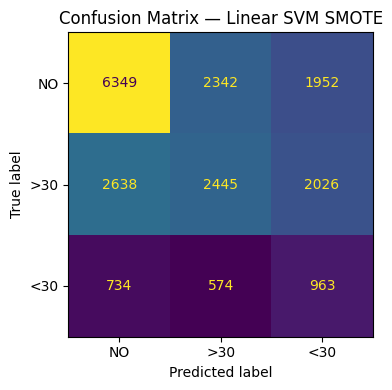


  SUMMARY
                    Model  Accuracy  F1 NO  F1 >30  F1 <30  F1 macro
               Linear SVM     0.562  0.688   0.428   0.202     0.440
      Logistic Regression     0.502  0.631   0.418   0.268     0.439
Logistic Regression SMOTE     0.494  0.628   0.410   0.260     0.432
         Linear SVM SMOTE     0.487  0.624   0.392   0.267     0.428
               Perceptron     0.404  0.489   0.409   0.178     0.359


,Model,Accuracy,F1 NO,F1 >30,F1 <30,F1 macro
0,Linear SVM,0.562,0.688,0.428,0.202,0.440
1,Logistic Regression,0.502,0.631,0.418,0.268,0.439
2,Logistic Regression SMOTE,0.494,0.628,0.410,0.260,0.432
3,Linear SVM SMOTE,0.487,0.624,0.392,0.267,0.428
4,Perceptron,0.404,0.489,0.409,0.178,0.359


In [ ]:
evaluate_models(all_models, X_test, y_test)

### Commento Risultati
Come per la Logistic Regression, l'abbinamento con SMOTE non porta a un guadagno significativo in F1 macro rispetto alla versione con class_weight. La generazione di campioni sintetici bilancia la distribuzione sul training set interno, ma la superficie di separazione rimane lineare e non riesce a catturare le strutture non lineari che distinguono la riammissione precoce. I risultati in CV sono stabili tra i fold, il che indica assenza di overfitting, ma anche un tetto prestazionale basso.

##Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=42
)

In [ ]:

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import GridSearchCV, cross_val_score

decision_tree = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

param_grid_dt = {
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [50, 100, 150],
    "criterion": ["gini", "entropy"]
}

inner_search_dt = GridSearchCV(
    decision_tree, param_grid_dt,
    cv=inner_cv, scoring="f1_macro", n_jobs=-1
)

scores_dt = cross_val_score(
    inner_search_dt, X_train, y_train,
    cv=outer_cv, scoring="f1_macro", n_jobs=1
)

In [ ]:
print(f"Decision Tree — F1 macro: {scores_dt.mean():.3f} ± {scores_dt.std():.3f}")

cv_results.append({
    "model":    "Decision Tree",
    "f1_mean":  round(scores_dt.mean(), 3),
    "f1_std":   round(scores_dt.std(),  3),
    "scores":   scores_dt.tolist()
})

Decision Tree — F1 macro: 0.426 ± 0.005


In [ ]:
inner_search_dt.fit(X_train, y_train)
print(f"Migliori parametri: {inner_search_dt.best_params_}")

Migliori parametri: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 50}


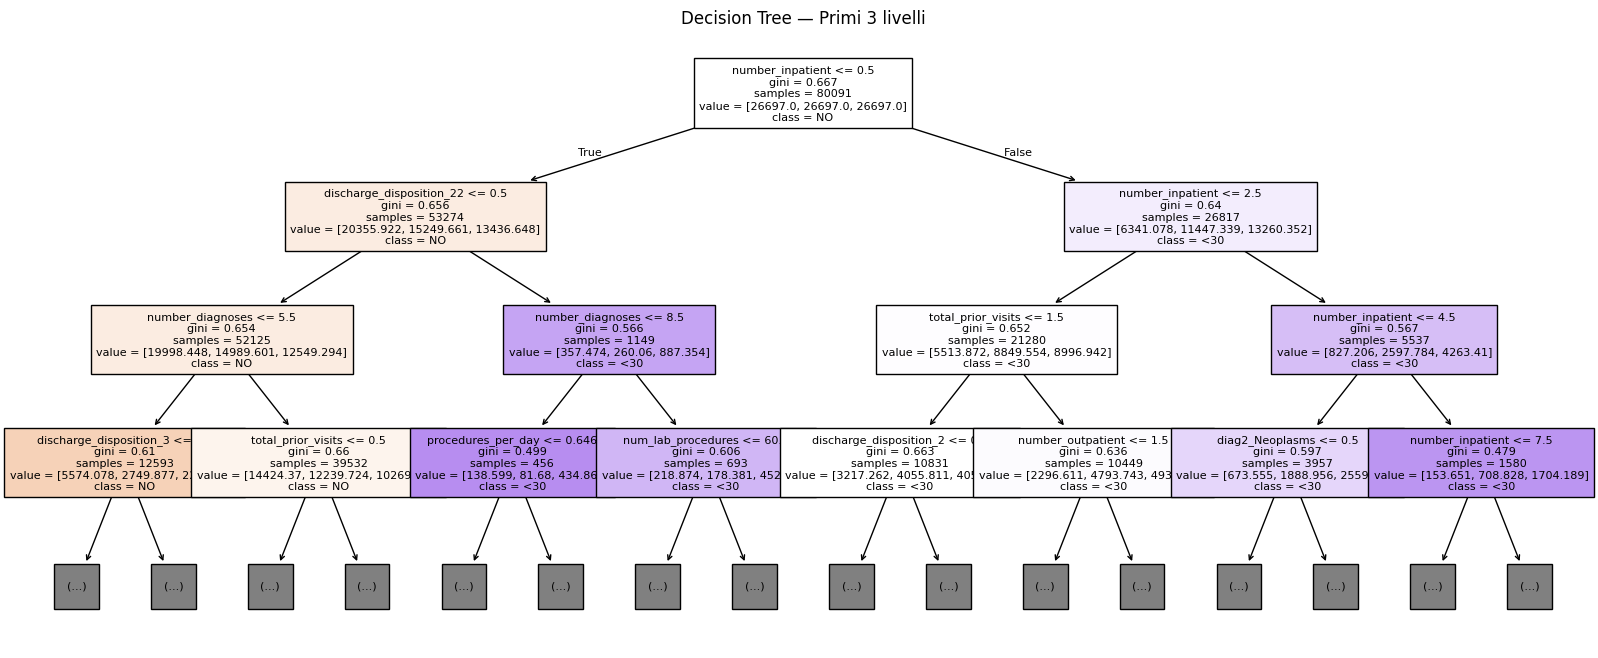

In [ ]:
best_dt = inner_search_dt.best_estimator_
plt.figure(figsize=(20, 8))
plot_tree(best_dt, feature_names=list(X_train.columns),
          class_names=CLASS_NAMES,
          max_depth=3, filled=True, fontsize=8)
plt.title("Decision Tree — Primi 3 livelli")
plt.show()

In [ ]:
all_models.append({"name": "Decision Tree", "model": inner_search_dt})
save_model_to_drive("Decision Tree", inner_search_dt)

Successfully saved Decision Tree to /content/drive/MyDrive/Colab_Models/diabetes_readmission_models/decision_tree.pkl


  Decision Tree

Accuracy: 0.480

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6745  1908  1990
>30        3062  1919  2128
<30         782   536   953

Classification report:
              precision    recall  f1-score   support

          NO       0.64      0.63      0.64     10643
         >30       0.44      0.27      0.33      7109
         <30       0.19      0.42      0.26      2271

    accuracy                           0.48     20023
   macro avg       0.42      0.44      0.41     20023
weighted avg       0.52      0.48      0.49     20023

F1 per class:  NO=0.635  >30=0.335  <30=0.260
F1 macro:      0.410


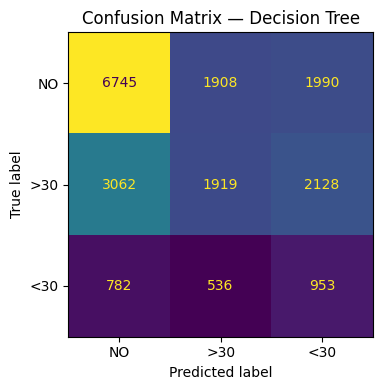


  SUMMARY
        Model  Accuracy  F1 NO  F1 >30  F1 <30  F1 macro
Decision Tree      0.48  0.635   0.335    0.26      0.41


,Model,Accuracy,F1 NO,F1 >30,F1 <30,F1 macro
0,Decision Tree,0.48,0.635,0.335,0.26,0.41


In [ ]:
evaluate_models([{"name": "Decision Tree", "model": inner_search_dt}], X_test, y_test)

### Commento Risultati
Il Decision Tree introduce la non-linearità attraverso regole di split successive, permettendo di isolare sottogruppi di pazienti a rischio elevato di riammissione precoce. In cross-validation l'F1 macro migliora rispetto ai modelli lineari, e l'analisi dei primi livelli dell'albero mostra che le feature più rilevanti sono il numero di ricoveri precedenti e la durata della degenza. Il rischio di overfitting è contenuto grazie ai vincoli sulla profondità massima e sul numero minimo di campioni per foglia, anche se un singolo albero rimane comunque un modello più instabile rispetto alle soluzioni più complesse.


##Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=50,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=1
)

In [ ]:
param_dist_rf = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [8, 12, 16, None],
    "min_samples_leaf": [30, 50, 100]
}

inner_search_rf = RandomizedSearchCV(
    random_forest, param_dist_rf,
    n_iter=10, cv=inner_cv,
    scoring="f1_macro", random_state=42, n_jobs=-1
)

scores_rf = cross_val_score(
    inner_search_rf, X_train, y_train,
    cv=outer_cv, scoring="f1_macro", n_jobs=1
)

In [ ]:
print(f"Random Forest — F1 macro: {scores_rf.mean():.3f} ± {scores_rf.std():.3f}")

cv_results.append({
    "model":    "Random Forest",
    "f1_mean":  round(scores_rf.mean(), 3),
    "f1_std":   round(scores_rf.std(),  3),
    "scores":   scores_rf.tolist()
})

Random Forest — F1 macro: 0.431 ± 0.002


In [ ]:
inner_search_rf.fit(X_train, y_train)
print(inner_search_rf.best_params_)

{'n_estimators': 200, 'min_samples_leaf': 50, 'max_depth': None}


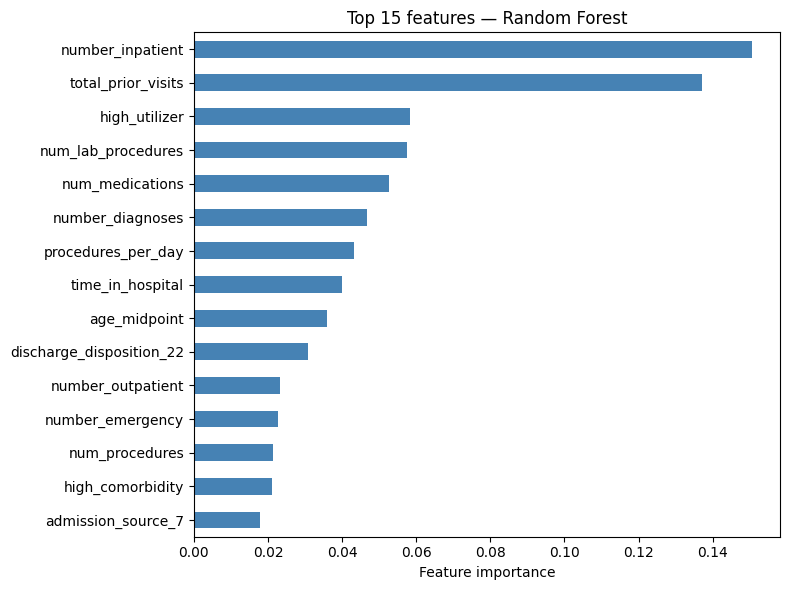

In [ ]:
# Feature importance
rf_model = inner_search_rf.best_estimator_
pd.Series(rf_model.feature_importances_, index=X_train.columns)\
  .sort_values(ascending=False).head(15)\
  .sort_values().plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Top 15 features — Random Forest")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

In [ ]:
all_models.append({"name": "Random Forest", "model": inner_search_rf})
save_model_to_drive("Random Forest", inner_search_rf)

Successfully saved Random Forest to /content/drive/MyDrive/Colab_Models/diabetes_readmission_models/random_forest.pkl


  Perceptron

Accuracy: 0.404

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         4428  3763  2452
>30        2301  3030  1778
<30         729   907   635

Classification report:
              precision    recall  f1-score   support

          NO       0.59      0.42      0.49     10643
         >30       0.39      0.43      0.41      7109
         <30       0.13      0.28      0.18      2271

    accuracy                           0.40     20023
   macro avg       0.37      0.37      0.36     20023
weighted avg       0.47      0.40      0.43     20023

F1 per class:  NO=0.489  >30=0.409  <30=0.178
F1 macro:      0.359


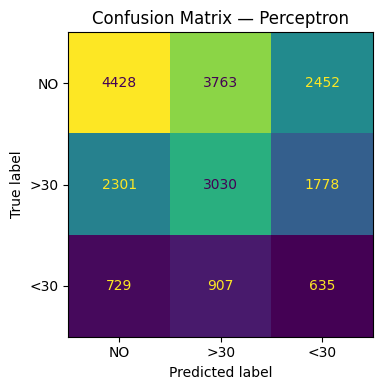

  Logistic Regression

Accuracy: 0.502

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6455  2397  1791
>30        2630  2679  1800
<30         716   647   908

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.61      0.63     10643
         >30       0.47      0.38      0.42      7109
         <30       0.20      0.40      0.27      2271

    accuracy                           0.50     20023
   macro avg       0.44      0.46      0.44     20023
weighted avg       0.54      0.50      0.51     20023

F1 per class:  NO=0.631  >30=0.418  <30=0.268
F1 macro:      0.439


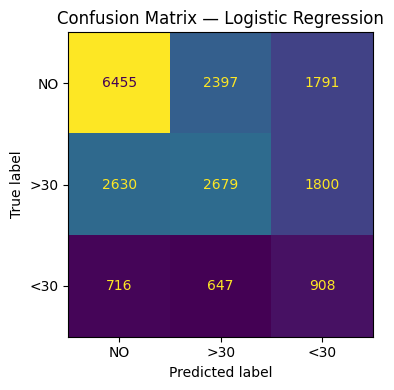

  Logistic Regression SMOTE

Accuracy: 0.494

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6383  2404  1856
>30        2594  2618  1897
<30         723   648   900

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.60      0.63     10643
         >30       0.46      0.37      0.41      7109
         <30       0.19      0.40      0.26      2271

    accuracy                           0.49     20023
   macro avg       0.44      0.45      0.43     20023
weighted avg       0.54      0.49      0.51     20023

F1 per class:  NO=0.628  >30=0.410  <30=0.260
F1 macro:      0.432


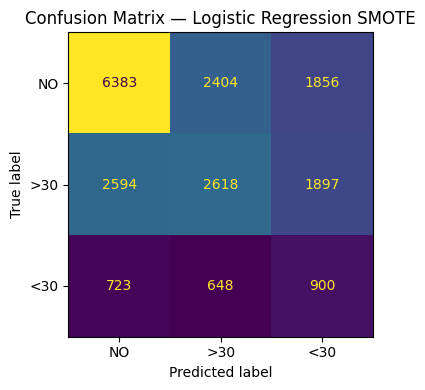

  Linear SVM

Accuracy: 0.562

Confusion matrix:
Predicted    NO   >30  <30
Actual                    
NO         8196  1930  517
>30        3874  2681  554
<30        1097   799  375

Classification report:
              precision    recall  f1-score   support

          NO       0.62      0.77      0.69     10643
         >30       0.50      0.38      0.43      7109
         <30       0.26      0.17      0.20      2271

    accuracy                           0.56     20023
   macro avg       0.46      0.44      0.44     20023
weighted avg       0.54      0.56      0.54     20023

F1 per class:  NO=0.688  >30=0.428  <30=0.202
F1 macro:      0.440


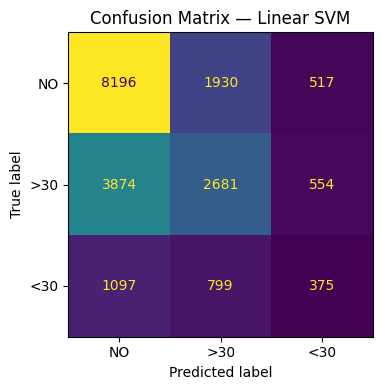

  Linear SVM SMOTE

Accuracy: 0.487

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6349  2342  1952
>30        2638  2445  2026
<30         734   574   963

Classification report:
              precision    recall  f1-score   support

          NO       0.65      0.60      0.62     10643
         >30       0.46      0.34      0.39      7109
         <30       0.19      0.42      0.27      2271

    accuracy                           0.49     20023
   macro avg       0.43      0.45      0.43     20023
weighted avg       0.53      0.49      0.50     20023

F1 per class:  NO=0.624  >30=0.392  <30=0.267
F1 macro:      0.428


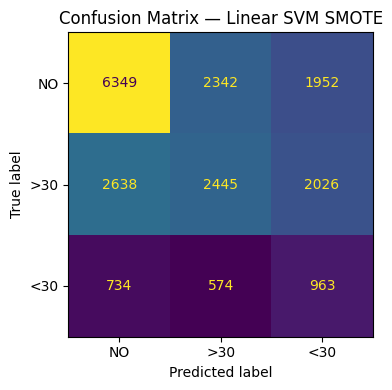

  Decision Tree

Accuracy: 0.480

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6745  1908  1990
>30        3062  1919  2128
<30         782   536   953

Classification report:
              precision    recall  f1-score   support

          NO       0.64      0.63      0.64     10643
         >30       0.44      0.27      0.33      7109
         <30       0.19      0.42      0.26      2271

    accuracy                           0.48     20023
   macro avg       0.42      0.44      0.41     20023
weighted avg       0.52      0.48      0.49     20023

F1 per class:  NO=0.635  >30=0.335  <30=0.260
F1 macro:      0.410


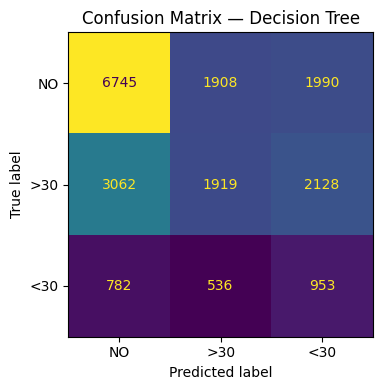

  Random Forest

Accuracy: 0.501

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6820  2238  1585
>30        2880  2353  1876
<30         791   623   857

Classification report:
              precision    recall  f1-score   support

          NO       0.65      0.64      0.65     10643
         >30       0.45      0.33      0.38      7109
         <30       0.20      0.38      0.26      2271

    accuracy                           0.50     20023
   macro avg       0.43      0.45      0.43     20023
weighted avg       0.53      0.50      0.51     20023

F1 per class:  NO=0.645  >30=0.382  <30=0.260
F1 macro:      0.429


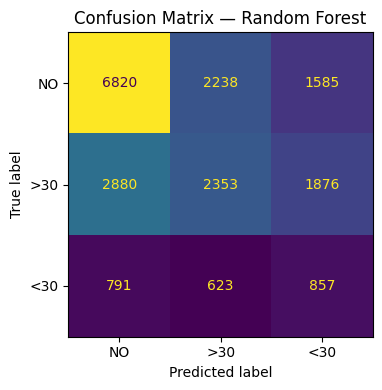


  SUMMARY
                    Model  Accuracy  F1 NO  F1 >30  F1 <30  F1 macro
               Linear SVM     0.562  0.688   0.428   0.202     0.440
      Logistic Regression     0.502  0.631   0.418   0.268     0.439
Logistic Regression SMOTE     0.494  0.628   0.410   0.260     0.432
            Random Forest     0.501  0.645   0.382   0.260     0.429
         Linear SVM SMOTE     0.487  0.624   0.392   0.267     0.428
            Decision Tree     0.480  0.635   0.335   0.260     0.410
               Perceptron     0.404  0.489   0.409   0.178     0.359


,Model,Accuracy,F1 NO,F1 >30,F1 <30,F1 macro
0,Linear SVM,0.562,0.688,0.428,0.202,0.440
1,Logistic Regression,0.502,0.631,0.418,0.268,0.439
2,Logistic Regression SMOTE,0.494,0.628,0.410,0.260,0.432
3,Random Forest,0.501,0.645,0.382,0.260,0.429
4,Linear SVM SMOTE,0.487,0.624,0.392,0.267,0.428
5,Decision Tree,0.480,0.635,0.335,0.260,0.410
6,Perceptron,0.404,0.489,0.409,0.178,0.359


In [ ]:
evaluate_models(all_models, X_test, y_test)

### Commento Risultati
La Random Forest combina centinaia di alberi decisionali addestrati su sottoinsiemi casuali dei dati, riducendo l'instabilità tipica del singolo albero. In CV l'F1 macro migliora rispetto al Decision Tree, con punteggi più stabili tra i fold. Le feature più importanti risultano essere i ricoveri precedenti, le visite di emergenza e la durata della degenza. La classe <30 rimane difficile da predire.

## XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

class BalancedXGB(XGBClassifier):
    def fit(self, X, y, **kwargs):
        sw = compute_sample_weight("balanced", y)
        return super().fit(X, y, sample_weight=sw, **kwargs)

xgboost_model = BalancedXGB(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    device="cpu",
    random_state=42,
    n_jobs=1,
)

In [ ]:
param_dist_xgb = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [3, 4, 6],
    "learning_rate":    [0.01, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
}

inner_search_xgb = RandomizedSearchCV(
    xgboost_model, param_dist_xgb,
    n_iter=20, cv=inner_cv,
    scoring="f1_macro", random_state=42, n_jobs=-1
)

scores_xgb = cross_val_score(
    inner_search_xgb, X_train, y_train,
    cv=outer_cv, scoring="f1_macro", n_jobs=1
)

In [ ]:
print(f"XGBoost — F1 macro: {scores_xgb.mean():.3f} ± {scores_xgb.std():.3f}")

cv_results.append({
    "model":    "XGBoost",
    "f1_mean":  round(scores_xgb.mean(), 3),
    "f1_std":   round(scores_xgb.std(),  3),
    "scores":   scores_xgb.tolist()
})

XGBoost — F1 macro: 0.449 ± 0.004


In [ ]:
inner_search_xgb.fit(X_train, y_train)
print(inner_search_xgb.best_params_)

{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


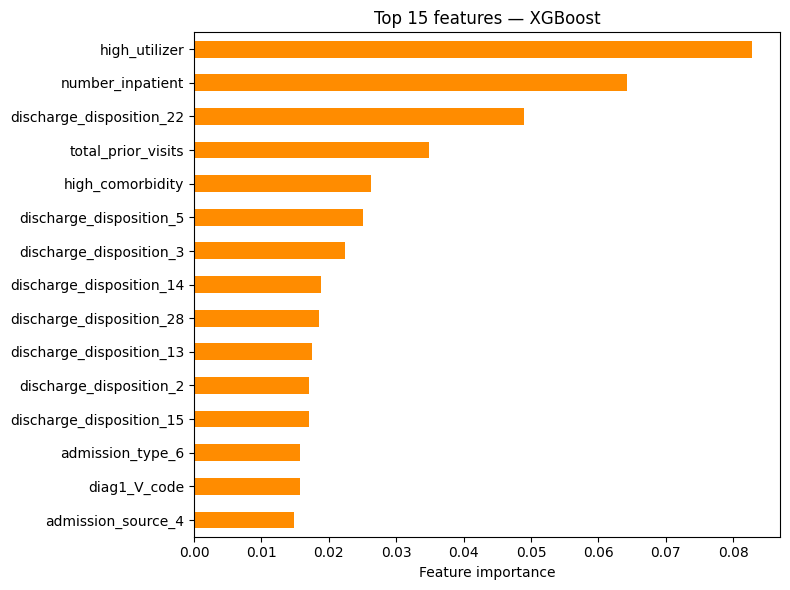

In [ ]:
xgb_model = inner_search_xgb.best_estimator_
pd.Series(xgb_model.feature_importances_, index=X_train.columns)\
  .sort_values(ascending=False).head(15)\
  .sort_values().plot(kind="barh", figsize=(8, 6), color="darkorange")
plt.title("Top 15 features — XGBoost")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

In [ ]:
all_models.append({"name": "XGBoost", "model": inner_search_xgb})
save_model_to_drive("XGBoost", inner_search_xgb)

Successfully saved XGBoost to /content/drive/MyDrive/Colab_Models/diabetes_readmission_models/xgboost.pkl


  Perceptron

Accuracy: 0.404

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         4428  3763  2452
>30        2301  3030  1778
<30         729   907   635

Classification report:
              precision    recall  f1-score   support

          NO       0.59      0.42      0.49     10643
         >30       0.39      0.43      0.41      7109
         <30       0.13      0.28      0.18      2271

    accuracy                           0.40     20023
   macro avg       0.37      0.37      0.36     20023
weighted avg       0.47      0.40      0.43     20023

F1 per class:  NO=0.489  >30=0.409  <30=0.178
F1 macro:      0.359


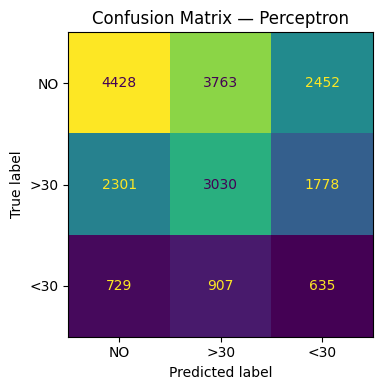

  Logistic Regression

Accuracy: 0.502

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6455  2397  1791
>30        2630  2679  1800
<30         716   647   908

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.61      0.63     10643
         >30       0.47      0.38      0.42      7109
         <30       0.20      0.40      0.27      2271

    accuracy                           0.50     20023
   macro avg       0.44      0.46      0.44     20023
weighted avg       0.54      0.50      0.51     20023

F1 per class:  NO=0.631  >30=0.418  <30=0.268
F1 macro:      0.439


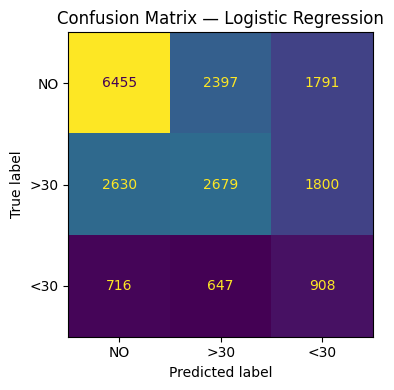

  Logistic Regression SMOTE

Accuracy: 0.494

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6383  2404  1856
>30        2594  2618  1897
<30         723   648   900

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.60      0.63     10643
         >30       0.46      0.37      0.41      7109
         <30       0.19      0.40      0.26      2271

    accuracy                           0.49     20023
   macro avg       0.44      0.45      0.43     20023
weighted avg       0.54      0.49      0.51     20023

F1 per class:  NO=0.628  >30=0.410  <30=0.260
F1 macro:      0.432


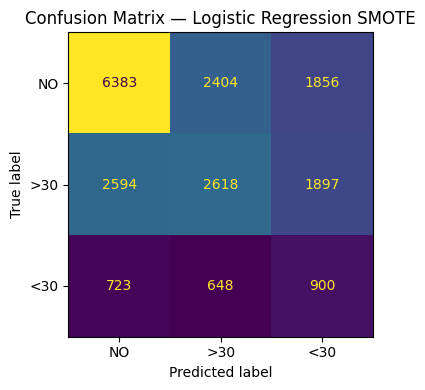

  Linear SVM

Accuracy: 0.562

Confusion matrix:
Predicted    NO   >30  <30
Actual                    
NO         8196  1930  517
>30        3874  2681  554
<30        1097   799  375

Classification report:
              precision    recall  f1-score   support

          NO       0.62      0.77      0.69     10643
         >30       0.50      0.38      0.43      7109
         <30       0.26      0.17      0.20      2271

    accuracy                           0.56     20023
   macro avg       0.46      0.44      0.44     20023
weighted avg       0.54      0.56      0.54     20023

F1 per class:  NO=0.688  >30=0.428  <30=0.202
F1 macro:      0.440


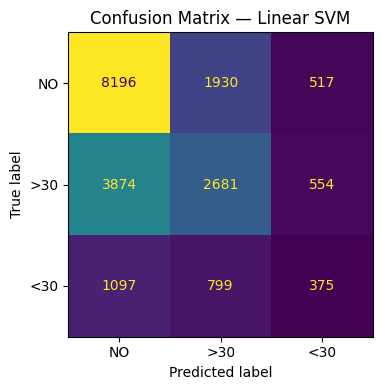

  Linear SVM SMOTE

Accuracy: 0.487

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6349  2342  1952
>30        2638  2445  2026
<30         734   574   963

Classification report:
              precision    recall  f1-score   support

          NO       0.65      0.60      0.62     10643
         >30       0.46      0.34      0.39      7109
         <30       0.19      0.42      0.27      2271

    accuracy                           0.49     20023
   macro avg       0.43      0.45      0.43     20023
weighted avg       0.53      0.49      0.50     20023

F1 per class:  NO=0.624  >30=0.392  <30=0.267
F1 macro:      0.428


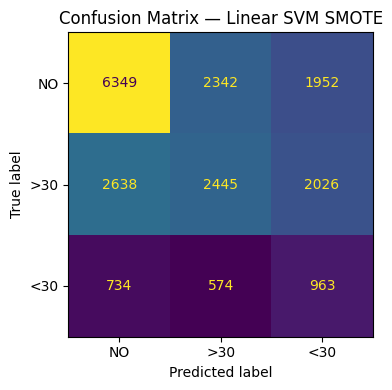

  Decision Tree

Accuracy: 0.480

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6745  1908  1990
>30        3062  1919  2128
<30         782   536   953

Classification report:
              precision    recall  f1-score   support

          NO       0.64      0.63      0.64     10643
         >30       0.44      0.27      0.33      7109
         <30       0.19      0.42      0.26      2271

    accuracy                           0.48     20023
   macro avg       0.42      0.44      0.41     20023
weighted avg       0.52      0.48      0.49     20023

F1 per class:  NO=0.635  >30=0.335  <30=0.260
F1 macro:      0.410


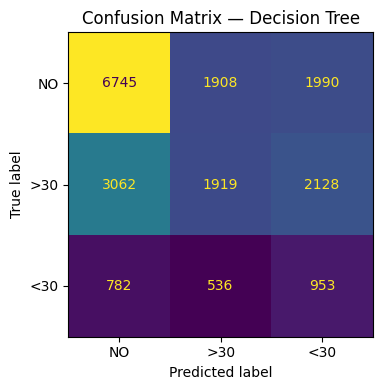

  Random Forest

Accuracy: 0.501

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6820  2238  1585
>30        2880  2353  1876
<30         791   623   857

Classification report:
              precision    recall  f1-score   support

          NO       0.65      0.64      0.65     10643
         >30       0.45      0.33      0.38      7109
         <30       0.20      0.38      0.26      2271

    accuracy                           0.50     20023
   macro avg       0.43      0.45      0.43     20023
weighted avg       0.53      0.50      0.51     20023

F1 per class:  NO=0.645  >30=0.382  <30=0.260
F1 macro:      0.429


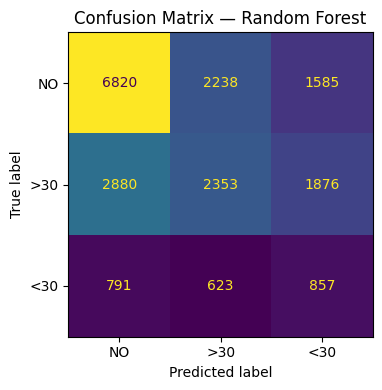

  XGBoost

Accuracy: 0.511

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6412  2586  1645
>30        2460  2935  1714
<30         671   723   877

Classification report:
              precision    recall  f1-score   support

          NO       0.67      0.60      0.64     10643
         >30       0.47      0.41      0.44      7109
         <30       0.21      0.39      0.27      2271

    accuracy                           0.51     20023
   macro avg       0.45      0.47      0.45     20023
weighted avg       0.55      0.51      0.52     20023

F1 per class:  NO=0.635  >30=0.440  <30=0.270
F1 macro:      0.448


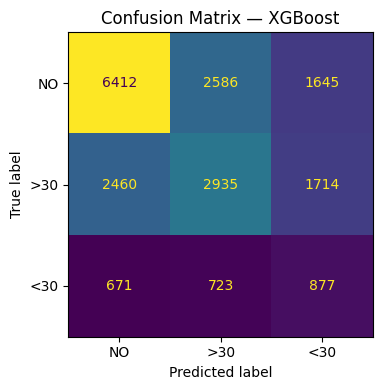


  SUMMARY
                    Model  Accuracy  F1 NO  F1 >30  F1 <30  F1 macro
                  XGBoost     0.511  0.635   0.440   0.270     0.448
               Linear SVM     0.562  0.688   0.428   0.202     0.440
      Logistic Regression     0.502  0.631   0.418   0.268     0.439
Logistic Regression SMOTE     0.494  0.628   0.410   0.260     0.432
            Random Forest     0.501  0.645   0.382   0.260     0.429
         Linear SVM SMOTE     0.487  0.624   0.392   0.267     0.428
            Decision Tree     0.480  0.635   0.335   0.260     0.410
               Perceptron     0.404  0.489   0.409   0.178     0.359


,Model,Accuracy,F1 NO,F1 >30,F1 <30,F1 macro
0,XGBoost,0.511,0.635,0.440,0.270,0.448
1,Linear SVM,0.562,0.688,0.428,0.202,0.440
2,Logistic Regression,0.502,0.631,0.418,0.268,0.439
3,Logistic Regression SMOTE,0.494,0.628,0.410,0.260,0.432
4,Random Forest,0.501,0.645,0.382,0.260,0.429
5,Linear SVM SMOTE,0.487,0.624,0.392,0.267,0.428
6,Decision Tree,0.480,0.635,0.335,0.260,0.410
7,Perceptron,0.404,0.489,0.409,0.178,0.359


In [ ]:
evaluate_models(all_models, X_test, y_test)

### Commento Risultati
XGBoost costruisce gli alberi in modo sequenziale, dove ogni nuovo albero cerca di correggere gli errori del precedente. Questo approccio lo rende uno dei modelli più efficaci del confronto, con un buon F1 macro in CV e una gestione migliore della classe minoritaria <30. Anche qui le variabili più influenti sono i ricoveri precedenti e il numero di diagnosi, confermando il loro ruolo centrale nella predizione della riammissione.


## XGBoost con SMOTE

In [ ]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

xgboost_model_smote = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    device="cpu",
    random_state=42,
    n_jobs=1,
)

In [ ]:
pipe_xgb_smote = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", xgboost_model_smote)
])

param_dist_xgb_smote = {
    "model__n_estimators":     [100, 200, 300],
    "model__max_depth":        [3, 4, 6],
    "model__learning_rate":    [0.01, 0.05, 0.1],
    "model__subsample":        [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
}

inner_search_xgb_smote = RandomizedSearchCV(
    pipe_xgb_smote, param_dist_xgb_smote,
    n_iter=20, cv=inner_cv,
    scoring="f1_macro", random_state=42, n_jobs=-1
)

scores_xgb_smote = cross_val_score(
    inner_search_xgb_smote, X_train, y_train,
    cv=outer_cv, scoring="f1_macro", n_jobs=1
)

In [ ]:
print(f"XGBoost SMOTE — F1 macro: {scores_xgb_smote.mean():.3f} ± {scores_xgb_smote.std():.3f}")

cv_results.append({
    "model":    "XGBoost SMOTE",
    "f1_mean":  round(scores_xgb_smote.mean(), 3),
    "f1_std":   round(scores_xgb_smote.std(),  3),
    "scores":   scores_xgb_smote.tolist()
})

XGBoost SMOTE — F1 macro: 0.424 ± 0.002


In [ ]:


inner_search_xgb_smote.fit(X_train, y_train)
print(inner_search_xgb_smote.best_params_)

{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}


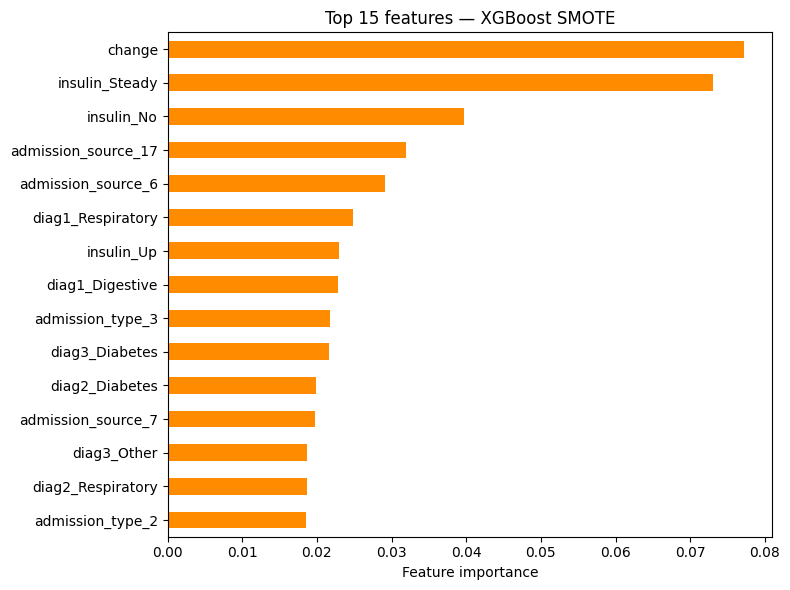

In [ ]:


xgb_model_smote = inner_search_xgb_smote.best_estimator_.named_steps["model"]
pd.Series(xgb_model_smote.feature_importances_, index=X_train.columns)\
  .sort_values(ascending=False).head(15)\
  .sort_values().plot(kind="barh", figsize=(8, 6), color="darkorange")
plt.title("Top 15 features — XGBoost SMOTE")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

In [ ]:
all_models.append({"name": "XGBoost SMOTE", "model": inner_search_xgb_smote})
save_model_to_drive("XGBoost SMOTE", inner_search_xgb_smote)

Successfully saved XGBoost SMOTE to /content/drive/MyDrive/Colab_Models/diabetes_readmission_models/xgboost_plus_smote.pkl


  Perceptron

Accuracy: 0.404

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         4428  3763  2452
>30        2301  3030  1778
<30         729   907   635

Classification report:
              precision    recall  f1-score   support

          NO       0.59      0.42      0.49     10643
         >30       0.39      0.43      0.41      7109
         <30       0.13      0.28      0.18      2271

    accuracy                           0.40     20023
   macro avg       0.37      0.37      0.36     20023
weighted avg       0.47      0.40      0.43     20023

F1 per class:  NO=0.489  >30=0.409  <30=0.178
F1 macro:      0.359


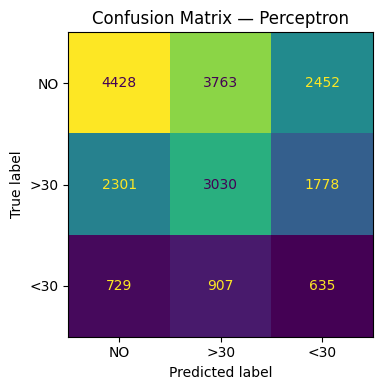

  Logistic Regression

Accuracy: 0.502

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6455  2397  1791
>30        2630  2679  1800
<30         716   647   908

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.61      0.63     10643
         >30       0.47      0.38      0.42      7109
         <30       0.20      0.40      0.27      2271

    accuracy                           0.50     20023
   macro avg       0.44      0.46      0.44     20023
weighted avg       0.54      0.50      0.51     20023

F1 per class:  NO=0.631  >30=0.418  <30=0.268
F1 macro:      0.439


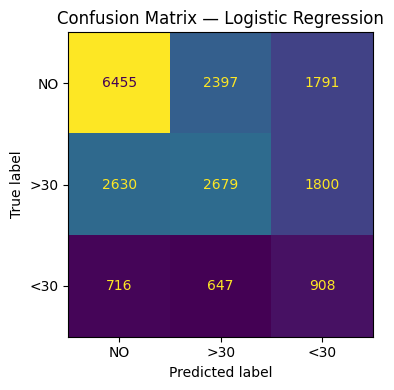

  Logistic Regression SMOTE

Accuracy: 0.494

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6383  2404  1856
>30        2594  2618  1897
<30         723   648   900

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.60      0.63     10643
         >30       0.46      0.37      0.41      7109
         <30       0.19      0.40      0.26      2271

    accuracy                           0.49     20023
   macro avg       0.44      0.45      0.43     20023
weighted avg       0.54      0.49      0.51     20023

F1 per class:  NO=0.628  >30=0.410  <30=0.260
F1 macro:      0.432


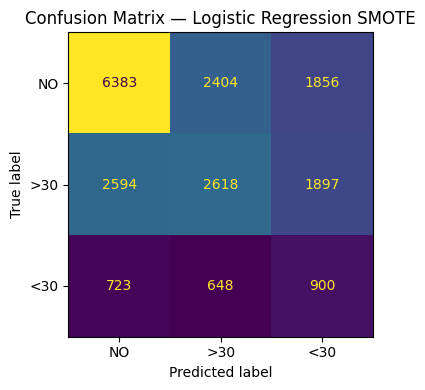

  Linear SVM

Accuracy: 0.562

Confusion matrix:
Predicted    NO   >30  <30
Actual                    
NO         8196  1930  517
>30        3874  2681  554
<30        1097   799  375

Classification report:
              precision    recall  f1-score   support

          NO       0.62      0.77      0.69     10643
         >30       0.50      0.38      0.43      7109
         <30       0.26      0.17      0.20      2271

    accuracy                           0.56     20023
   macro avg       0.46      0.44      0.44     20023
weighted avg       0.54      0.56      0.54     20023

F1 per class:  NO=0.688  >30=0.428  <30=0.202
F1 macro:      0.440


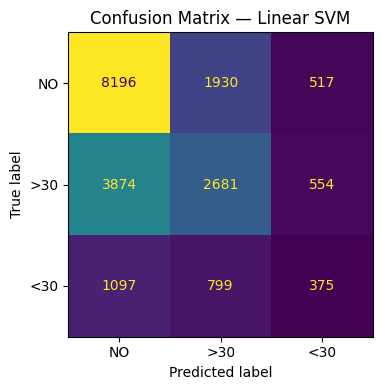

  Linear SVM SMOTE

Accuracy: 0.487

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6349  2342  1952
>30        2638  2445  2026
<30         734   574   963

Classification report:
              precision    recall  f1-score   support

          NO       0.65      0.60      0.62     10643
         >30       0.46      0.34      0.39      7109
         <30       0.19      0.42      0.27      2271

    accuracy                           0.49     20023
   macro avg       0.43      0.45      0.43     20023
weighted avg       0.53      0.49      0.50     20023

F1 per class:  NO=0.624  >30=0.392  <30=0.267
F1 macro:      0.428


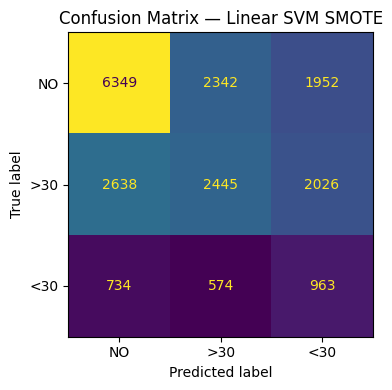

  Decision Tree

Accuracy: 0.480

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6745  1908  1990
>30        3062  1919  2128
<30         782   536   953

Classification report:
              precision    recall  f1-score   support

          NO       0.64      0.63      0.64     10643
         >30       0.44      0.27      0.33      7109
         <30       0.19      0.42      0.26      2271

    accuracy                           0.48     20023
   macro avg       0.42      0.44      0.41     20023
weighted avg       0.52      0.48      0.49     20023

F1 per class:  NO=0.635  >30=0.335  <30=0.260
F1 macro:      0.410


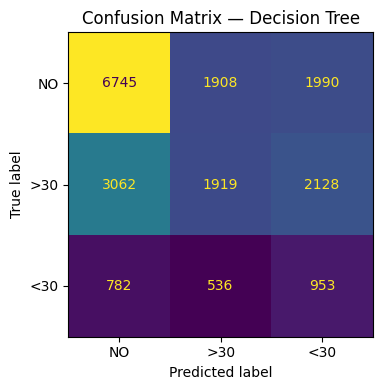

  Random Forest

Accuracy: 0.501

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6820  2238  1585
>30        2880  2353  1876
<30         791   623   857

Classification report:
              precision    recall  f1-score   support

          NO       0.65      0.64      0.65     10643
         >30       0.45      0.33      0.38      7109
         <30       0.20      0.38      0.26      2271

    accuracy                           0.50     20023
   macro avg       0.43      0.45      0.43     20023
weighted avg       0.53      0.50      0.51     20023

F1 per class:  NO=0.645  >30=0.382  <30=0.260
F1 macro:      0.429


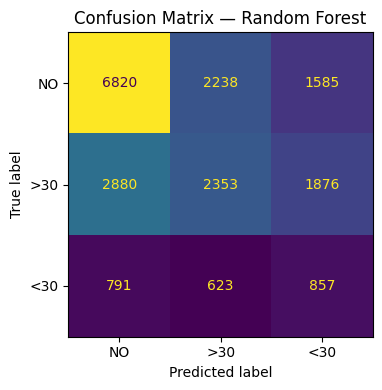

  XGBoost

Accuracy: 0.511

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6412  2586  1645
>30        2460  2935  1714
<30         671   723   877

Classification report:
              precision    recall  f1-score   support

          NO       0.67      0.60      0.64     10643
         >30       0.47      0.41      0.44      7109
         <30       0.21      0.39      0.27      2271

    accuracy                           0.51     20023
   macro avg       0.45      0.47      0.45     20023
weighted avg       0.55      0.51      0.52     20023

F1 per class:  NO=0.635  >30=0.440  <30=0.270
F1 macro:      0.448


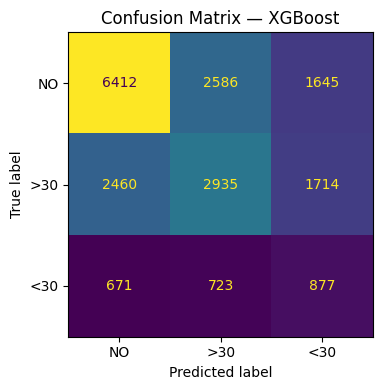

  XGBoost SMOTE

Accuracy: 0.564

Confusion matrix:
Predicted    NO   >30  <30
Actual                    
NO         7960  2319  364
>30        3635  3112  362
<30        1122   928  221

Classification report:
              precision    recall  f1-score   support

          NO       0.63      0.75      0.68     10643
         >30       0.49      0.44      0.46      7109
         <30       0.23      0.10      0.14      2271

    accuracy                           0.56     20023
   macro avg       0.45      0.43      0.43     20023
weighted avg       0.53      0.56      0.54     20023

F1 per class:  NO=0.682  >30=0.462  <30=0.137
F1 macro:      0.427


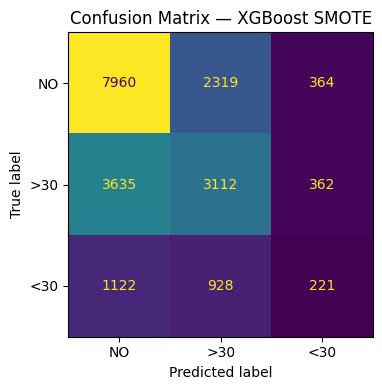


  SUMMARY
                    Model  Accuracy  F1 NO  F1 >30  F1 <30  F1 macro
                  XGBoost     0.511  0.635   0.440   0.270     0.448
               Linear SVM     0.562  0.688   0.428   0.202     0.440
      Logistic Regression     0.502  0.631   0.418   0.268     0.439
Logistic Regression SMOTE     0.494  0.628   0.410   0.260     0.432
            Random Forest     0.501  0.645   0.382   0.260     0.429
         Linear SVM SMOTE     0.487  0.624   0.392   0.267     0.428
            XGBoost SMOTE     0.564  0.682   0.462   0.137     0.427
            Decision Tree     0.480  0.635   0.335   0.260     0.410
               Perceptron     0.404  0.489   0.409   0.178     0.359


,Model,Accuracy,F1 NO,F1 >30,F1 <30,F1 macro
0,XGBoost,0.511,0.635,0.440,0.270,0.448
1,Linear SVM,0.562,0.688,0.428,0.202,0.440
2,Logistic Regression,0.502,0.631,0.418,0.268,0.439
3,Logistic Regression SMOTE,0.494,0.628,0.410,0.260,0.432
4,Random Forest,0.501,0.645,0.382,0.260,0.429
5,Linear SVM SMOTE,0.487,0.624,0.392,0.267,0.428
6,XGBoost SMOTE,0.564,0.682,0.462,0.137,0.427
7,Decision Tree,0.480,0.635,0.335,0.260,0.410
8,Perceptron,0.404,0.489,0.409,0.178,0.359


In [ ]:
evaluate_models(all_models, X_test, y_test)

### Commento Risultati
Questa variante sostituisce il bilanciamento tramite pesi con la generazione di campioni sintetici della classe minoritaria (SMOTE). I risultati in CV sono simili o leggermente inferiori rispetto alla versione base, suggerendo che per XGBoost agire direttamente sulla funzione di perdita tramite i pesi sia più efficace che aumentare artificialmente i dati della classe <30.

## CatBoost

In [ ]:
try:
    from catboost import CatBoostClassifier
except ImportError as exc:
    raise ImportError("Installa catboost prima di eseguire questa cella: pip install catboost") from exc

catboost_model = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1:average=Macro",
    auto_class_weights="Balanced",
    task_type="CPU",
    random_seed=42,
    verbose=False,
    thread_count=-1
)

In [ ]:
param_dist_cb = {
    "depth":         [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "iterations":    [200, 400, 600],
    "l2_leaf_reg":   [1, 3, 5, 9]
}

inner_search_cb = RandomizedSearchCV(
    catboost_model, param_dist_cb,
    n_iter=15, cv=inner_cv,
    scoring="f1_macro", random_state=42, n_jobs=1
)

scores_cb = cross_val_score(
    inner_search_cb, X_train, y_train,
    cv=outer_cv, scoring="f1_macro", n_jobs=1
)

In [ ]:
print(f"CatBoost — F1 macro: {scores_cb.mean():.3f} ± {scores_cb.std():.3f}")

cv_results.append({
    "model":    "CatBoost",
    "f1_mean":  round(scores_cb.mean(), 3),
    "f1_std":   round(scores_cb.std(),  3),
    "scores":   scores_cb.tolist()
})

CatBoost — F1 macro: 0.449 ± 0.003


In [ ]:
inner_search_cb.fit(X_train, y_train)
print(inner_search_cb.best_params_)

{'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 600, 'depth': 6}


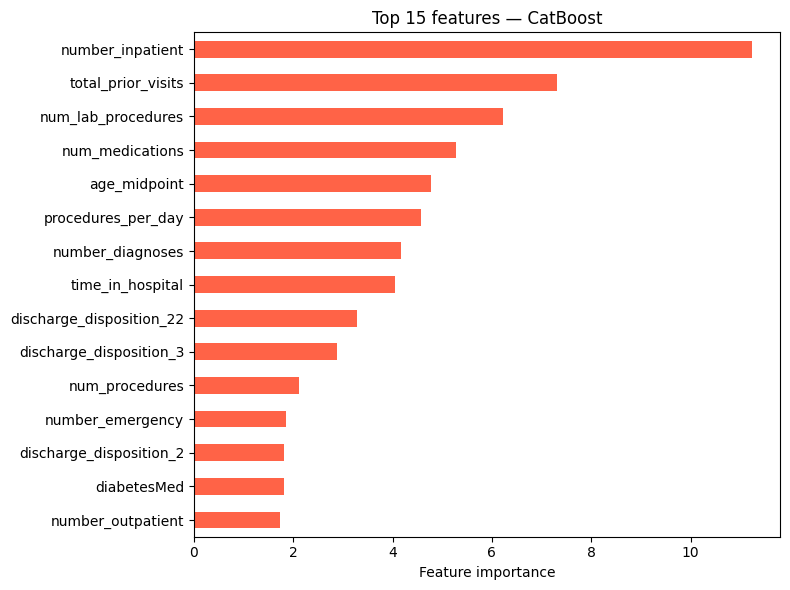

In [ ]:


cb_model = inner_search_cb.best_estimator_
pd.Series(cb_model.get_feature_importance(), index=X_train.columns)\
  .sort_values(ascending=False).head(15)\
  .sort_values().plot(kind="barh", figsize=(8, 6), color="tomato")
plt.title("Top 15 features — CatBoost")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

In [ ]:
all_models.append({"name": "CatBoost", "model": inner_search_cb})
save_model_to_drive("CatBoost", inner_search_cb)

Successfully saved CatBoost to /content/drive/MyDrive/Colab_Models/diabetes_readmission_models/catboost.pkl


  Perceptron

Accuracy: 0.404

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         4428  3763  2452
>30        2301  3030  1778
<30         729   907   635

Classification report:
              precision    recall  f1-score   support

          NO       0.59      0.42      0.49     10643
         >30       0.39      0.43      0.41      7109
         <30       0.13      0.28      0.18      2271

    accuracy                           0.40     20023
   macro avg       0.37      0.37      0.36     20023
weighted avg       0.47      0.40      0.43     20023

F1 per class:  NO=0.489  >30=0.409  <30=0.178
F1 macro:      0.359


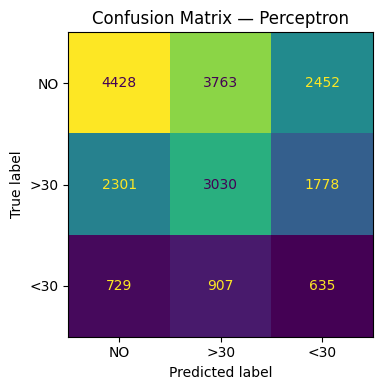

  Logistic Regression

Accuracy: 0.502

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6455  2397  1791
>30        2630  2679  1800
<30         716   647   908

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.61      0.63     10643
         >30       0.47      0.38      0.42      7109
         <30       0.20      0.40      0.27      2271

    accuracy                           0.50     20023
   macro avg       0.44      0.46      0.44     20023
weighted avg       0.54      0.50      0.51     20023

F1 per class:  NO=0.631  >30=0.418  <30=0.268
F1 macro:      0.439


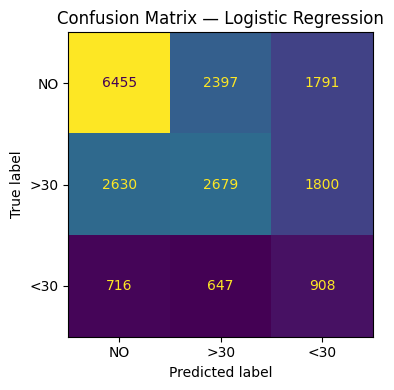

  Logistic Regression SMOTE

Accuracy: 0.494

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6383  2404  1856
>30        2594  2618  1897
<30         723   648   900

Classification report:
              precision    recall  f1-score   support

          NO       0.66      0.60      0.63     10643
         >30       0.46      0.37      0.41      7109
         <30       0.19      0.40      0.26      2271

    accuracy                           0.49     20023
   macro avg       0.44      0.45      0.43     20023
weighted avg       0.54      0.49      0.51     20023

F1 per class:  NO=0.628  >30=0.410  <30=0.260
F1 macro:      0.432


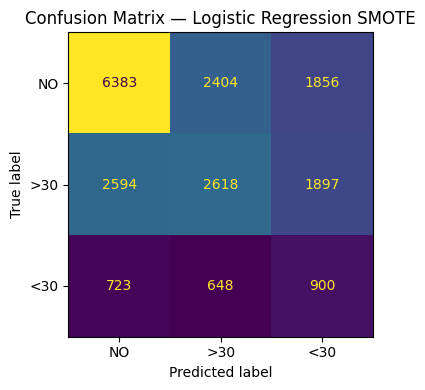

  Linear SVM

Accuracy: 0.562

Confusion matrix:
Predicted    NO   >30  <30
Actual                    
NO         8196  1930  517
>30        3874  2681  554
<30        1097   799  375

Classification report:
              precision    recall  f1-score   support

          NO       0.62      0.77      0.69     10643
         >30       0.50      0.38      0.43      7109
         <30       0.26      0.17      0.20      2271

    accuracy                           0.56     20023
   macro avg       0.46      0.44      0.44     20023
weighted avg       0.54      0.56      0.54     20023

F1 per class:  NO=0.688  >30=0.428  <30=0.202
F1 macro:      0.440


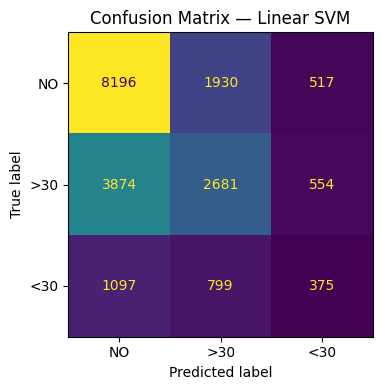

  Linear SVM SMOTE

Accuracy: 0.487

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6349  2342  1952
>30        2638  2445  2026
<30         734   574   963

Classification report:
              precision    recall  f1-score   support

          NO       0.65      0.60      0.62     10643
         >30       0.46      0.34      0.39      7109
         <30       0.19      0.42      0.27      2271

    accuracy                           0.49     20023
   macro avg       0.43      0.45      0.43     20023
weighted avg       0.53      0.49      0.50     20023

F1 per class:  NO=0.624  >30=0.392  <30=0.267
F1 macro:      0.428


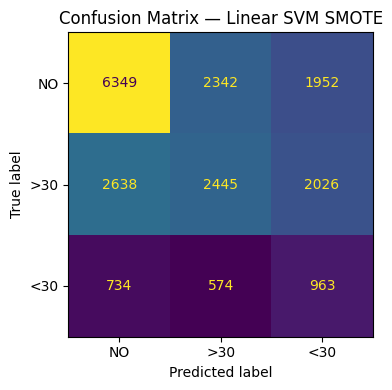

  Decision Tree

Accuracy: 0.480

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6745  1908  1990
>30        3062  1919  2128
<30         782   536   953

Classification report:
              precision    recall  f1-score   support

          NO       0.64      0.63      0.64     10643
         >30       0.44      0.27      0.33      7109
         <30       0.19      0.42      0.26      2271

    accuracy                           0.48     20023
   macro avg       0.42      0.44      0.41     20023
weighted avg       0.52      0.48      0.49     20023

F1 per class:  NO=0.635  >30=0.335  <30=0.260
F1 macro:      0.410


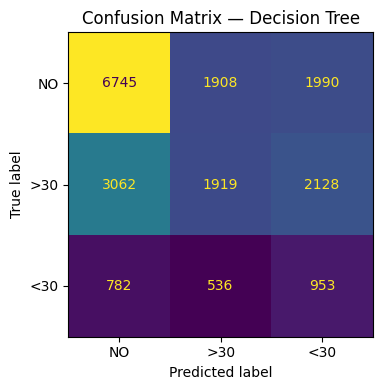

  Random Forest

Accuracy: 0.501

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6820  2238  1585
>30        2880  2353  1876
<30         791   623   857

Classification report:
              precision    recall  f1-score   support

          NO       0.65      0.64      0.65     10643
         >30       0.45      0.33      0.38      7109
         <30       0.20      0.38      0.26      2271

    accuracy                           0.50     20023
   macro avg       0.43      0.45      0.43     20023
weighted avg       0.53      0.50      0.51     20023

F1 per class:  NO=0.645  >30=0.382  <30=0.260
F1 macro:      0.429


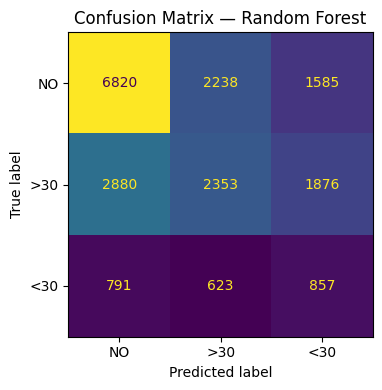

  XGBoost

Accuracy: 0.511

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6412  2586  1645
>30        2460  2935  1714
<30         671   723   877

Classification report:
              precision    recall  f1-score   support

          NO       0.67      0.60      0.64     10643
         >30       0.47      0.41      0.44      7109
         <30       0.21      0.39      0.27      2271

    accuracy                           0.51     20023
   macro avg       0.45      0.47      0.45     20023
weighted avg       0.55      0.51      0.52     20023

F1 per class:  NO=0.635  >30=0.440  <30=0.270
F1 macro:      0.448


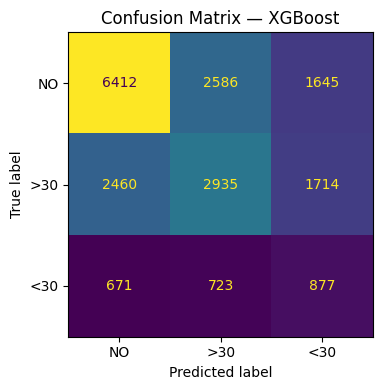

  XGBoost SMOTE

Accuracy: 0.564

Confusion matrix:
Predicted    NO   >30  <30
Actual                    
NO         7960  2319  364
>30        3635  3112  362
<30        1122   928  221

Classification report:
              precision    recall  f1-score   support

          NO       0.63      0.75      0.68     10643
         >30       0.49      0.44      0.46      7109
         <30       0.23      0.10      0.14      2271

    accuracy                           0.56     20023
   macro avg       0.45      0.43      0.43     20023
weighted avg       0.53      0.56      0.54     20023

F1 per class:  NO=0.682  >30=0.462  <30=0.137
F1 macro:      0.427


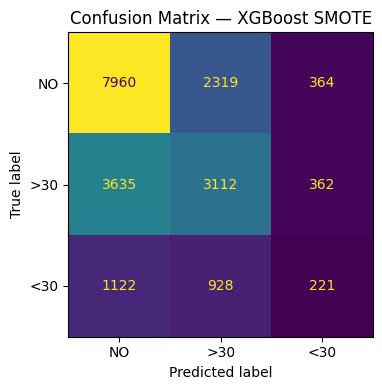

  CatBoost

Accuracy: 0.513

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6489  2454  1700
>30        2499  2883  1727
<30         681   687   903

Classification report:
              precision    recall  f1-score   support

          NO       0.67      0.61      0.64     10643
         >30       0.48      0.41      0.44      7109
         <30       0.21      0.40      0.27      2271

    accuracy                           0.51     20023
   macro avg       0.45      0.47      0.45     20023
weighted avg       0.55      0.51      0.53     20023

F1 per class:  NO=0.639  >30=0.439  <30=0.274
F1 macro:      0.451


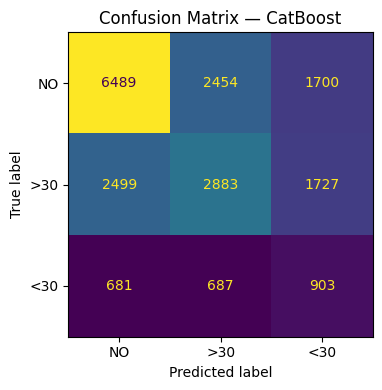


  SUMMARY
                    Model  Accuracy  F1 NO  F1 >30  F1 <30  F1 macro
                 CatBoost     0.513  0.639   0.439   0.274     0.451
                  XGBoost     0.511  0.635   0.440   0.270     0.448
               Linear SVM     0.562  0.688   0.428   0.202     0.440
      Logistic Regression     0.502  0.631   0.418   0.268     0.439
Logistic Regression SMOTE     0.494  0.628   0.410   0.260     0.432
            Random Forest     0.501  0.645   0.382   0.260     0.429
         Linear SVM SMOTE     0.487  0.624   0.392   0.267     0.428
            XGBoost SMOTE     0.564  0.682   0.462   0.137     0.427
            Decision Tree     0.480  0.635   0.335   0.260     0.410
               Perceptron     0.404  0.489   0.409   0.178     0.359


,Model,Accuracy,F1 NO,F1 >30,F1 <30,F1 macro
0,CatBoost,0.513,0.639,0.439,0.274,0.451
1,XGBoost,0.511,0.635,0.440,0.270,0.448
2,Linear SVM,0.562,0.688,0.428,0.202,0.440
3,Logistic Regression,0.502,0.631,0.418,0.268,0.439
4,Logistic Regression SMOTE,0.494,0.628,0.410,0.260,0.432
5,Random Forest,0.501,0.645,0.382,0.260,0.429
6,Linear SVM SMOTE,0.487,0.624,0.392,0.267,0.428
7,XGBoost SMOTE,0.564,0.682,0.462,0.137,0.427
8,Decision Tree,0.480,0.635,0.335,0.260,0.410
9,Perceptron,0.404,0.489,0.409,0.178,0.359


In [ ]:
evaluate_models(all_models, X_test, y_test)

### Commento Risultati
CatBoost è uno dei modelli più performanti del confronto. Lavora sul dataset già codificato in one-hot e utilizza il bilanciamento automatico delle classi. In CV ottiene un F1 macro tra i più alti, con punteggi stabili tra i fold.

## Diagnosi overfitting (train vs test)

Confronto della stessa metrica (`f1_macro`) su train e su test: un gap ampio indica overfitting; valori entrambi bassi e simili indicano che il limite è la difficoltà del problema, non la varianza.

In [ ]:
from sklearn.metrics import f1_score

print(f"{'Modello':25s} {'train':>7} {'test':>7} {'gap':>7}")
for entry in all_models:
    m = entry["model"]
    f1_tr = f1_score(y_train, m.predict(X_train), average="macro")
    f1_te = f1_score(y_test,  m.predict(X_test),  average="macro")
    print(f"{entry['name']:25s} {f1_tr:7.3f} {f1_te:7.3f} {f1_tr - f1_te:+7.3f}")


Modello                     train    test     gap
Perceptron                  0.359   0.359  -0.000
Logistic Regression         0.440   0.439  +0.001
Logistic Regression SMOTE   0.436   0.432  +0.004
Linear SVM                  0.442   0.440  +0.002
Linear SVM SMOTE            0.429   0.428  +0.001
Decision Tree               0.415   0.410  +0.005
Random Forest               0.486   0.429  +0.056
XGBoost                     0.487   0.448  +0.039
XGBoost SMOTE               0.486   0.427  +0.059
CatBoost                    0.491   0.451  +0.041


### Commento Risultati
 I modelli lineari (Perceptron, Logistic Regression, SVM) mostrano gap minimi, segno che non soffrono di overfitting ma piuttosto di underfitting. I modelli ad albero più complessi come Random Forest e XGBoost presentano un gap leggermente maggiore, contenuto però grazie ai vincoli imposti durante la ricerca degli iperparametri. CatBoost risulta il più equilibrato tra capacità predittiva e generalizzazione.

## CatBoost con categoriche native — senza Nested Cross-Validation

In questa variante addestriamo lo stesso CatBoost con categoriche native
utilizzando una semplice **RandomizedSearchCV** (inner CV only), senza il
loop esterno della nested CV. La stima dell'F1 macro ottenuta è quindi
ottimistica rispetto alle stime degli altri modelli, perché la stessa
porzione di dati viene usata sia per selezionare gli iperparametri che
per valutare la performance. La includiamo a scopo illustrativo per
mostrare come CatBoost gestisce nativamente le variabili categoriche
quando non si ha il vincolo computazionale della nested CV.

In [ ]:
# Mapping età -> punto medio numerico
_age_map = {
    "[0-10)": 5,  "[10-20)": 15, "[20-30)": 25, "[30-40)": 35, "[40-50)": 45,
    "[50-60)": 55, "[60-70)": 65, "[70-80)": 75, "[80-90)": 85, "[90-100)": 95,
}

def _assign_age_group(midpoint):
    if midpoint < 40: return "young"
    if midpoint < 70: return "adult"
    return "elderly"

def _map_icd9_to_group(code):
    code = str(code).strip().upper()
    if code in ["", "?", "NAN", "NONE"]: return "Missing"
    code = code.split(".")[0]
    if code.startswith("V"): return "V_code"
    if code.startswith("E"): return "E_code"
    try:
        n = int(code)
    except ValueError:
        return "Other"
    if n == 250:                     return "Diabetes"
    if 390 <= n <= 459 or n == 785:  return "Circulatory"
    if 460 <= n <= 519 or n == 786:  return "Respiratory"
    if 520 <= n <= 579 or n == 787:  return "Digestive"
    if 800 <= n <= 999:              return "Injury"
    if 710 <= n <= 739:              return "Musculoskeletal"
    if 580 <= n <= 629:              return "Genitourinary"
    if 140 <= n <= 239:              return "Neoplasms"
    return "Other"

def build_categorical_frame(index):
    """
    Ricostruisce il DataFrame delle feature per le righe `index`
    partendo dal dataset grezzo X (originale, mai modificato).
    Restituisce (DataFrame, lista_nomi_colonne_categoriche).
    """
    raw = X.loc[index].copy()
    f = pd.DataFrame(index=index)

    # Categoriche native (stringa)
    f["admission_type_id"]        = raw["admission_type_id"].astype(str)
    f["discharge_disposition_id"] = raw["discharge_disposition_id"].astype(str)
    f["admission_source_id"]      = raw["admission_source_id"].astype(str)
    f["insulin"]                  = raw["insulin"].astype(str)

    # Età
    f["age_midpoint"] = raw["age"].map(_age_map).astype(int)
    f["age_group"]    = f["age_midpoint"].apply(_assign_age_group)

    # Diagnosi ICD-9 raggruppate
    f["diag_1_group"] = raw["diag_1"].apply(_map_icd9_to_group)
    f["diag_2_group"] = raw["diag_2"].apply(_map_icd9_to_group)
    f["diag_3_group"] = raw["diag_3"].apply(_map_icd9_to_group)

    # Numeriche
    for c in ["time_in_hospital", "num_lab_procedures", "num_procedures",
              "num_medications", "number_outpatient", "number_emergency",
              "number_inpatient", "number_diagnoses"]:
        f[c] = raw[c].astype(float)

    # Binarie
    f["metformin"]   = (raw["metformin"] != "No").astype(int)
    f["change"]      = raw["change"].map({"No": 0, "Ch": 1}).astype(int)
    f["diabetesMed"] = raw["diabetesMed"].map({"No": 0, "Yes": 1}).astype(int)

    # Feature ingegnerizzate
    f["total_prior_visits"] = (f["number_outpatient"]
                               + f["number_emergency"]
                               + f["number_inpatient"])
    f["high_utilizer"]      = (f["total_prior_visits"] > 3).astype(int)
    f["polypharmacy"]       = (f["num_medications"] > 10).astype(int)
    f["high_comorbidity"]   = (f["number_diagnoses"] > 7).astype(int)
    f["procedures_per_day"] = (
        f["num_procedures"] / f["time_in_hospital"].clip(lower=1)
    ).round(3)

    # Nessun NaN nelle categoriche, restituite come str
    cat_cols = ["admission_type_id", "discharge_disposition_id",
                "admission_source_id", "insulin", "age_group",
                "diag_1_group", "diag_2_group", "diag_3_group"]
    f[cat_cols] = f[cat_cols].fillna("Missing").astype(str)

    return f, cat_cols

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
import torch

class CatBoostWithCatFeatures(BaseEstimator, ClassifierMixin):

    def __init__(self, cat_features=None, loss_function="MultiClass",
                 eval_metric="TotalF1:average=Macro",
                 auto_class_weights="Balanced", task_type="GPU" if torch.cuda.is_available() else "CPU",
                 random_seed=42, verbose=False, thread_count=-1,
                 depth=6, learning_rate=0.03, iterations=400, l2_leaf_reg=3):
        # I nomi devono corrispondere esattamente agli attributi self.xxx
        # — vincolo di sklearn per get_params()
        self.cat_features       = cat_features
        self.loss_function      = loss_function
        self.eval_metric        = eval_metric
        self.auto_class_weights = auto_class_weights
        self.task_type          = task_type
        self.random_seed        = random_seed
        self.verbose            = verbose
        self.thread_count       = thread_count
        self.depth              = depth
        self.learning_rate      = learning_rate
        self.iterations         = iterations
        self.l2_leaf_reg        = l2_leaf_reg

    def fit(self, X, y):
        # Crea un CatBoostClassifier fresco ad ogni fold e passa
        # cat_features direttamente a fit(), dove CatBoost lo gestisce
        # in modo affidabile
        self.model_ = CatBoostClassifier(
            loss_function=self.loss_function,
            eval_metric=self.eval_metric,
            auto_class_weights=self.auto_class_weights,
            task_type=self.task_type,
            random_seed=self.random_seed,
            verbose=self.verbose,
            thread_count=self.thread_count,
            depth=self.depth,
            learning_rate=self.learning_rate,
            iterations=self.iterations,
            l2_leaf_reg=self.l2_leaf_reg,
        )
        self.model_.fit(X, y, cat_features=self.cat_features)
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        check_is_fitted(self)
        return self.model_.predict(X).flatten()

    def predict_proba(self, X):
        check_is_fitted(self)
        return self.model_.predict_proba(X)

    def get_feature_importance(self):
        check_is_fitted(self)
        return self.model_.get_feature_importance()

Migliori parametri: {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 600, 'depth': 6}
F1 macro (inner CV, ottimistico): 0.446


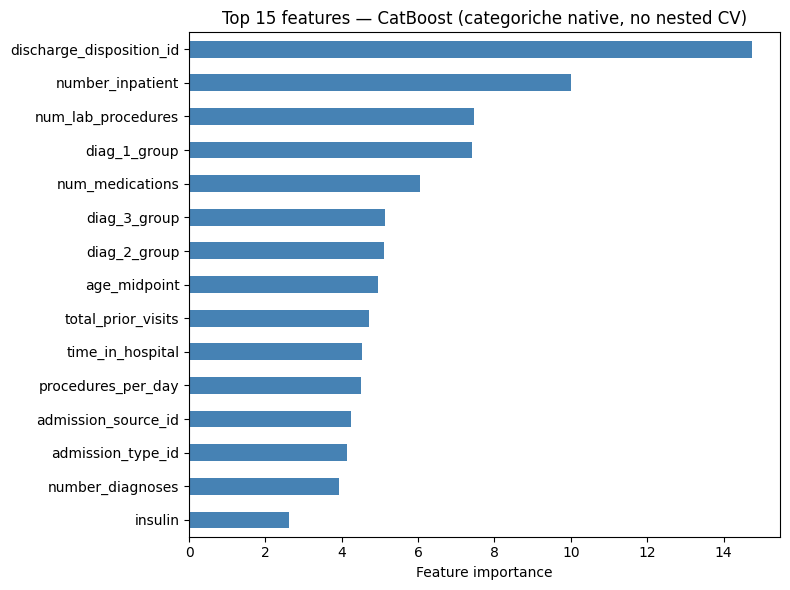

  CatBoost (no nested CV)

Accuracy: 0.508

Confusion matrix:
Predicted    NO   >30   <30
Actual                     
NO         6491  2374  1778
>30        2521  2793  1795
<30         685   699   887

Classification report:
              precision    recall  f1-score   support

          NO       0.67      0.61      0.64     10643
         >30       0.48      0.39      0.43      7109
         <30       0.20      0.39      0.26      2271

    accuracy                           0.51     20023
   macro avg       0.45      0.46      0.44     20023
weighted avg       0.55      0.51      0.52     20023

F1 per class:  NO=0.638  >30=0.431  <30=0.264
F1 macro:      0.444


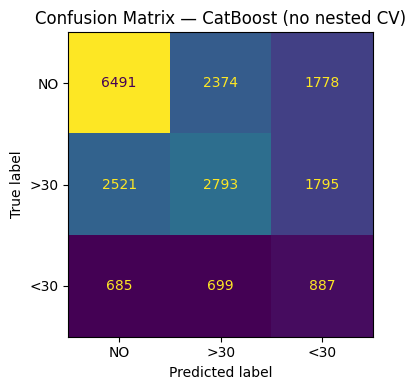


  SUMMARY
                  Model  Accuracy  F1 NO  F1 >30  F1 <30  F1 macro
CatBoost (no nested CV)     0.508  0.638   0.431   0.264     0.444


,Model,Accuracy,F1 NO,F1 >30,F1 <30,F1 macro
0,CatBoost (no nested CV),0.508,0.638,0.431,0.264,0.444


In [ ]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

# Ricostruisci i frame (se non sono già in memoria)
X_train_cat, CAT_FEATURES = build_categorical_frame(X_train.index)
X_test_cat,  _            = build_categorical_frame(X_test.index)
y_train_cat = y_model.loc[X_train.index].squeeze()
y_test_cat  = y_model.loc[X_test.index].squeeze()

# Allinea valori non visti in train
for col in CAT_FEATURES:
    unseen = set(X_test_cat[col].unique()) - set(X_train_cat[col].unique())
    if unseen:
        X_test_cat[col] = X_test_cat[col].replace(dict.fromkeys(unseen, "Missing"))

# Modello
catboost_simple = CatBoostWithCatFeatures(
    cat_features=CAT_FEATURES,
)

param_dist = {
    "depth":         [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "iterations":    [200, 400, 600],
    "l2_leaf_reg":   [1, 3, 5, 9],
}

search_simple = RandomizedSearchCV(
    catboost_simple, param_dist,
    n_iter=15, cv=inner_cv,
    scoring="f1_macro", random_state=42, n_jobs=1,
)

# Fit (solo inner CV, niente outer)
search_simple.fit(X_train_cat, y_train_cat)
print("Migliori parametri:", search_simple.best_params_)
print(f"F1 macro (inner CV, ottimistico): {search_simple.best_score_:.3f}")

cb_simple_model = search_simple.best_estimator_

# Feature importance
pd.Series(cb_simple_model.get_feature_importance(), index=X_train_cat.columns) \
  .sort_values(ascending=False).head(15) \
  .sort_values().plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Top 15 features — CatBoost (categoriche native, no nested CV)")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

# Valutazione sul test set
evaluate_models(
    [{"name": "CatBoost (no nested CV)", "model": cb_simple_model}],
    X_test_cat, y_test_cat,
)

### Commento Risultati

Il modello ottiene un F1 macro di **0.444**, in linea con il CatBoost one-hot (0.449),
a conferma che le categoriche native non degradano le performance e anzi offrono
una rappresentazione più compatta e interpretabile delle variabili.

Va sottolineato che la stima dell'F1 macro riportata è **ottimistica**: non avendo
usato la nested cross-validation, gli stessi dati di train sono stati usati sia per
selezionare gli iperparametri che per valutare la performance, introducendo un bias
positivo nella stima. Il valore reale su dati nuovi potrebbe essere leggermente inferiore.

Guardando le singole classi:
- **NO** (nessuna riammissione): F1 = 0.638, la classe più facile da predire grazie
  alla sua maggiore frequenza nel dataset
- **>30** (riammissione dopo 30 giorni): F1 = 0.431, performance discreta
- **<30** (riammissione entro 30 giorni): F1 = 0.264, la classe più difficile e
  clinicamente più rilevante, ancora sottorappresentata nonostante il bilanciamento
  automatico delle classi (`auto_class_weights="Balanced"`)

Il pattern è coerente con tutti gli altri modelli del confronto: la classe `<30`
rimane la più difficile da catturare, il che riflette la difficoltà intrinseca
del problema più che un limite del modello specifico.

## Confronto finale — Nested Cross-Validation

Tutti i modelli sono stati valutati con la stessa procedura di **nested cross-validation**
(outer 5-fold stratificato, inner 3-fold stratificato), che fornisce una stima dell'F1 macro
non distorta dalla selezione degli iperparametri: il loop esterno misura la performance,
quello interno ottimizza i parametri, e i due livelli non si vedono mai.

La metrica scelta per il confronto è l'**F1 macro**, che tratta le tre classi (`NO`, `>30`, `<30`)
con lo stesso peso indipendentemente dalla loro frequenza nel dataset. È la scelta più
appropriata in un contesto di classificazione sbilanciata come questo, dove la classe `<30`
(riammissione entro 30 giorni) è quella clinicamente più rilevante ma anche la meno rappresentata.

| Modello | F1 macro (CV) |
|---|---|
| Perceptron | [0.365] ± [0.017] |
| Logistic Regression | [0.438] ± [0.004] |
| Logistic Regression + SMOTE | [0.430] ± [0.003] |
| Linear SVM | [0.438] ± [0.004] |
| Linear SVM + SMOTE | [0.424] ± [0.003] |
| Decision Tree | [0.426] ± [0.005] |
| Random Forest | [0.431] ± [0.002] |
| XGBoost | [0.449] ± [0.004] |
| XGBoost + SMOTE | [0.424] ± [0.002] |
| CatBoost (one-hot) | [0.449] ± [0.003] |


I modelli lineari (Perceptron, Logistic Regression, SVM) mostrano performance simili tra loro
e tendono all'underfitting: il confine decisionale lineare non è sufficiente a catturare
la complessità del problema. L'aggiunta di SMOTE porta un miglioramento marginale,
ma non risolve il limite strutturale della linearità.

I modelli ad albero (Decision Tree, Random Forest, XGBoost, CatBoost) ottengono risultati
superiori grazie alla capacità di modellare interazioni non lineari tra le feature.

La deviazione standard dei fold esterni indica la stabilità della stima: valori bassi
(± 0.005–0.015) confermano che i risultati sono riproducibili e non dipendenti da un
particolare split del dataset.

# Web App

Interfaccia [Gradio](https://www.gradio.app/) per usare i modelli addestrati su singoli pazienti.



In [ ]:
import gradio as gr
import joblib
import numpy as np
import pandas as pd
import os
from pathlib import Path


try:
    from xgboost import XGBClassifier
    from sklearn.utils.class_weight import compute_sample_weight

    class BalancedXGB(XGBClassifier):
        def fit(self, X, y, **kwargs):
            sw = compute_sample_weight("balanced", y)
            return super().fit(X, y, sample_weight=sw, **kwargs)
except Exception:
    # xgboost non installato: gli altri modelli restano caricabili.
    pass

# Cartella di default: prova prima Drive, poi una cartella locale di fallback.
DEFAULT_DRIVE_DIR = '/content/drive/MyDrive/Colab_Models/diabetes_readmission_models'
DEFAULT_LOCAL_DIR = '/content/diabetes_readmission_models'

def _pick_default_dir():
    for d in (DEFAULT_DRIVE_DIR, DEFAULT_LOCAL_DIR, '.'):
        if os.path.isdir(d):
            return d
    return DEFAULT_DRIVE_DIR

# File "di servizio" da NON mostrare come modelli selezionabili.
HELPER_FILES = {
    "feature_columns.pkl", "target_names.pkl",
    "X_train.pkl", "X_test.pkl", "y_train.pkl", "y_test.pkl",
}

FILENAME_TO_LABEL = {
    'perceptron.pkl': 'Perceptron',
    'logistic_regression.pkl': 'Logistic Regression',
    'lr_plus_smote.pkl': 'Logistic Regression SMOTE',
    'linear_svm.pkl': 'Linear SVM',
    'svm_plus_smote.pkl': 'Linear SVM SMOTE',
    'decision_tree.pkl': 'Decision Tree',
    'random_forest.pkl': 'Random Forest',
    'xgboost.pkl': 'XGBoost',
    'xgboost_plus_smote.pkl': 'XGBoost SMOTE',
    'catboost.pkl': 'CatBoost',
}

# =============================================================================
# COSTANTI DI MAPPING (invariate)
# =============================================================================

ADM = {
    "1-Emergency": 1, "2-Urgent": 2, "3-Elective": 3, "4-Newborn": 4,
    "5-Not Available": 5, "6-NULL": 6, "7-Trauma Center": 7, "8-Not Mapped": 8,
}

DISCH = {
    "1-Home": 1, "2-Short-term hospital": 2, "3-SNF": 3, "4-ICF": 4,
    "5-Other inpatient": 5, "6-Home health": 6, "7-Left AMA": 7,
    "8-Home IV": 8, "9-Admitted inpatient": 9, "13-Hospice home": 13,
    "14-Hospice facility": 14, "15-Swing bed": 15, "16-Outpatient other": 16,
    "17-Outpatient this hospital": 17, "18-NULL": 18, "22-Rehab": 22,
    "23-Long-term care": 23, "24-Nursing Medicaid": 24, "25-Not Mapped": 25,
    "27-Unknown": 27, "28-Federal health care": 28,
}

SRC = {
    "1-Physician referral": 1, "2-Clinic referral": 2, "3-HMO referral": 3,
    "4-Transfer hospital": 4, "5-Transfer SNF": 5, "6-Transfer other": 6,
    "7-Emergency room": 7, "8-Court/Law": 8, "9-Not Available": 9,
    "10-Transfer critical access": 10, "17-NULL": 17, "20-Not Mapped": 20,
    "22-Transfer acute care": 22, "25-Transfer critical access": 25,
}

AGE_VALUES = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)",
]

DRUG_VALUES = ["No", "Steady", "Down", "Up"]

DROPPED_CATEGORIES = {
    "admission_type":        1,
    "discharge_disposition": 1,
    "admission_source":      1,
    "insulin":               "Down",
    "age_group":             "adult",
}

# =============================================================================
# CARICAMENTO MODELLI / ARTEFATTI
# =============================================================================

def list_models_in_dir(models_dir):
    """Elenca i file modello (.pkl/.joblib) presenti in una cartella."""
    p = Path(models_dir)
    if not p.is_dir():
        return []
    found = []
    for f in sorted(p.iterdir()):
        if f.is_file() and f.suffix.lower() in (".pkl", ".joblib") and f.name not in HELPER_FILES:
            label = FILENAME_TO_LABEL.get(f.name, f.stem)
            found.append((f"{label}  ({f.name})", str(f)))
    return found  # lista di (etichetta, path)


def _load_feature_columns(models_dir=None, uploaded_feat_path=None):
    """Carica la lista di colonne. Priorita': file caricato > cartella > variabile in memoria."""
    if uploaded_feat_path:
        return joblib.load(uploaded_feat_path)
    if models_dir:
        fp = Path(models_dir) / "feature_columns.pkl"
        if fp.exists():
            return joblib.load(fp)
    # fallback: usa X_train se presente nel notebook
    if "X_train" in globals():
        return list(globals()["X_train"].columns)
    raise FileNotFoundError(
        "feature_columns.pkl non trovato. Indica una cartella che lo contiene "
        "oppure caricalo manualmente."
    )


def _load_target_names(models_dir=None):
    if models_dir:
        fp = Path(models_dir) / "target_names.pkl"
        if fp.exists():
            return joblib.load(fp)
    return ["NO", ">30", "<30"]


def load_model_bundle(model_path, models_dir=None, uploaded_feat_path=None):
    """Carica modello + colonne + nomi classi. Ritorna un dizionario 'bundle'."""
    model = joblib.load(model_path)
    feat_cols = _load_feature_columns(models_dir, uploaded_feat_path)
    tgt_names = _load_target_names(models_dir)
    return {"model": model, "feat_cols": list(feat_cols), "tgt_names": list(tgt_names),
            "path": model_path}

# =============================================================================
# FUNZIONI DI PREPROCESSING (invariate, ma parametrizzate su feat_cols)
# =============================================================================

def map_icd9_to_group(code):
    code = str(code).strip().upper()
    if code in ["", "?", "NAN", "NONE"]:
        return "Missing"
    code = code.split(".")[0]
    if code.startswith("V"):
        return "V_code"
    if code.startswith("E"):
        return "E_code"
    try:
        code_num = int(code)
    except ValueError:
        return "Other"
    if code_num == 250:                              return "Diabetes"
    if 390 <= code_num <= 459 or code_num == 785:   return "Circulatory"
    if 460 <= code_num <= 519 or code_num == 786:   return "Respiratory"
    if 520 <= code_num <= 579 or code_num == 787:   return "Digestive"
    if 800 <= code_num <= 999:                       return "Injury"
    if 710 <= code_num <= 739:                       return "Musculoskeletal"
    if 580 <= code_num <= 629:                       return "Genitourinary"
    if 140 <= code_num <= 239:                       return "Neoplasms"
    return "Other"


def age_to_midpoint(age):
    age_map = {
        "[0-10)": 5, "[10-20)": 15, "[20-30)": 25, "[30-40)": 35, "[40-50)": 45,
        "[50-60)": 55, "[60-70)": 65, "[70-80)": 75, "[80-90)": 85, "[90-100)": 95,
    }
    return age_map.get(age, 65)


def assign_age_group(midpoint):
    if midpoint < 40: return "young"
    if midpoint < 70: return "adult"
    return "elderly"


def set_one_hot(X, prefix, value):
    if value == DROPPED_CATEGORIES.get(prefix):
        return
    col = f"{prefix}_{value}"
    if col in X.columns:
        X.loc[0, col] = 1


def preprocess(raw, feat_cols):
    X = pd.DataFrame(0, index=[0], columns=feat_cols)

    for col in ["time_in_hospital", "num_lab_procedures", "num_procedures",
                "num_medications", "number_outpatient", "number_emergency",
                "number_inpatient", "number_diagnoses"]:
        if col in X.columns:
            X.loc[0, col] = int(raw[col])

    if "metformin"   in X.columns: X.loc[0, "metformin"]   = int(raw["metformin"] != "No")
    if "change"      in X.columns: X.loc[0, "change"]      = int(raw["change"] == "Ch")
    if "diabetesMed" in X.columns: X.loc[0, "diabetesMed"] = int(raw["diabetesMed"] == "Yes")

    midpoint = age_to_midpoint(raw["age"])
    if "age_midpoint" in X.columns:
        X.loc[0, "age_midpoint"] = float(midpoint)
    set_one_hot(X, "age_group", assign_age_group(midpoint))

    set_one_hot(X, "admission_type",        raw["admission_type_id"])
    set_one_hot(X, "discharge_disposition", raw["discharge_disposition_id"])
    set_one_hot(X, "admission_source",      raw["admission_source_id"])
    set_one_hot(X, "insulin",               raw["insulin"])

    for raw_col, prefix in [("diag_1", "diag1"), ("diag_2", "diag2"), ("diag_3", "diag3")]:
        col = f"{prefix}_{map_icd9_to_group(raw[raw_col])}"
        if col in X.columns:
            X.loc[0, col] = 1

    total_prior = int(raw["number_outpatient"]) + int(raw["number_emergency"]) + int(raw["number_inpatient"])
    if "total_prior_visits"  in X.columns: X.loc[0, "total_prior_visits"]  = total_prior
    if "high_utilizer"       in X.columns: X.loc[0, "high_utilizer"]       = int(total_prior > 3)
    if "polypharmacy"        in X.columns: X.loc[0, "polypharmacy"]        = int(int(raw["num_medications"]) > 10)
    if "high_comorbidity"    in X.columns: X.loc[0, "high_comorbidity"]    = int(int(raw["number_diagnoses"]) > 7)
    if "procedures_per_day"  in X.columns:
        X.loc[0, "procedures_per_day"] = round(
            int(raw["num_procedures"]) / max(int(raw["time_in_hospital"]), 1), 3
        )

    return X

# =============================================================================
# PREDIZIONE ROBUSTA (funziona con QUALSIASI modello)
# =============================================================================

def _softmax(z):
    z = np.asarray(z, dtype=float).ravel()
    z = z - np.max(z)
    e = np.exp(z)
    return e / e.sum()


def model_probabilities(model, X, n_classes):
    """
    Ritorna un vettore di 'probabilita'' lungo n_classes e le classi del modello.
    Gestisce 3 casi:
      - predict_proba  -> probabilita' reali (LogReg, Tree, RF, XGB, CatBoost)
      - decision_function -> softmax dei punteggi (LinearSVC, Perceptron)
      - solo predict   -> vettore one-hot sulla classe predetta (fallback estremo)
    """
    classes = getattr(model, "classes_", np.arange(n_classes))

    if hasattr(model, "predict_proba"):
        try:
            probs = np.asarray(model.predict_proba(X))[0]
            return probs, classes
        except Exception:
            pass

    if hasattr(model, "decision_function"):
        d = np.asarray(model.decision_function(X))
        d = d[0] if d.ndim > 1 else d
        if np.ndim(d) == 0:  # caso binario degenere
            d = np.array([-float(d), float(d)])
        return _softmax(d), classes

    # Fallback: nessun punteggio continuo disponibile
    pred = np.asarray(model.predict(X)).ravel()[0]
    probs = np.zeros(len(classes), dtype=float)
    idx = list(classes).index(pred) if pred in list(classes) else 0
    probs[idx] = 1.0
    return probs, classes


def predict_with_bundle(bundle, raw):
    """Esegue la predizione usando il bundle attualmente caricato."""
    model = bundle["model"]
    feat_cols = bundle["feat_cols"]
    tgt_names = bundle["tgt_names"]

    X = preprocess(raw, feat_cols)
    probs, classes = model_probabilities(model, X, len(tgt_names))

    # Allinea le probabilita' ai nomi NO / >30 / <30 usando le classi del modello.
    # Le classi sono codificate come interi 0,1,2 -> indice in tgt_names.
    prob_by_name = {}
    for c, p in zip(classes, probs):
        try:
            name = tgt_names[int(c)]
        except (ValueError, IndexError, TypeError):
            name = str(c)
        prob_by_name[name] = float(p)

    ordered = ["NO", ">30", "<30"]
    display_probs = [prob_by_name.get(n, 0.0) for n in ordered]
    pred_label = ordered[int(np.argmax(display_probs))]
    return pred_label, display_probs

# =============================================================================
# CALLBACK GRADIO
# =============================================================================

def scan_directory(models_dir):
    """Aggiorna il menu dei modelli leggendo la cartella indicata."""
    models = list_models_in_dir(models_dir)
    if not models:
        return (gr.update(choices=[], value=None),
                f"Nessun modello (.pkl/.joblib) trovato in `{models_dir}`.")
    labels = [m[0] for m in models]
    msg = f"Trovati {len(models)} modelli in `{models_dir}`. Selezionane uno e premi **Carica**."
    return gr.update(choices=labels, value=labels[0]), msg


def load_from_dir(models_dir, selected_label, state):
    """Carica il modello scelto dal menu (sorgente: cartella)."""
    try:
        models = list_models_in_dir(models_dir)
        match = next((path for label, path in models if label == selected_label), None)
        if match is None:
            return state, "Seleziona prima un modello valido dal menu."
        bundle = load_model_bundle(match, models_dir=models_dir)
        name = os.path.basename(match)
        return bundle, (f"Modello **{name}** caricato. "
                        f"Feature attese: {len(bundle['feat_cols'])}. "
                        f"Tipo: `{type(bundle['model']).__name__}`.")
    except Exception as e:
        return state, f"Errore nel caricamento: `{e}`"


def load_from_upload(model_file, feat_file, state):
    """Carica il modello da file caricati manualmente (sorgente: upload)."""
    try:
        if model_file is None:
            return state, "Carica almeno il file del modello (.pkl)."
        feat_path = feat_file.name if feat_file is not None else None
        bundle = load_model_bundle(model_file.name, models_dir=None,
                                   uploaded_feat_path=feat_path)
        if not feat_path and "X_train" not in globals():
            return state, ("Modello caricato, ma manca feature_columns.pkl. "
                           "Carica anche quel file per poter predire.")
        return bundle, (f"Modello **{os.path.basename(model_file.name)}** caricato da upload. "
                        f"Feature attese: {len(bundle['feat_cols'])}. "
                        f"Tipo: `{type(bundle['model']).__name__}`.")
    except Exception as e:
        return state, f"Errore nel caricamento: `{e}`"


def predict_patient(
    state,
    age, admission_type, discharge_disposition, admission_source,
    time_in_hospital, num_lab_procedures, num_procedures, num_medications,
    number_diagnoses, number_outpatient, number_emergency, number_inpatient,
    diag_1, diag_2, diag_3, metformin, insulin, change, diabetes_med,
):
    if not state:
        return ("## Nessun modello caricato\n\nScegli una sorgente e carica un modello "
                "nella sezione in alto.", pd.DataFrame({"Campo": ["stato"], "Valore": ["nessun modello"]}))
    try:
        raw = {
            "age":                      age,
            "admission_type_id":        ADM.get(admission_type, 1),
            "discharge_disposition_id": DISCH.get(discharge_disposition, 1),
            "admission_source_id":      SRC.get(admission_source, 7),
            "time_in_hospital":         time_in_hospital,
            "num_lab_procedures":       num_lab_procedures,
            "num_procedures":           num_procedures,
            "num_medications":          num_medications,
            "number_diagnoses":         number_diagnoses,
            "number_outpatient":        number_outpatient,
            "number_emergency":         number_emergency,
            "number_inpatient":         number_inpatient,
            "diag_1":                   diag_1,
            "diag_2":                   diag_2,
            "diag_3":                   diag_3,
            "metformin":                metformin,
            "insulin":                  insulin,
            "change":                   change,
            "diabetesMed":              diabetes_med,
        }

        pred_label, probs = predict_with_bundle(state, raw)

        result = (
            f"## Predizione: {pred_label}\n\n"
            f"_Modello: {type(state['model']).__name__}_\n\n"
            f"| Classe | Probabilit\u00E0 |\n"
            f"|---|---:|\n"
            f"| NO  | {probs[0]:.1%} |\n"
            f"| >30 | {probs[1]:.1%} |\n"
            f"| <30 | {probs[2]:.1%} |"
        )
        preview = pd.DataFrame(raw.items(), columns=["Campo", "Valore"])
        return result, preview

    except Exception as e:
        return f"## Errore\n\n`{e}`", pd.DataFrame({"Campo": ["errore"], "Valore": [str(e)]})

# =============================================================================
# INTERFACCIA GRADIO
# =============================================================================

with gr.Blocks(title="Readmission Predictor") as demo:
    gr.Markdown("# Predittore di Riammissione Ospedaliera")
    gr.Markdown("Predizione del rischio di riammissione: **NO**, **>30 giorni**, **<30 giorni**. "
                "Funziona con tutti i modelli del notebook.")

    # Stato della sessione: contiene il bundle (modello + colonne + classi).
    model_state = gr.State(None)

    with gr.Accordion("1) Scelta del modello", open=True):
        source = gr.Radio(
            ["Cartella (Drive o locale)", "Carica file"],
            value="Cartella (Drive o locale)",
            label="Sorgente del modello",
        )

        # --- Sorgente: cartella ---
        with gr.Group(visible=True) as dir_group:
            dir_path = gr.Textbox(_pick_default_dir(), label="Cartella dei modelli",
                                  info="Puo' essere su Drive (/content/drive/...) o locale (/content/...).")
            with gr.Row():
                scan_btn = gr.Button("Scansiona cartella")
            model_dropdown = gr.Dropdown(choices=[], label="Modello da usare")
            load_dir_btn = gr.Button("Carica modello selezionato", variant="primary")

        # --- Sorgente: upload ---
        with gr.Group(visible=False) as upload_group:
            model_upload = gr.File(label="File modello (.pkl / .joblib)",
                                   file_types=[".pkl", ".joblib"])
            feat_upload = gr.File(label="feature_columns.pkl (opzionale se gia' in memoria)",
                                  file_types=[".pkl", ".joblib"])
            load_upload_btn = gr.Button("Carica modello caricato", variant="primary")

        status = gr.Markdown("Nessun modello caricato.")

    def _toggle_source(choice):
        is_dir = choice == "Cartella (Drive o locale)"
        return gr.update(visible=is_dir), gr.update(visible=not is_dir)

    source.change(_toggle_source, inputs=source, outputs=[dir_group, upload_group])
    scan_btn.click(scan_directory, inputs=dir_path, outputs=[model_dropdown, status])
    load_dir_btn.click(load_from_dir, inputs=[dir_path, model_dropdown, model_state],
                       outputs=[model_state, status])
    load_upload_btn.click(load_from_upload, inputs=[model_upload, feat_upload, model_state],
                          outputs=[model_state, status])

    with gr.Accordion("2) Dati del paziente", open=True):
        with gr.Row():
            age                   = gr.Dropdown(AGE_VALUES,        value="[70-80)",        label="Fascia et\u00E0")
            admission_type        = gr.Dropdown(list(ADM.keys()),  value="1-Emergency",    label="Tipo ammissione")
            discharge_disposition = gr.Dropdown(list(DISCH.keys()),value="1-Home",         label="Dimissione")
            admission_source      = gr.Dropdown(list(SRC.keys()),  value="7-Emergency room",label="Fonte ammissione")

        with gr.Row():
            time_in_hospital   = gr.Number(4,  minimum=1,  maximum=14,  label="Giorni ricovero",  precision=0)
            num_lab_procedures = gr.Number(43, minimum=0,  maximum=132, label="Lab procedure",    precision=0)
            num_procedures     = gr.Number(1,  minimum=0,  maximum=6,   label="Procedure",        precision=0)
            num_medications    = gr.Number(16, minimum=1,  maximum=81,  label="Farmaci",          precision=0)
            number_diagnoses   = gr.Number(7,  minimum=1,  maximum=16,  label="N. diagnosi",      precision=0)

        with gr.Row():
            number_outpatient = gr.Number(0, minimum=0, maximum=42, label="Outpatient prec.", precision=0)
            number_emergency  = gr.Number(0, minimum=0, maximum=76, label="Emergenze prec.",  precision=0)
            number_inpatient  = gr.Number(0, minimum=0, maximum=21, label="Ricoveri prec.",   precision=0)

        gr.Markdown("**Diagnosi ICD-9** \u2014 esempi: 250=diabete, 401=ipertensione, 428=scompenso cardiaco")
        with gr.Row():
            diag_1 = gr.Textbox("250", label="Diag. 1 principale")
            diag_2 = gr.Textbox("401", label="Diag. 2")
            diag_3 = gr.Textbox("276", label="Diag. 3")

        with gr.Row():
            metformin    = gr.Dropdown(DRUG_VALUES,   value="No",    label="Metformina")
            insulin      = gr.Dropdown(DRUG_VALUES,   value="Steady",label="Insulina")
            change       = gr.Dropdown(["No", "Ch"],  value="Ch",    label="Cambio terapia")
            diabetes_med = gr.Dropdown(["Yes", "No"], value="Yes",   label="Farmaco diabete")

    predict_btn = gr.Button("Predici", variant="primary")

    with gr.Row():
        prediction_output = gr.Markdown()
        input_output      = gr.Dataframe(label="Input usato dal modello")

    predict_btn.click(
        predict_patient,
        inputs=[
            model_state,
            age, admission_type, discharge_disposition, admission_source,
            time_in_hospital, num_lab_procedures, num_procedures, num_medications,
            number_diagnoses, number_outpatient, number_emergency, number_inpatient,
            diag_1, diag_2, diag_3, metformin, insulin, change, diabetes_med,
        ],
        outputs=[prediction_output, input_output],
    )

    # Tentativo di pre-caricamento automatico all'avvio (non bloccante).
    def _autoload(state):
        d = _pick_default_dir()
        models = list_models_in_dir(d)
        if not models:
            return state, gr.update(choices=[]), f"Nessun modello trovato in `{d}`. Scansiona una cartella o carica un file."
        labels = [m[0] for m in models]
        try:
            bundle = load_model_bundle(models[0][1], models_dir=d)
            return bundle, gr.update(choices=labels, value=labels[0]), \
                f"Pre-caricato **{os.path.basename(models[0][1])}** da `{d}`. Puoi cambiarlo qui sopra."
        except Exception as e:
            return state, gr.update(choices=labels, value=labels[0]), f"Modelli trovati in `{d}`, ma caricamento fallito: `{e}`"

    demo.load(_autoload, inputs=model_state, outputs=[model_state, model_dropdown, status])

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8ceabecc119840e034.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
